![Time Series Analysis](../assets/dataset-thumbnail.jpg)

# 📈 Time Series Analysis

### Understanding Patterns, Trends & Seasonality

**Python | Pandas | Matplotlib | Statsmodels**

**By Ajim Mujawar**

📈 Understanding Gold Price Trends and Forecasting Future Prices

Gold is one of the most widely tracked financial assets, and its price changes over time due to various market and economic factors.

In this notebook, we will use Time Series Analysis to study historical gold prices, identify important patterns, analyze trends and seasonality, and prepare the data for forecasting.

🎯 Objectives
📊 Explore historical gold price data
📈 Visualize price trends over time
🔍 Identify trend, seasonality, and other patterns
📉 Analyze stationarity
🔄 Apply suitable data transformations
🧩 Study ACF and PACF
🤖 Build a forecasting model
🔮 Predict future gold prices
📏 Evaluate the forecasting performance
🛠️ Technologies Used

Python | Pandas | NumPy | Matplotlib | Seaborn | Statsmodels | Scikit-learn

Goal: Understand historical gold-price behavior and use Time Series techniques to build a forecasting solution.

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [2]:
print("""🌟✨ Gold Price Forecasting Adventure ✨🌟
🚀 Introduction: Dive into the world of financial forecasting where we predict the shimmering future of gold prices! Gold has been a symbol of wealth and stability for centuries, and now, with data science, we can glimpse into its future trends. 🏆💰

🛠️ Problem Framing: 🛠️
The challenge is to forecast gold prices accurately using historical market data and technical indicators. This is a time-series regression problem where we predict the 'close' price or 'adj close' based on past prices, volumes, moving averages, volatility, RSI, MACD, and Bollinger Bands.
Why? Accurate predictions can aid investors, traders, and economists in making informed decisions, hedging risks, and maximizing returns in volatile markets. 📈📉

📊 Dataset Description: 📊
This dataset contains daily gold price data from June 11, 2021, to January 30, 2026. It includes raw price metrics and pre-computed technical indicators for forecasting.
🔑 Key Features:

- Date: The trading date (from 2021-06-11 to 2026-01-30)
- Prices: adj close, close, high, low, open (in USD)
- Volume: Trading volume
- Moving Averages: ma_7 (7-day), ma_30 (30-day), ma_90 (90-day)
- Returns & Volatility: daily_return, volatility_7 (7-day), volatility_30 (30-day)
- Indicators: rsi (Relative Strength Index), macd & macd_signal (Moving Average Convergence Divergence), bb_upper & bb_lower (Bollinger Bands)
- Total Rows: 1167 🎲
Ready to forecast? Let's mine that gold data! ⛏️💎
""")

🌟✨ Gold Price Forecasting Adventure ✨🌟
🚀 Introduction: Dive into the world of financial forecasting where we predict the shimmering future of gold prices! Gold has been a symbol of wealth and stability for centuries, and now, with data science, we can glimpse into its future trends. 🏆💰

🛠️ Problem Framing: 🛠️
The challenge is to forecast gold prices accurately using historical market data and technical indicators. This is a time-series regression problem where we predict the 'close' price or 'adj close' based on past prices, volumes, moving averages, volatility, RSI, MACD, and Bollinger Bands.
Why? Accurate predictions can aid investors, traders, and economists in making informed decisions, hedging risks, and maximizing returns in volatile markets. 📈📉

📊 Dataset Description: 📊
This dataset contains daily gold price data from June 11, 2021, to January 30, 2026. It includes raw price metrics and pre-computed technical indicators for forecasting.
🔑 Key Features:

- Date: The trading date 

In [3]:
# ────────────────────────────────────────────────────────────────
#          GOLD PRICE FORECASTING - DATA CLEANING & PREPROCESSING
# ────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

# ─── 1. Load the dataset ────────────────────────────────────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv")

print("═"*70)
print("📊 DATASET LOADED SUCCESSFULLY")
print("Shape:", df.shape)
print("═"*70, "\n")

# ─── 2. Basic Information & Inspection ───────────────────────────
print("1. DataFrame Information")
print("-"*50)
df.info()
print("\n")

# ─── 3. Descriptive Statistics ───────────────────────────────────
print("2. Statistical Summary (Numerical Columns)")
print("-"*50)
display(df.describe().round(4))     
print("\n")

# ─── 4. Missing Values Check ─────────────────────────────────────
print("3. Missing Values Count")
print("-"*50)
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent.round(4)
}).sort_values('Missing Count', ascending=False)

print(missing_report[missing_report['Missing Count'] > 0])
if missing.sum() == 0:
    print("→ Great! No missing values found in the dataset.")
print("\n")

# ─── 5. Date Column Conversion ───────────────────────────────────
print("4. Converting 'date' to datetime")
print("-"*50)

# Make sure 'date' is datetime type
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check if any date parsing failed
invalid_dates = df['date'].isnull().sum()
if invalid_dates > 0:
    print(f"⚠️ Warning: {invalid_dates} dates could not be parsed!")
else:
    print("→ All dates parsed successfully")

# Set date as index (very common in time-series)
df = df.set_index('date').sort_index()

print("Index type:", type(df.index))
print("Date range:", df.index.min(), "→", df.index.max(), "\n")

# ─── 6. Check Duplicate Dates ────────────────────────────────────
print("5. Duplicate Date Check")
print("-"*50)
duplicates = df.index.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate dates!")
    print("Rows with duplicate dates:\n", df[df.index.duplicated(keep=False)])
else:
    print("→ No duplicate dates found. Good for time-series.")
print("\n")

# ─── 7. Check for Zero / Negative Volumes or Prices ──────────────
print("6. Sanity Checks (Prices & Volume)")
print("-"*50)

sanity_issues = {
    "Zero or negative Close price": (df['close'] <= 0).sum(),
    "Zero or negative Volume": (df['volume'] < 0).sum(),   # volume == 0 sometimes valid (holidays)
    "High < Low": (df['high'] < df['low']).sum(),
    "Open/Close outside High-Low": ((df['open'] > df['high']) | (df['open'] < df['low']) |
                                    (df['close'] > df['high']) | (df['close'] < df['low'])).sum()
}

for check, count in sanity_issues.items():
    if count > 0:
        print(f"⚠️ {check}: {count} cases")
    else:
        print(f"✓ {check}: Passed")

print("\n")

# ─── 8. Final Cleaned Dataset Info ───────────────────────────────
print("7. Final Dataset After Preprocessing")
print("-"*50)
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

══════════════════════════════════════════════════════════════════════
📊 DATASET LOADED SUCCESSFULLY
Shape: (1167, 18)
══════════════════════════════════════════════════════════════════════ 

1. DataFrame Information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1167 non-null   str    
 1   adj close      1167 non-null   float64
 2   close          1167 non-null   float64
 3   high           1167 non-null   float64
 4   low            1167 non-null   float64
 5   open           1167 non-null   float64
 6   volume         1167 non-null   int64  
 7   ma_7           1167 non-null   float64
 8   ma_30          1167 non-null   float64
 9   ma_90          1167 non-null   float64
 10  daily_return   1167 non-null   float64
 11  volatility_7   1167 non-null   float64
 12  volatility_30  

,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
count,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000,1167.0000
mean,2363.1058,2363.1058,2375.5957,2349.9895,2362.3221,4170.9957,2354.9389,2327.2833,2263.5734,0.0008,0.0094,0.0097,54.5982,16.3324,15.8394,2420.2756,2257.2297
std,749.1273,749.1273,757.2444,741.0423,749.3892,21394.5278,735.9987,697.3541,620.0089,0.0108,0.0044,0.0029,12.1760,31.4127,28.4769,758.7591,668.4086
min,1623.3000,1623.3000,1623.3000,1615.1000,1620.4000,0.0000,1643.6714,1659.2400,1705.5000,-0.1137,0.0018,0.0044,22.2303,-35.0374,-31.6813,1681.9705,1579.2416
25%,1827.3000,1827.3000,1831.6000,1816.8000,1825.2500,88.0000,1827.5857,1830.5600,1813.6917,-0.0044,0.0066,0.0081,46.4526,-4.9041,-4.0220,1881.2912,1775.1393
50%,1985.9000,1985.9000,1996.2000,1979.8000,1989.0000,297.0000,1986.7857,1978.8133,1948.0467,0.0009,0.0085,0.0091,53.9839,9.2422,9.4487,2038.4386,1932.4503
75%,2666.1000,2666.1000,2675.4500,2654.6000,2662.4000,867.5000,2654.7714,2659.5250,2588.1561,0.0068,0.0111,0.0107,62.7909,29.5962,28.5293,2728.4082,2582.1838
max,5318.3999,5318.3999,5586.2002,5301.6001,5415.7002,209783.0000,5070.9143,4620.7833,4252.5322,0.0436,0.0511,0.0274,87.2277,227.3740,170.0768,5310.1683,4263.5971




3. Missing Values Count
--------------------------------------------------
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
→ Great! No missing values found in the dataset.


4. Converting 'date' to datetime
--------------------------------------------------
→ All dates parsed successfully
Index type: <class 'pandas.DatetimeIndex'>
Date range: 2021-06-11 00:00:00 → 2026-01-30 00:00:00 

5. Duplicate Date Check
--------------------------------------------------
→ No duplicate dates found. Good for time-series.


6. Sanity Checks (Prices & Volume)
--------------------------------------------------
✓ Zero or negative Close price: Passed
✓ Zero or negative Volume: Passed
✓ High < Low: Passed
✓ Open/Close outside High-Low: Passed


7. Final Dataset After Preprocessing
--------------------------------------------------
Shape: (1167, 17)

Columns: ['adj close', 'close', 'high', 'low', 'open', 'volume', 'ma_7', 'ma_30', 'ma_90', 'daily_return', 'volatility_7', 'volatility_30', '

In [4]:
df=pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv")
df

,date,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
0,2021-06-11,1877.400024,1877.400024,1902.300049,1875.199951,1900.900024,349,1887.828561,1860.180005,1790.618891,-0.008869,0.009353,0.007538,54.722931,19.724030,24.933953,1918.242879,1853.797124
1,2021-06-14,1864.000000,1864.000000,1866.599976,1846.500000,1866.199951,41,1886.799997,1863.403337,1790.972225,-0.007138,0.006411,0.007711,49.391919,16.433420,23.233846,1913.119794,1861.530206
2,2021-06-15,1854.500000,1854.500000,1867.199951,1854.400024,1866.400024,78,1881.757132,1865.506669,1791.701114,-0.005097,0.004572,0.007474,45.972581,12.910196,21.169116,1914.969370,1858.380630
3,2021-06-16,1859.500000,1859.500000,1860.099976,1809.199951,1859.400024,117,1876.428554,1868.296667,1792.241113,0.002696,0.004348,0.007240,48.012515,10.401571,19.015607,1915.862799,1856.657196
4,2021-06-17,1773.800049,1773.800049,1823.300049,1769.599976,1811.800049,1135,1859.514282,1867.953337,1791.595558,-0.046088,0.016895,0.011288,28.293542,1.481124,15.508710,1938.202457,1823.567538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1162,2026-01-26,5079.700195,5079.700195,5095.600098,5052.200195,5081.500000,180,4822.971401,4513.550000,4189.464434,0.020799,0.014470,0.014899,82.883455,169.000739,122.250355,5019.523790,4155.806191
1163,2026-01-27,5079.899902,5079.899902,5079.899902,5079.899902,5079.899902,34,4889.199986,4540.029997,4204.998877,0.000039,0.014091,0.014677,82.887953,182.167754,134.233835,5096.080527,4134.329434
1164,2026-01-28,5301.600098,5301.600098,5301.600098,5301.600098,5301.600098,112054,4991.085728,4573.413330,4223.419990,0.043643,0.014892,0.016210,86.978544,208.093290,149.005726,5210.931481,4117.128480
1165,2026-01-29,5318.399902,5318.399902,5586.200195,5097.500000,5415.700195,23709,5070.914272,4607.136654,4241.718877,0.003169,0.014215,0.016193,87.227702,227.374043,164.679389,5310.168254,4112.721688


Generating key distributional plots...

→ Plotting: close


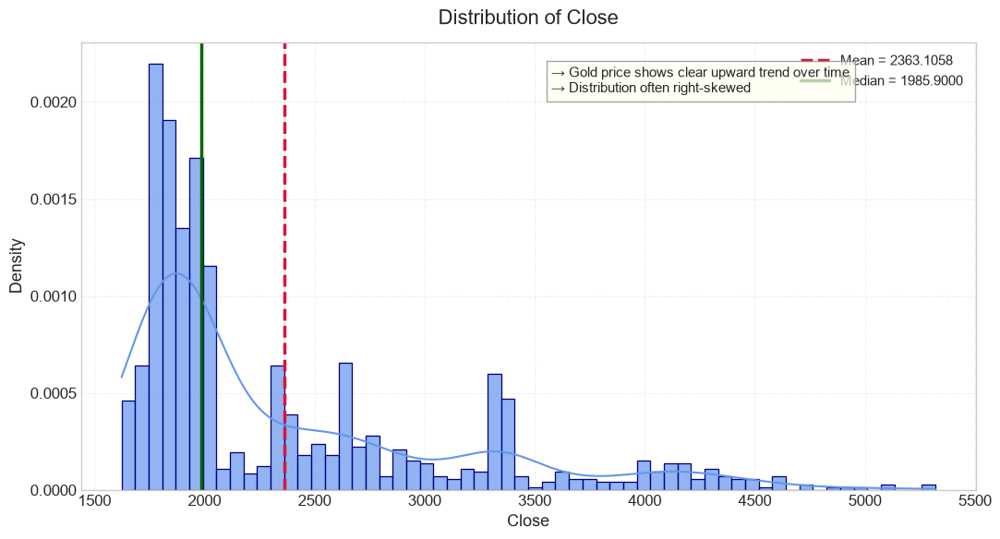

→ Plotting: daily_return


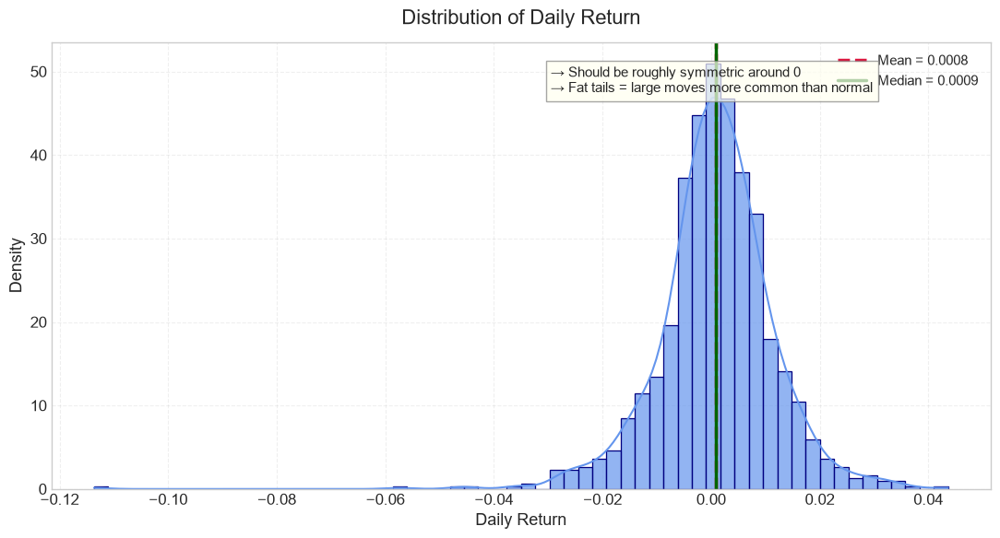

→ Plotting: volatility_7


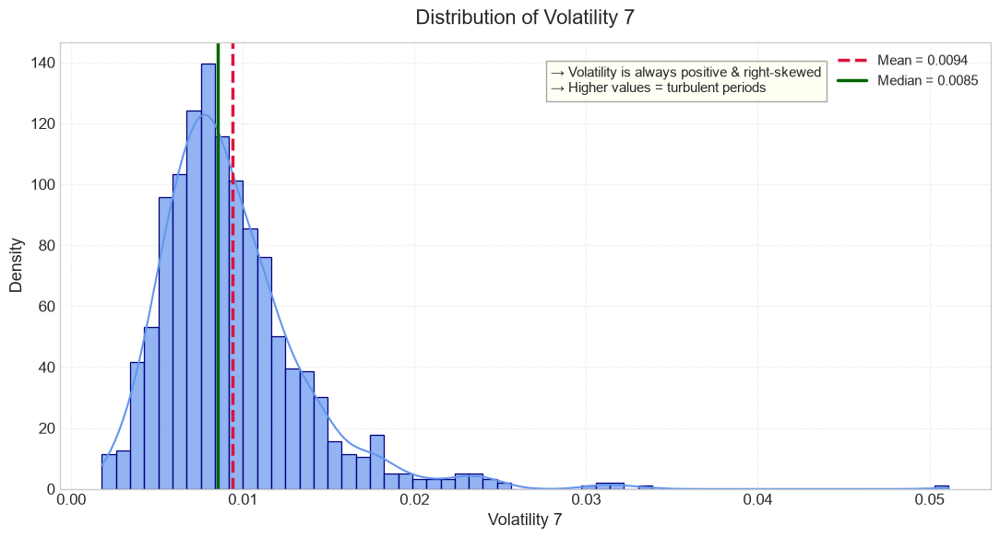

→ Plotting: volatility_30


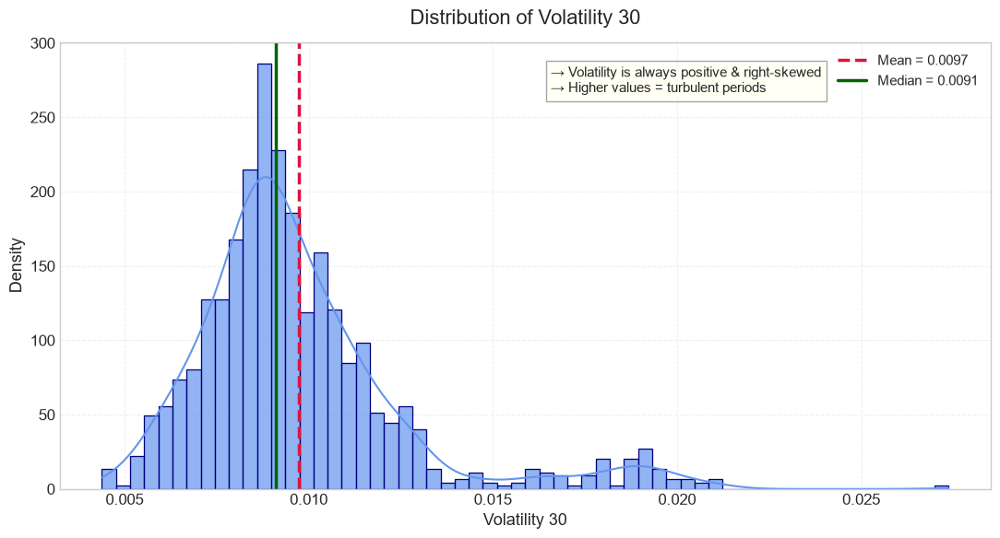

→ Plotting: rsi


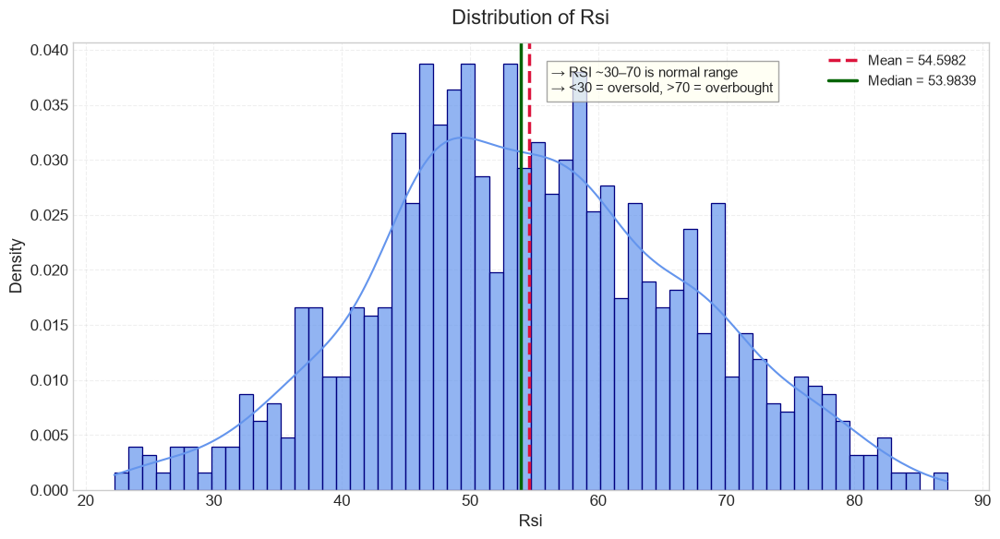

→ Plotting: macd


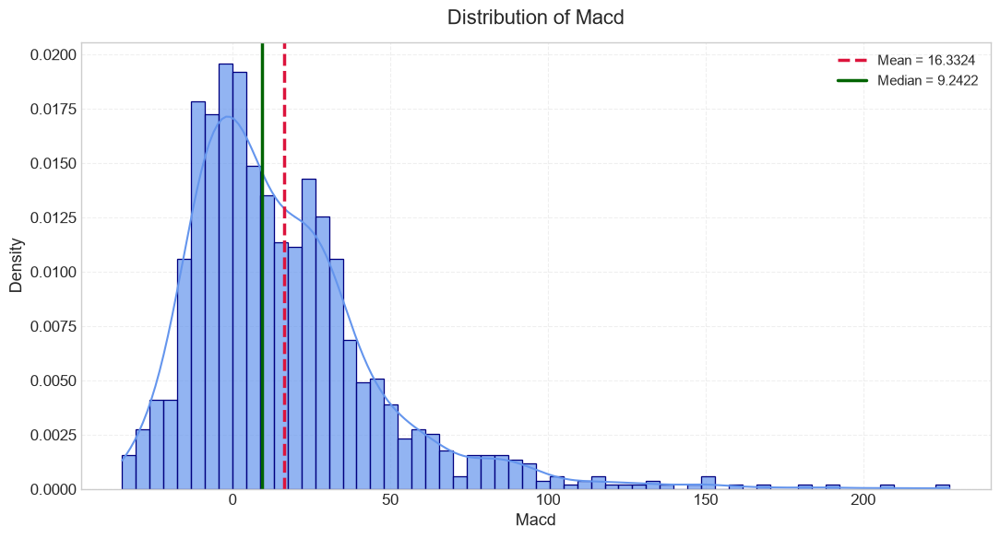

→ Plotting: macd_signal


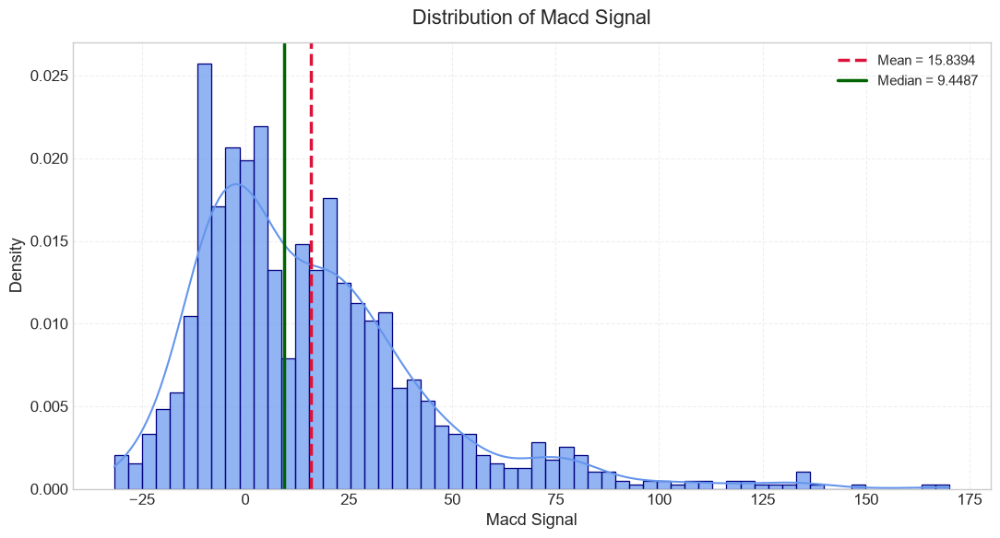

→ Plotting: volume


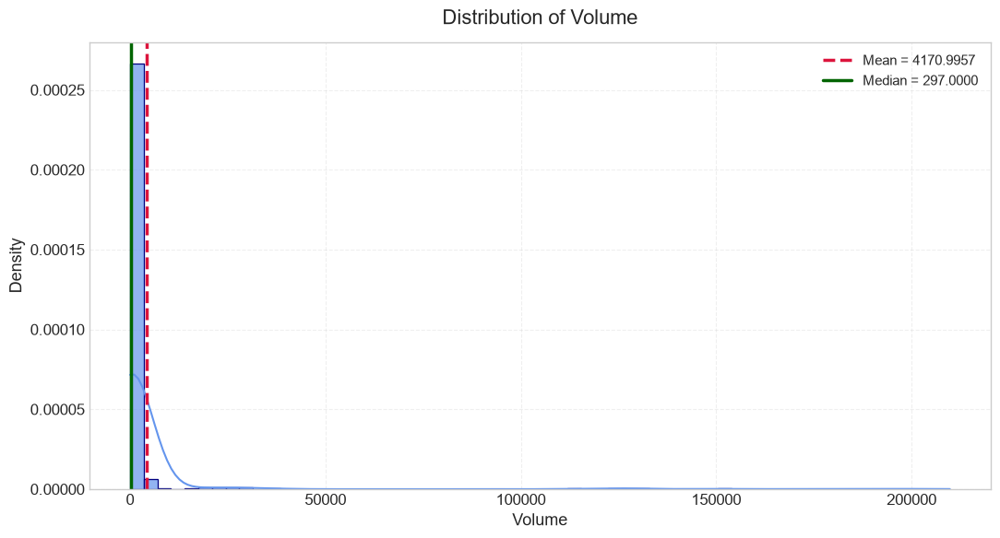


→ Bonus: Log-scale Close Price distribution


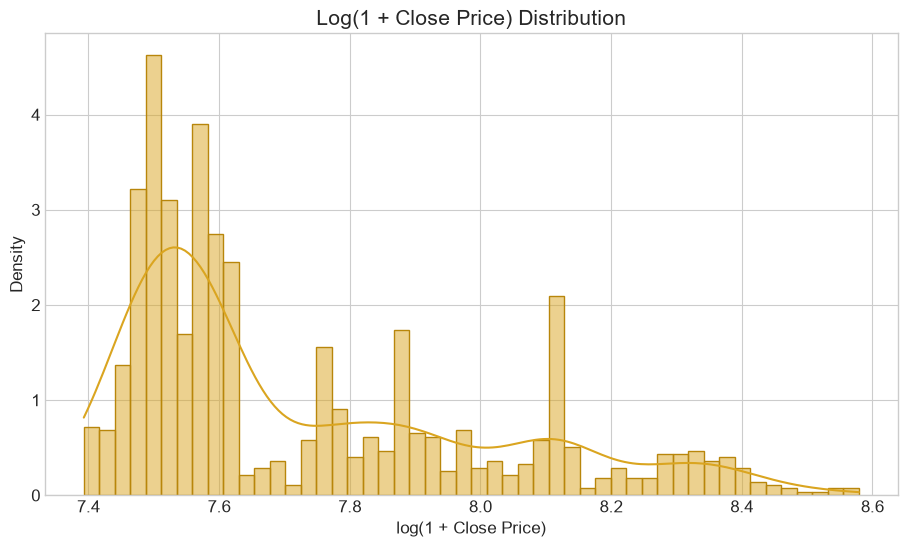


Done. These plots help you understand:
• Shape & skewness of prices & returns
• Whether indicators behave as expected
• Presence of fat tails / extreme events
• Typical ranges for RSI, MACD, volatility


In [5]:
# ────────────────────────────────────────────────────────────────
#       IMPORTANT HISTOGRAMS + KDE for Gold Price Forecasting
# ────────────────────────────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Style setup ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# ─── Load data ─────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv", parse_dates=['date'], index_col='date')

# ─── Key columns to visualize ────────────────────────────────────
important_cols = [
    'close',                # most important target
    'daily_return',         # must understand return distribution!
    'volatility_7',         # short-term realized volatility
    'volatility_30',        # medium-term volatility
    'rsi',                  # momentum / overbought-oversold
    'macd',                 # trend strength & direction
    'macd_signal',          # MACD signal line
    'volume'                # trading activity
]

# ─── Plot function with title & interpretation ───────────────────
def plot_hist_kde(col, df, bins=60, figsize=(11, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.histplot(
        data=df, 
        x=col, 
        kde=True, 
        bins=bins, 
        stat='density', 
        color='cornflowerblue', 
        edgecolor='navy',
        alpha=0.7,
        ax=ax
    )
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    
    ax.axvline(mean_val,   color='crimson',   lw=2.5, linestyle='--', label=f'Mean = {mean_val:.4f}')
    ax.axvline(median_val, color='darkgreen', lw=2.5, linestyle='-',  label=f'Median = {median_val:.4f}')
    
    ax.set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=16, pad=14)
    ax.set_xlabel(col.replace("_", " ").title(), fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add small interpretation box
    if col == 'daily_return':
        interp = "→ Should be roughly symmetric around 0\n→ Fat tails = large moves more common than normal"
    elif col == 'rsi':
        interp = "→ RSI ~30–70 is normal range\n→ <30 = oversold, >70 = overbought"
    elif 'volatility' in col:
        interp = "→ Volatility is always positive & right-skewed\n→ Higher values = turbulent periods"
    elif col == 'close':
        interp = "→ Gold price shows clear upward trend over time\n→ Distribution often right-skewed"
    else:
        interp = ""
    
    if interp:
        fig.text(0.55, 0.82, interp, 
                 fontsize=11, bbox=dict(facecolor='ivory', alpha=0.7, edgecolor='gray'))
    
    plt.tight_layout()
    plt.show()


# ─── Create all important plots ──────────────────────────────────
print("Generating key distributional plots...\n")

for col in important_cols:
    if col in df.columns:
        print(f"→ Plotting: {col}")
        plot_hist_kde(col, df)
    else:
        print(f"⚠️ Column '{col}' not found in dataset")

# ─── Bonus: Log-scale price distribution (very common in assets) ─
if 'close' in df.columns:
    print("\n→ Bonus: Log-scale Close Price distribution")
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.histplot(
        np.log1p(df['close']), 
        kde=True, bins=50, 
        color='goldenrod', 
        edgecolor='darkgoldenrod',
        stat='density'
    )
    ax.set_title("Log(1 + Close Price) Distribution", fontsize=15)
    ax.set_xlabel("log(1 + Close Price)", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    plt.show()

print("\nDone. These plots help you understand:")
print("• Shape & skewness of prices & returns")
print("• Whether indicators behave as expected")
print("• Presence of fat tails / extreme events")
print("• Typical ranges for RSI, MACD, volatility")

1. Gold Close + Moving Averages


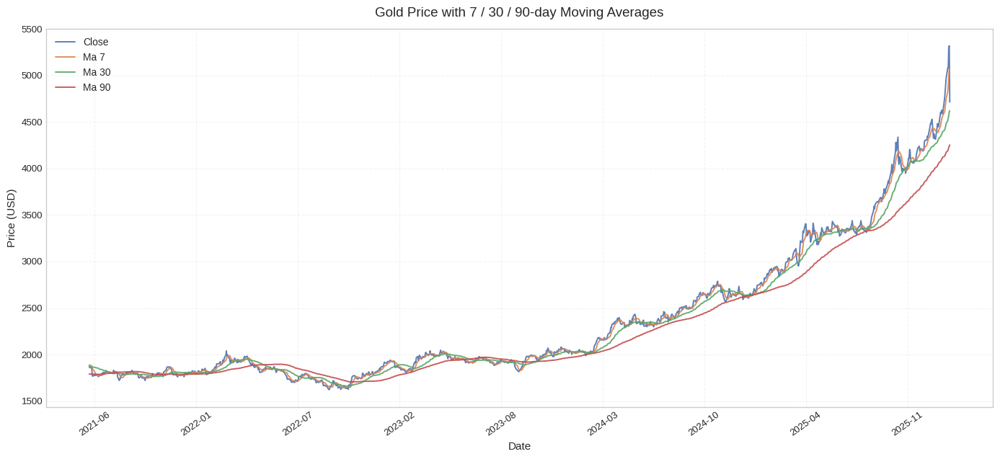


2. Gold Price + Bollinger Bands


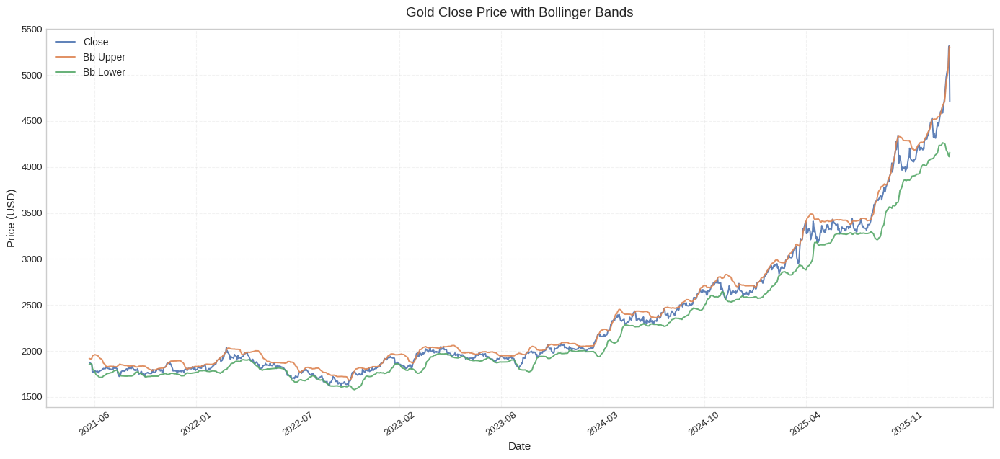


3. MACD & Signal Line


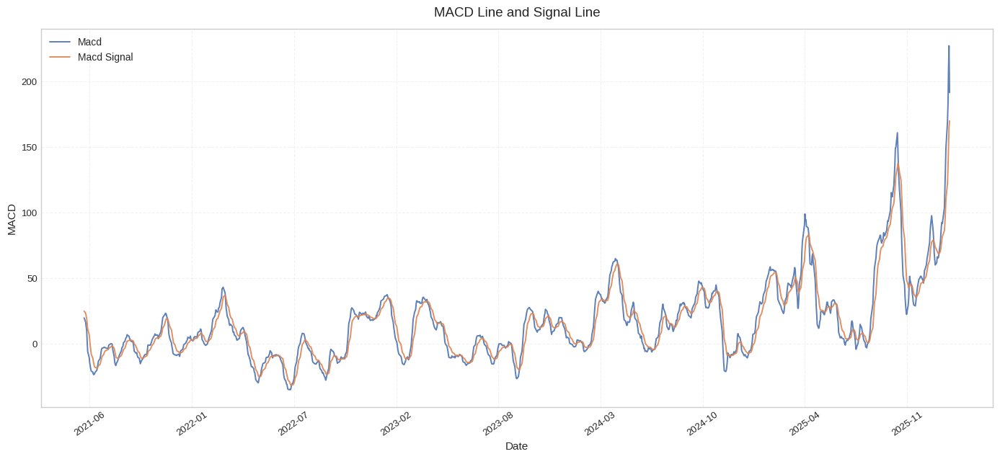


4. Gold Price vs RSI


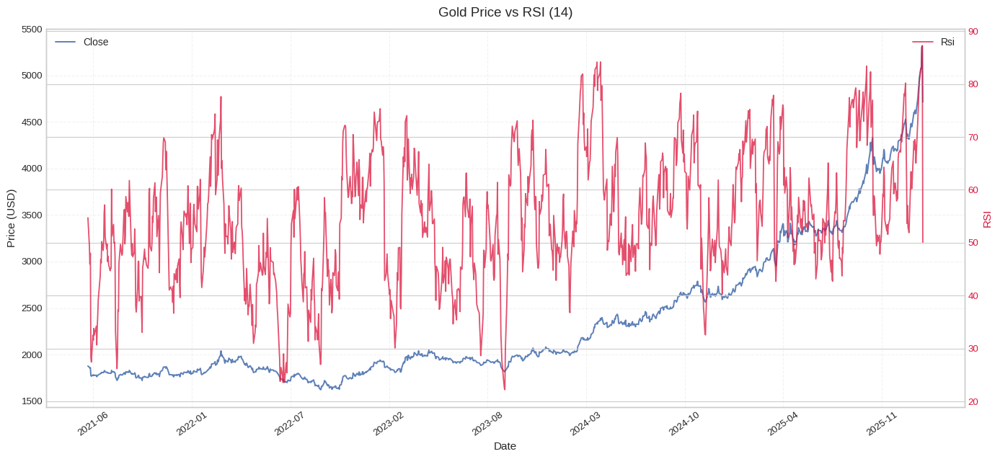


5. Daily Returns & 7-day Volatility


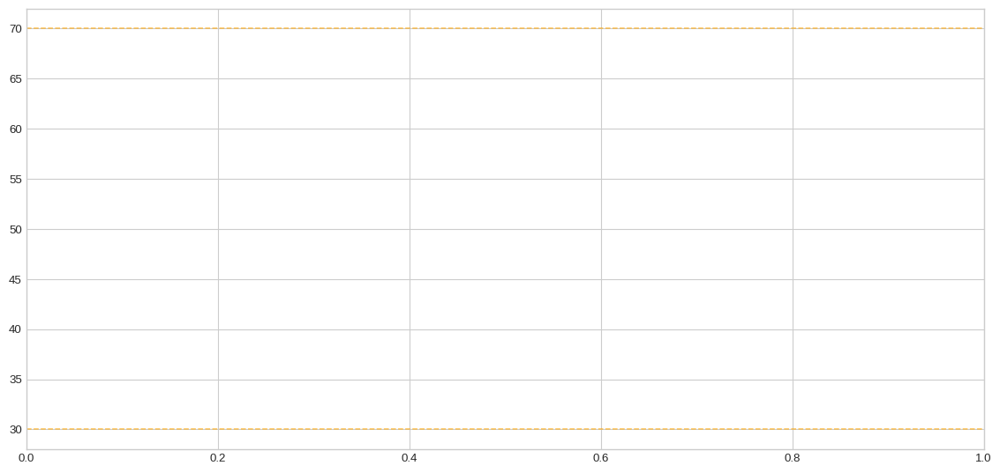

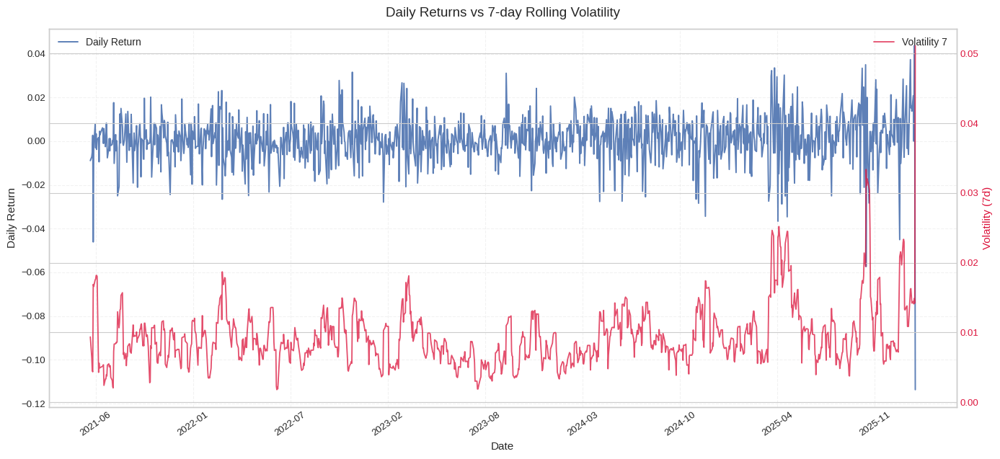


6. Gold Price vs Volume


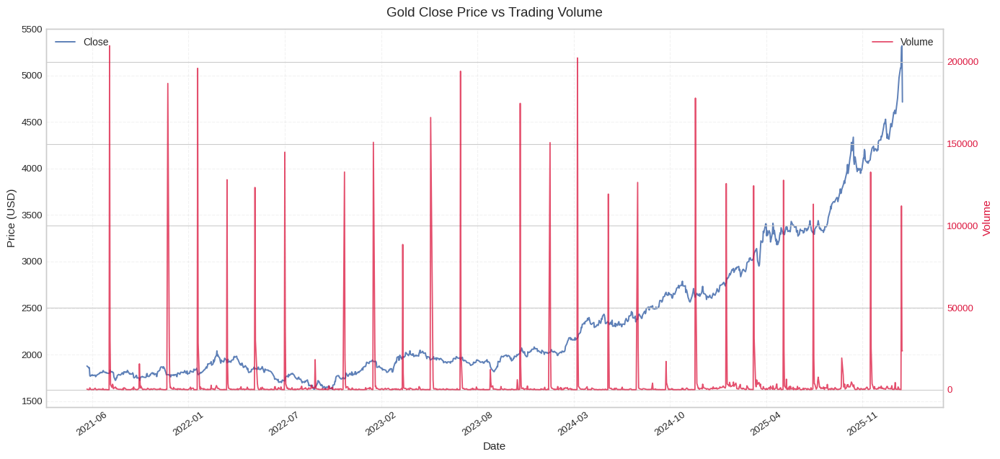


Bonus: Last ~2 years view (safer for memory)


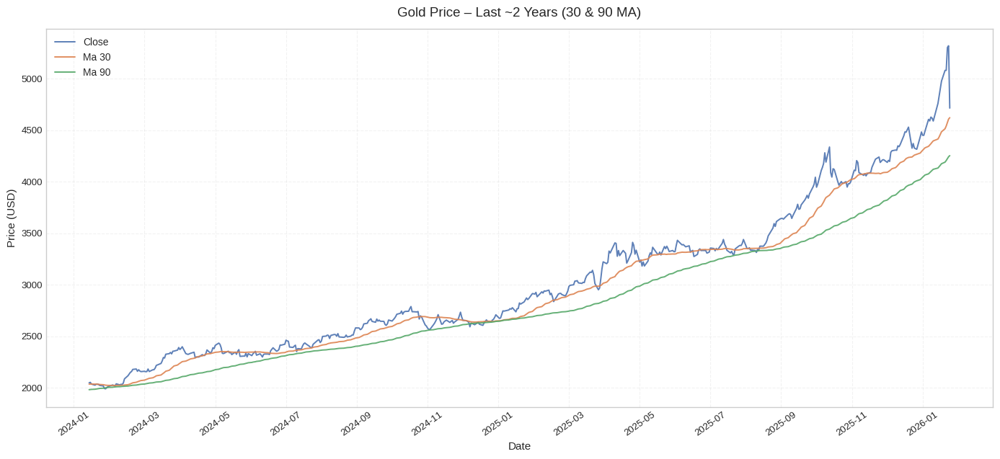

In [9]:
# =============================================================================
#   Gold Price Important Line Plots 
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# ─── Better styling + memory-friendly settings ────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

# Important: control figure size & dpi → prevents giant in-memory images
plt.rcParams['figure.figsize'] = (14, 6.5)     # narrower + shorter
plt.rcParams['figure.dpi'] = 100               # reasonable resolution
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13.5
plt.rcParams['axes.labelsize'] = 11.5
plt.rcParams['xtick.labelsize'] = 9.5
plt.rcParams['ytick.labelsize'] = 9.5

# ─── Assuming df is already loaded with DatetimeIndex ──────────────────
df = pd.read_csv("/kaggle/input/gold-price-forecasting-dataset/gold_price_forecasting_dataset.csv", parse_dates=['date'], index_col='date')
df = df.sort_index()

# ─── Helper function – safer x-tick handling ───────────────────────────
def plot_time_series_safe(
    df, 
    columns, 
    title, 
    ylabel, 
    figsize=(14, 6.5),
    legend_loc='best',
    secondary_y=None,
    secondary_ylabel=None,
    max_ticks=12               
):
    fig, ax1 = plt.subplots(figsize=figsize, dpi=100)
    
    # Plot primary lines
    for col in columns:
        if col in df.columns:
            ax1.plot(df.index, df[col], label=col.replace('_',' ').title(), linewidth=1.4, alpha=0.9)
    
    ax1.set_title(title, pad=12)
    ax1.set_xlabel('Date', fontsize=11)
    ax1.set_ylabel(ylabel, fontsize=11)
    
    # ─── Safer date formatting ────────────────────────────────────────
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=max_ticks))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.tick_params(axis='x', rotation=35, labelsize=9.5)
    
    # Limit number of ticks even more aggressively if needed
    ax1.xaxis.set_major_locator(MaxNLocator(nbins=max_ticks, integer=True))
    
    ax1.grid(True, alpha=0.25, linestyle='--')
    ax1.legend(loc=legend_loc, fontsize=10, framealpha=0.92)
    
    # Optional secondary axis
    if secondary_y and secondary_y in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df.index, df[secondary_y], color='crimson', lw=1.3, 
                 label=secondary_y.replace('_',' ').title(), alpha=0.75)
        ax2.set_ylabel(secondary_ylabel or secondary_y.replace('_',' ').title(), 
                       color='crimson', fontsize=11)
        ax2.tick_params(axis='y', labelcolor='crimson')
        ax2.legend(loc='upper right', fontsize=10, framealpha=0.92)
    
    plt.tight_layout()
    plt.show()


# ─── 1. Price + Moving Averages ───────────────────────────────────────
print("1. Gold Close + Moving Averages")
plot_time_series_safe(
    df=df,
    columns=['close', 'ma_7', 'ma_30', 'ma_90'],
    title="Gold Price with 7 / 30 / 90-day Moving Averages",
    ylabel="Price (USD)",
    legend_loc='upper left'
)

# ─── 2. Price + Bollinger Bands ───────────────────────────────────────
print("\n2. Gold Price + Bollinger Bands")
plot_time_series_safe(
    df=df,
    columns=['close', 'bb_upper', 'bb_lower'],
    title="Gold Close Price with Bollinger Bands",
    ylabel="Price (USD)",
    legend_loc='upper left'
)

# ─── 3. MACD ──────────────────────────────────────────────────────────
print("\n3. MACD & Signal Line")
plot_time_series_safe(
    df=df,
    columns=['macd', 'macd_signal'],
    title="MACD Line and Signal Line",
    ylabel="MACD",
    legend_loc='upper left'
)

# ─── 4. Price + RSI (dual axis) ───────────────────────────────────────
print("\n4. Gold Price vs RSI")
plot_time_series_safe(
    df=df,
    columns=['close'],
    title="Gold Price vs RSI (14)",
    ylabel="Price (USD)",
    secondary_y='rsi',
    secondary_ylabel="RSI"
)
# RSI lines (add after plotting)
plt.axhline(70, color='orange', ls='--', alpha=0.65, lw=1.1)
plt.axhline(30, color='orange', ls='--', alpha=0.65, lw=1.1)

# ─── 5. Daily return + short-term volatility ──────────────────────────
print("\n5. Daily Returns & 7-day Volatility")
plot_time_series_safe(
    df=df,
    columns=['daily_return'],
    title="Daily Returns vs 7-day Rolling Volatility",
    ylabel="Daily Return",
    secondary_y='volatility_7',
    secondary_ylabel="Volatility (7d)"
)

# ─── 6. Price + Volume ────────────────────────────────────────────────
print("\n6. Gold Price vs Volume")
plot_time_series_safe(
    df=df,
    columns=['close'],
    title="Gold Close Price vs Trading Volume",
    ylabel="Price (USD)",
    secondary_y='volume',
    secondary_ylabel="Volume"
)

# ─── Optional: last 2 years only (much smaller memory footprint) ──────
print("\nBonus: Last ~2 years view (safer for memory)")
recent = df[df.index >= df.index.max() - pd.Timedelta(730, 'D')]
plot_time_series_safe(
    df=recent,
    columns=['close', 'ma_30', 'ma_90'],
    title="Gold Price – Last ~2 Years (30 & 90 MA)",
    ylabel="Price (USD)",
    legend_loc='upper left',
    max_ticks=15
)

1. Average Gold Closing Price per Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\1249737832.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x, y=y, hue=hue, order=order,


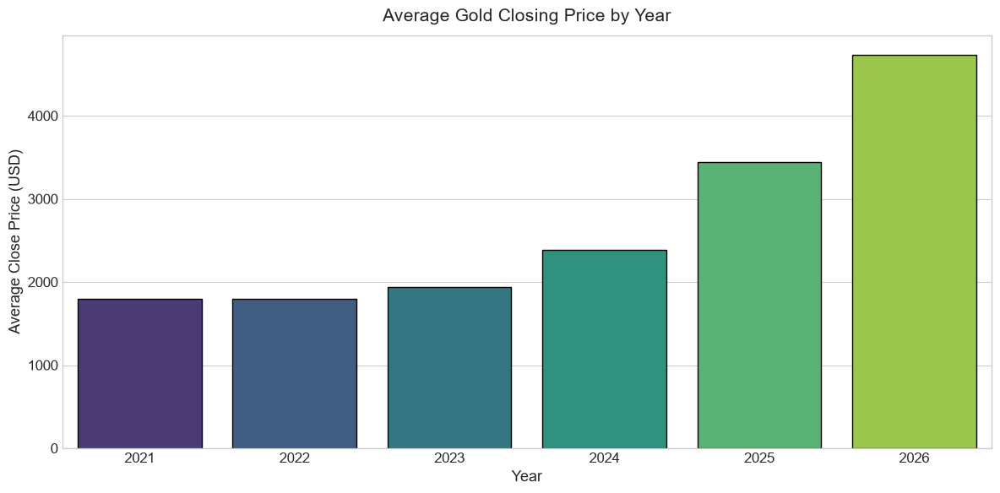


2. Average Gold Price by Month (seasonality view)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\1249737832.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x, y=y, hue=hue, order=order,


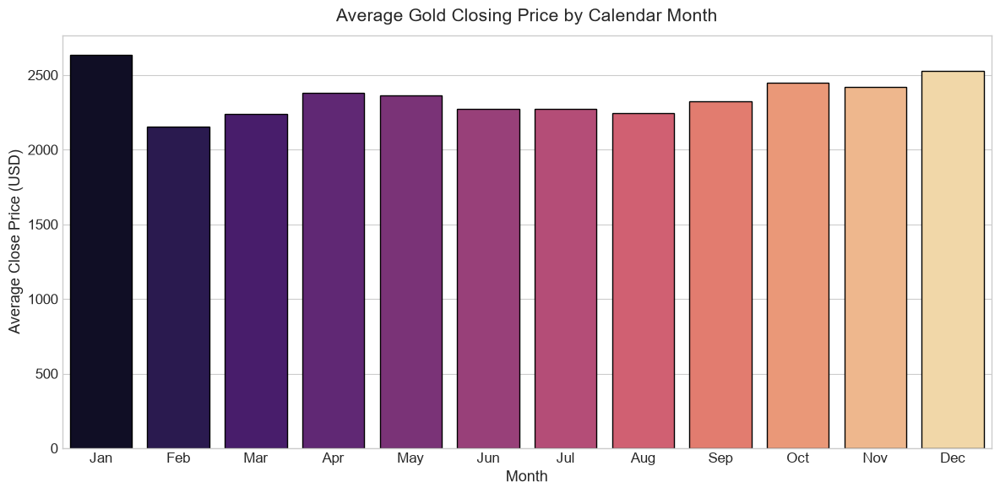


3. Trading Days per Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\1249737832.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x, y=y, hue=hue, order=order,


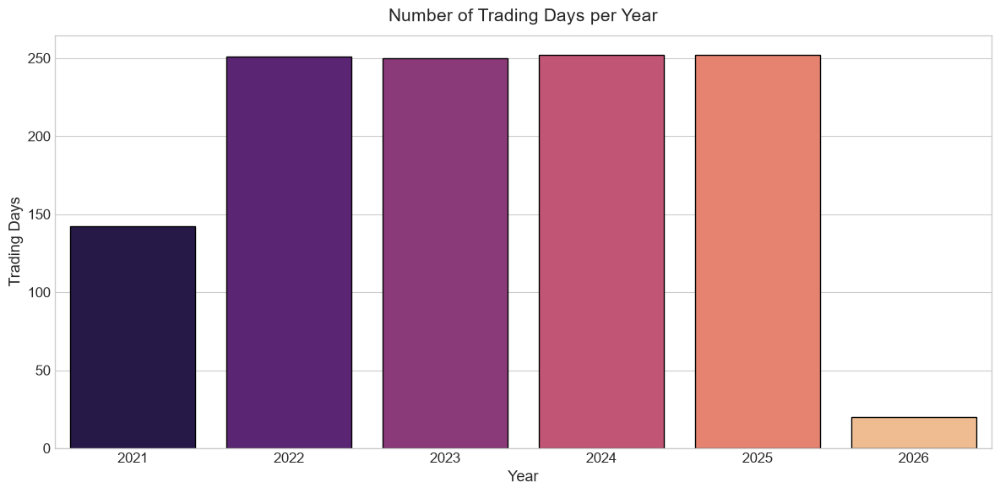


4. RSI Distribution – Overbought / Oversold Zones


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\1249737832.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=x, hue=hue, order=order,


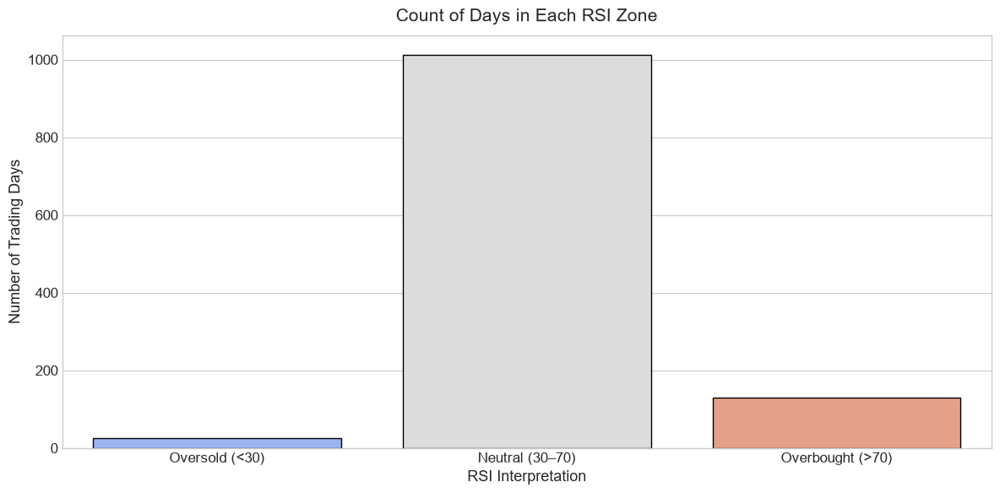


5. High vs Low Volume Days


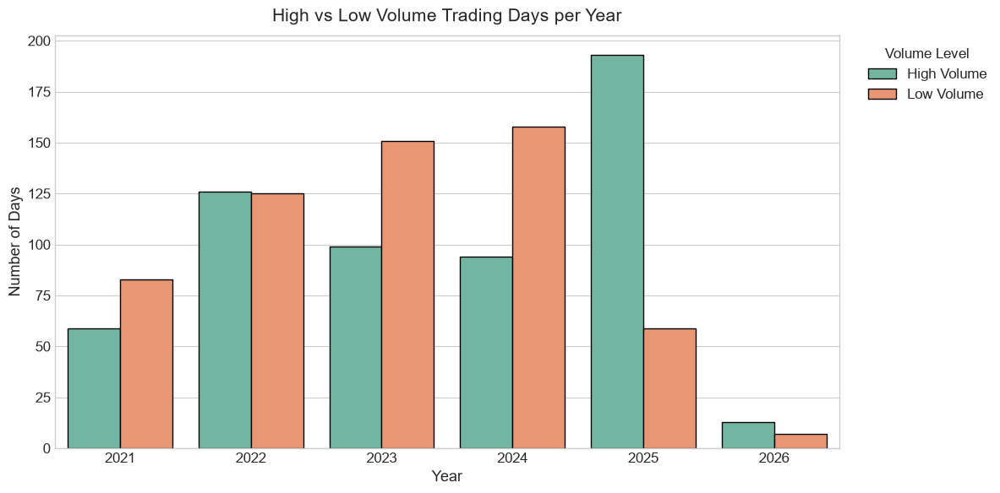


6. Average Gold Price by Day of Week


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\1249737832.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x, y=y, hue=hue, order=order,


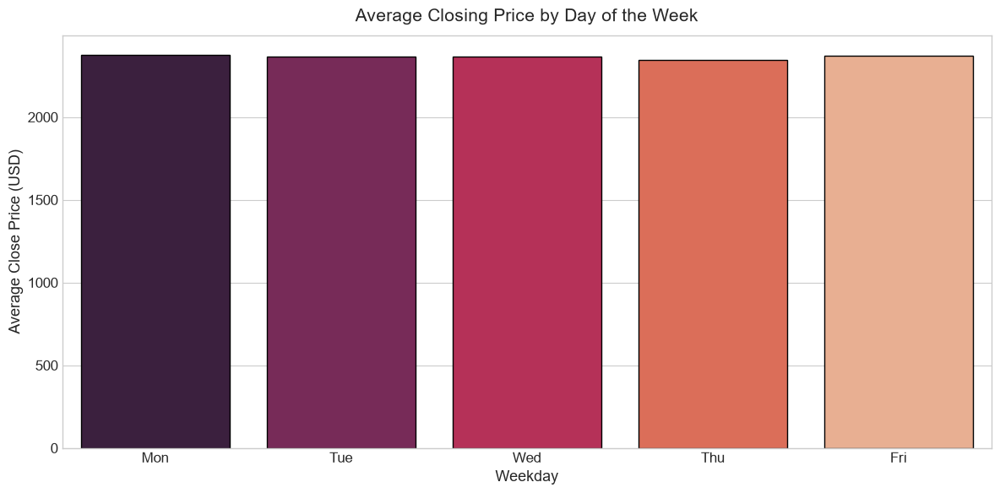


Bonus: Days with |Daily Return| ≥ 2% per Year


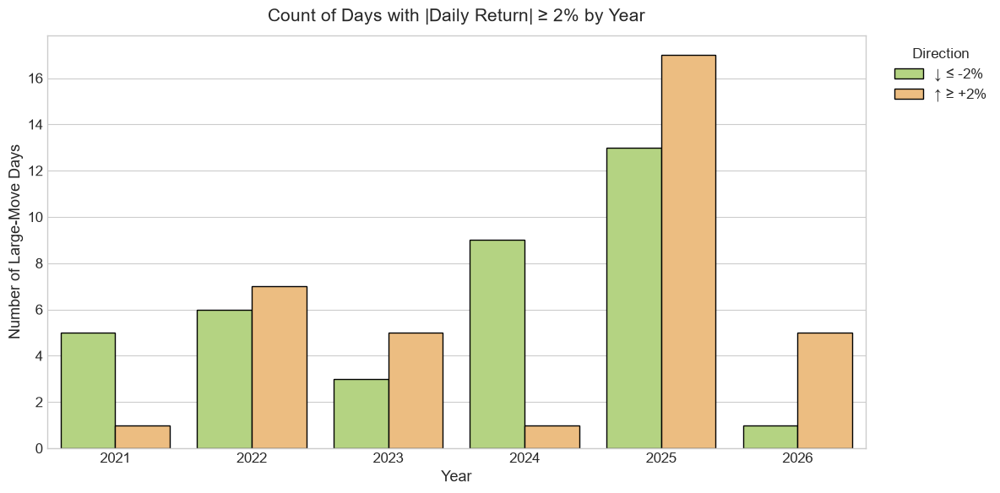

In [6]:
# ────────────────────────────────────────────────────────────────
#       IMPORTANT BAR PLOTS & COUNT PLOTS – Gold Price Dataset
# ────────────────────────────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─── Styling ─────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("magma")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# ─── Load & prepare data ─────────────────────────────────────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv", parse_dates=['date'])
df['date'] = pd.to_datetime(df['date'])

# Add useful categorical/time-based features
df_plot = df.copy()
df_plot['year']      = df_plot['date'].dt.year
df_plot['month']     = df_plot['date'].dt.month
df_plot['month_name'] = df_plot['date'].dt.strftime('%b')
df_plot['dayofweek'] = df_plot['date'].dt.dayofweek   # 0 = Monday
df_plot['weekday_name'] = df_plot['date'].dt.strftime('%a')

# ─── Helper function for clean bar/count plots ───────────────────
def plot_bar_or_count(data, x, y=None, kind='bar', title="", 
                      xlabel="", ylabel="", hue=None, order=None,
                      palette='magma', figsize=(12, 6), rotation=0):
    
    fig, ax = plt.subplots(figsize=figsize)
    
    if kind == 'bar':
        sns.barplot(data=data, x=x, y=y, hue=hue, order=order,
                    palette=palette, edgecolor='black', ax=ax)
    elif kind == 'count':
        sns.countplot(data=data, x=x, hue=hue, order=order,
                      palette=palette, edgecolor='black', ax=ax)
    
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel(xlabel if xlabel else x.replace('_',' ').title(), fontsize=13)
    ax.set_ylabel(ylabel if ylabel else "Count" if kind=='count' else y.replace('_',' ').title(), fontsize=13)
    
    if rotation != 0:
        plt.xticks(rotation=rotation, ha='right')
    
    if hue:
        ax.legend(title=hue.replace('_',' ').title(), bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


# ─── 1. Yearly Average Closing Price ─────────────────────────────
print("1. Average Gold Closing Price per Year")
yearly_avg = df_plot.groupby('year')['close'].mean().reset_index()
plot_bar_or_count(
    data=yearly_avg,
    x='year',
    y='close',
    kind='bar',
    title="Average Gold Closing Price by Year",
    xlabel="Year",
    ylabel="Average Close Price (USD)",
    palette='viridis'
)


# ─── 2. Average Monthly Closing Price (all years combined) ───────
print("\n2. Average Gold Price by Month (seasonality view)")
monthly_avg = df_plot.groupby('month_name')['close'].mean().reset_index()
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plot_bar_or_count(
    data=monthly_avg,
    x='month_name',
    y='close',
    kind='bar',
    title="Average Gold Closing Price by Calendar Month",
    xlabel="Month",
    ylabel="Average Close Price (USD)",
    order=month_order
)


# ─── 3. Number of Trading Days per Year ──────────────────────────
print("\n3. Trading Days per Year")
days_per_year = df_plot['year'].value_counts().sort_index().reset_index()
days_per_year.columns = ['year', 'count']

plot_bar_or_count(
    data=days_per_year,
    x='year',
    y='count',
    kind='bar',
    title="Number of Trading Days per Year",
    xlabel="Year",
    ylabel="Trading Days"
)


# ─── 4. RSI Category Count (classic zones) ───────────────────────
print("\n4. RSI Distribution – Overbought / Oversold Zones")
df_plot['rsi_zone'] = pd.cut(
    df_plot['rsi'],
    bins=[0, 30, 70, 100],
    labels=['Oversold (<30)', 'Neutral (30–70)', 'Overbought (>70)'],
    include_lowest=True
)

plot_bar_or_count(
    data=df_plot,
    x='rsi_zone',
    kind='count',
    title="Count of Days in Each RSI Zone",
    xlabel="RSI Interpretation",
    ylabel="Number of Trading Days",
    order=['Oversold (<30)', 'Neutral (30–70)', 'Overbought (>70)'],
    palette='coolwarm'
)


# ─── 5. Volume – High vs Low days ────────────────────────────────
print("\n5. High vs Low Volume Days")
median_vol = df_plot['volume'].median()
df_plot['volume_level'] = np.where(df_plot['volume'] >= median_vol, 'High Volume', 'Low Volume')

plot_bar_or_count(
    data=df_plot,
    x='year',
    hue='volume_level',
    kind='count',
    title="High vs Low Volume Trading Days per Year",
    xlabel="Year",
    ylabel="Number of Days",
    palette='Set2'
)


# ─── 6. Weekday Average Price (possible day-of-week effect) ──────
print("\n6. Average Gold Price by Day of Week")
weekday_avg = df_plot.groupby('weekday_name')['close'].mean().reset_index()
weekday_order = ['Mon','Tue','Wed','Thu','Fri']

plot_bar_or_count(
    data=weekday_avg,
    x='weekday_name',
    y='close',
    kind='bar',
    title="Average Closing Price by Day of the Week",
    xlabel="Weekday",
    ylabel="Average Close Price (USD)",
    order=weekday_order,
    palette='rocket'
)


# ─── Optional Bonus: Yearly count of days with large daily return ─
print("\nBonus: Days with |Daily Return| ≥ 2% per Year")
large_move = df_plot[abs(df_plot['daily_return']) >= 0.02].copy()
large_move['direction'] = np.where(large_move['daily_return'] > 0, '↑ ≥ +2%', '↓ ≤ -2%')

plot_bar_or_count(
    data=large_move,
    x='year',
    hue='direction',
    kind='count',
    title="Count of Days with |Daily Return| ≥ 2% by Year",
    xlabel="Year",
    ylabel="Number of Large-Move Days",
    palette='RdYlGn_r'
)

1. RSI Market Regime


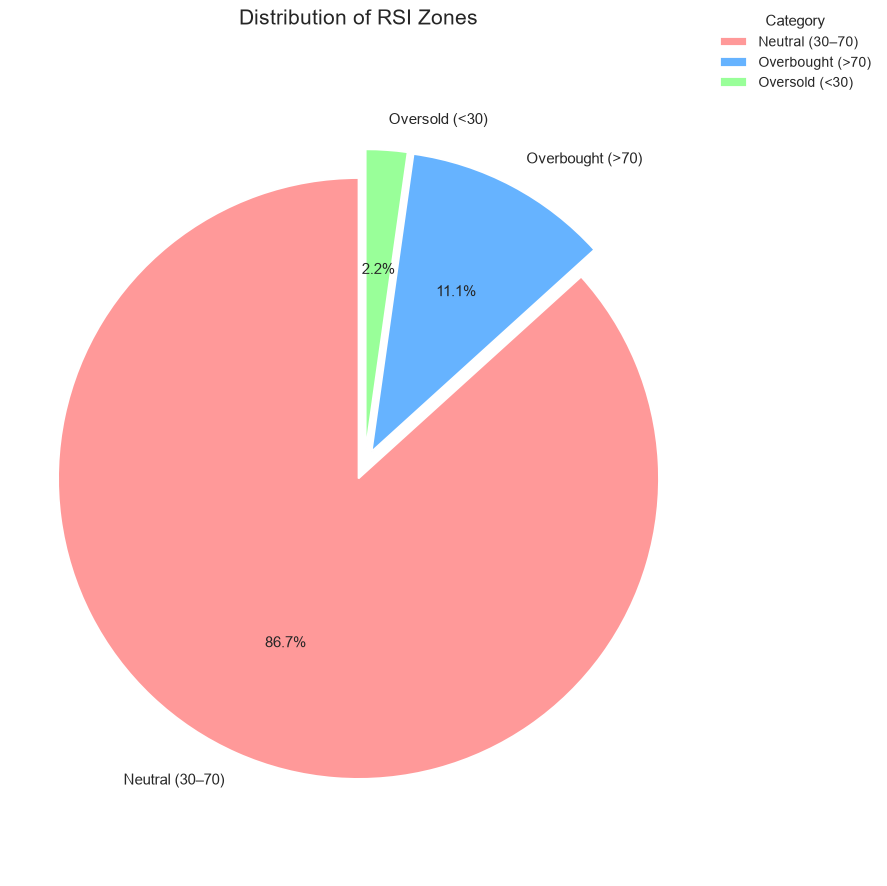


2. Daily Direction


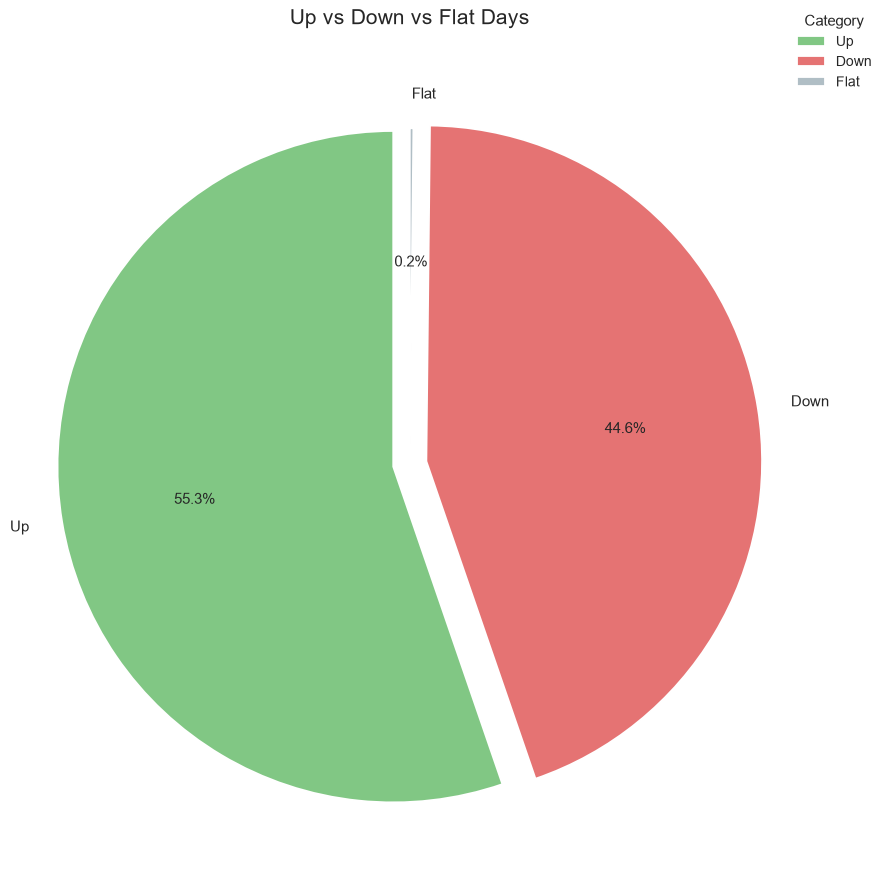


3. Calm vs Significant Moves


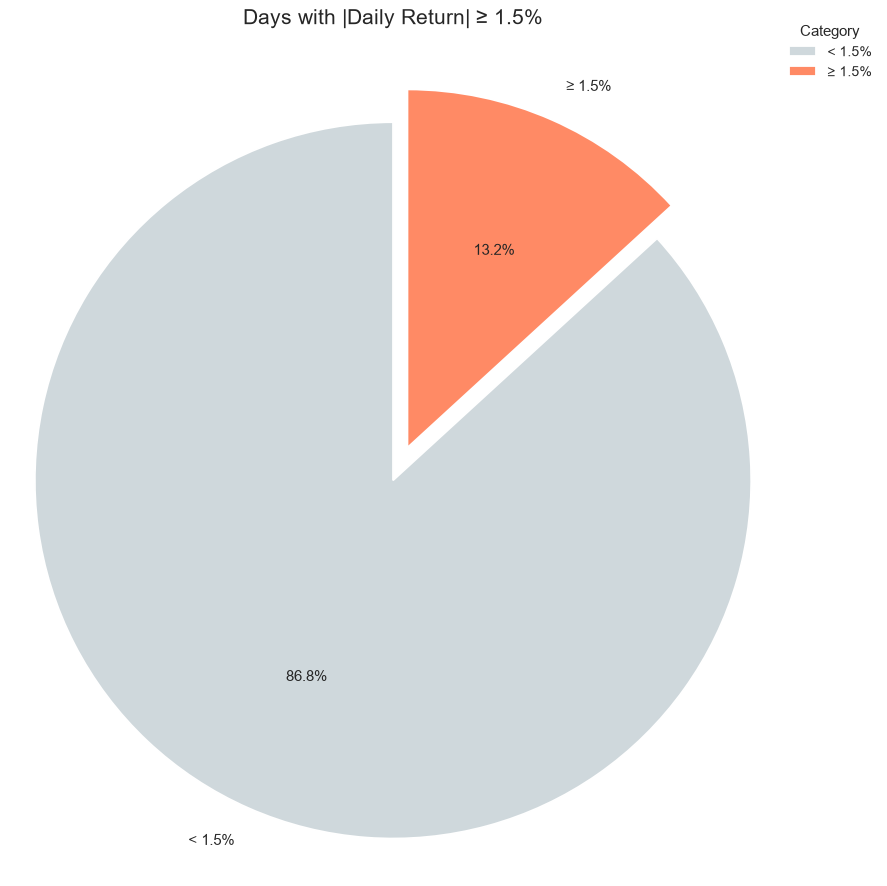


4. MACD Momentum Direction


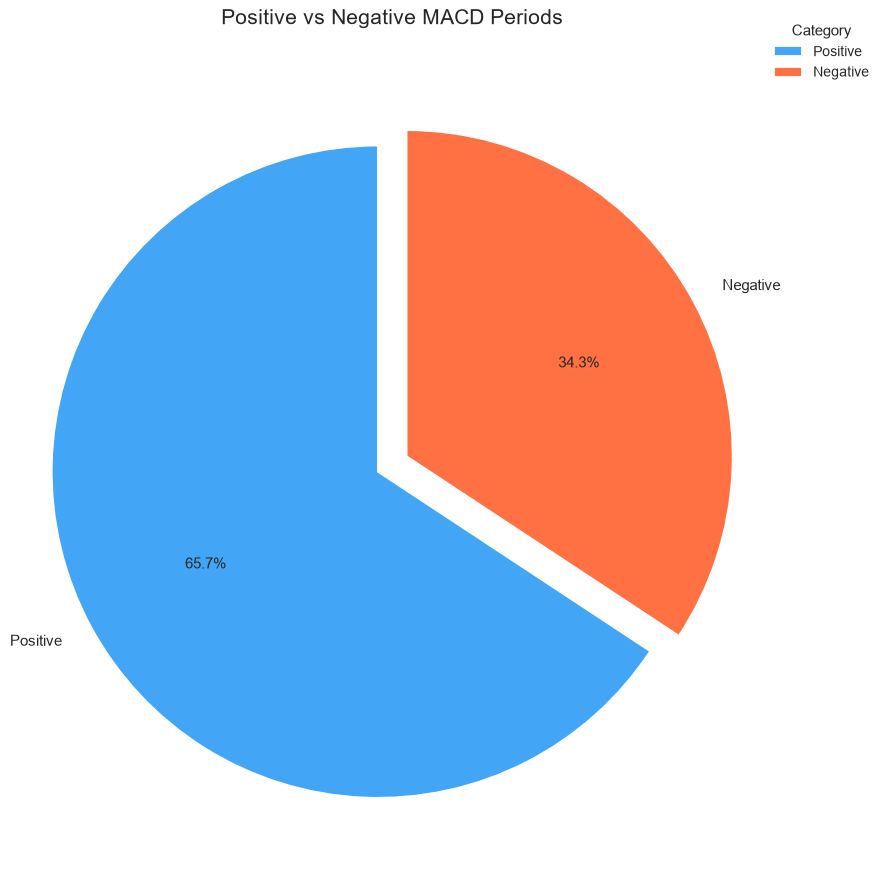


5. Trend Filter – 90-day MA


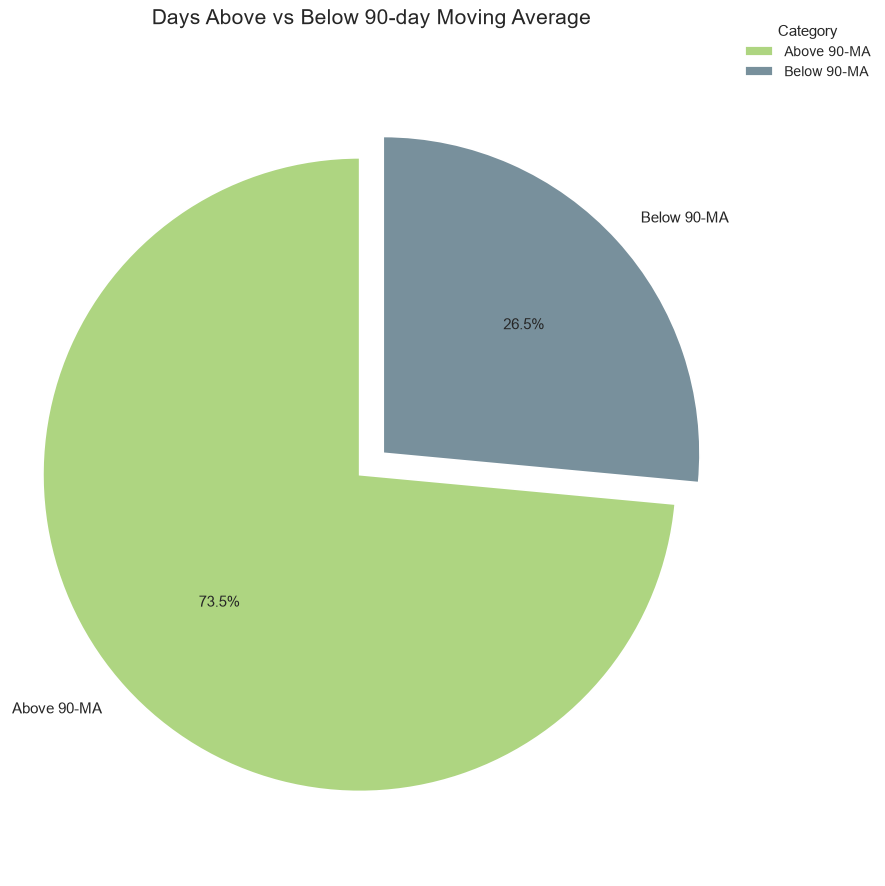


Bonus: RSI Zones – Last ~2 Years


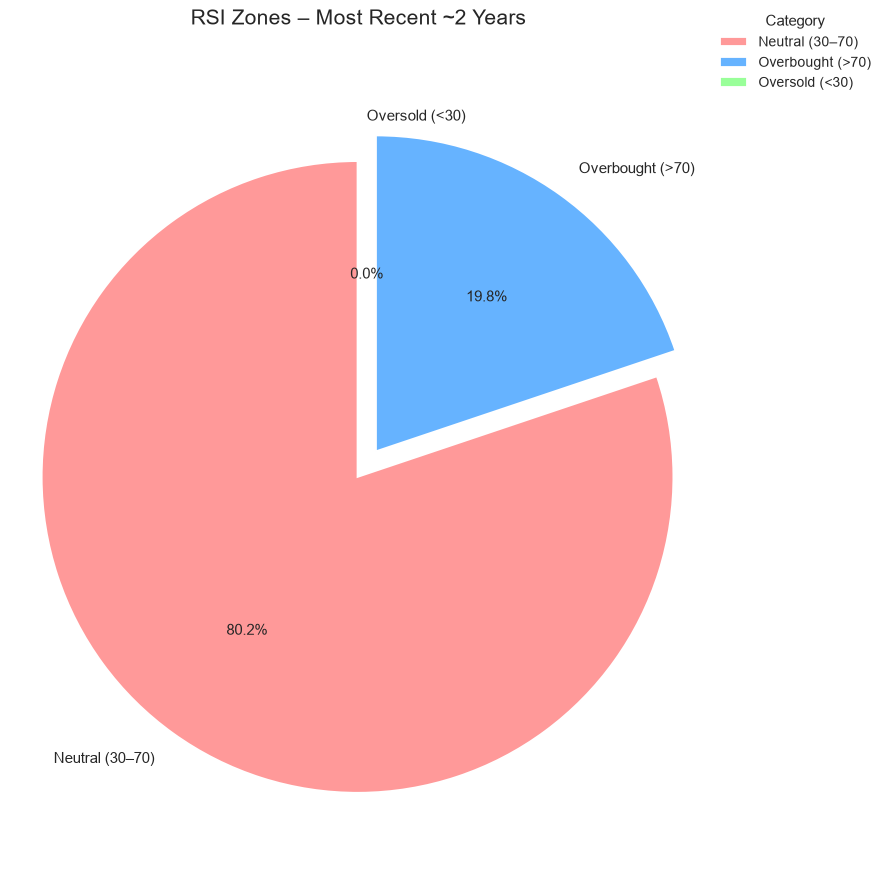

In [7]:
# =============================================================================
#     PIE CHARTS – Gold Price Dataset 
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ─── Styling ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-pastel')
plt.rcParams['figure.figsize'] = (9, 9)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14

# ─── Assuming df is already loaded with datetime index ───────────────────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv", parse_dates=['date'], index_col='date')

# ─── Prepare categories ─────────────────────────────────────────────────────
df_pie = df.copy()

# RSI zones
df_pie['rsi_zone'] = pd.cut(
    df_pie['rsi'],
    bins=[0, 30, 70, 100],
    labels=['Oversold (<30)', 'Neutral (30–70)', 'Overbought (>70)'],
    include_lowest=True
)

# Return direction
df_pie['return_sign'] = np.where(df_pie['daily_return'] > 0, 'Up',
                        np.where(df_pie['daily_return'] < 0, 'Down', 'Flat'))

# Large move
threshold = 0.015
df_pie['large_move'] = np.where(np.abs(df_pie['daily_return']) >= threshold,
                               f'≥ {threshold*100:.1f}%', 
                               f'< {threshold*100:.1f}%')

# MACD sign
df_pie['macd_sign'] = np.where(df_pie['macd'] > 0, 'Positive',
                      np.where(df_pie['macd'] < 0, 'Negative', 'Zero'))

# Above / below MA90
df_pie['above_ma90'] = np.where(df_pie['close'] > df_pie['ma_90'],
                               'Above 90-MA', 'Below 90-MA')

# ─── Safe pie plot function (dynamic explode) ───────────────────────────────
def plot_pie_safe(
    series,
    title,
    colors=None,
    explode_base=0.05,
    autopct='%1.1f%%',
    shadow=False,
    startangle=90,
    figsize=(9,9),
    min_pct_for_explode=0.5   # only explode slices >= this %
):
    counts = series.value_counts()
    if len(counts) == 0:
        print(f"→ Skipping '{title}' — no data")
        return
    
    # Dynamic explode: only explode meaningful slices
    explode = [0] * len(counts)
    for i, (cat, cnt) in enumerate(counts.items()):
        pct = cnt / counts.sum() * 100
        if pct >= min_pct_for_explode:
            explode[i] = explode_base
    
    fig, ax = plt.subplots(figsize=figsize)
    
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=counts.index,
        autopct=autopct,
        startangle=startangle,
        shadow=shadow,
        explode=explode,
        colors=colors,
        textprops={'fontsize': 11},
        wedgeprops={'linewidth': 1.3, 'edgecolor': 'white'}
    )
    
    ax.axis('equal')
    ax.set_title(title, fontsize=15, pad=20)
    
    # Legend on the right
    ax.legend(wedges, counts.index,
              title="Category",
              loc="center left",
              bbox_to_anchor=(1.0, 0.5, 0.3, 1),
              fontsize=10)
    
    plt.tight_layout()
    plt.show()


# ─── 1. RSI zones ───────────────────────────────────────────────────────────
print("1. RSI Market Regime")
plot_pie_safe(
    df_pie['rsi_zone'],
    title="Distribution of RSI Zones",
    colors=['#ff9999', '#66b3ff', '#99ff99']
)


# ─── 2. Up / Down / Flat days ──────────────────────────────────────────────
print("\n2. Daily Direction")
plot_pie_safe(
    df_pie['return_sign'],
    title="Up vs Down vs Flat Days",
    colors=['#81C784', '#E57373', '#B0BEC5']
)


# ─── 3. Large move days ─────────────────────────────────────────────────────
print("\n3. Calm vs Significant Moves")
plot_pie_safe(
    df_pie['large_move'],
    title=f"Days with |Daily Return| ≥ {threshold*100:.1f}%",
    colors=['#CFD8DC', '#FF8A65']
)


# ─── 4. MACD momentum ───────────────────────────────────────────────────────
print("\n4. MACD Momentum Direction")
plot_pie_safe(
    df_pie['macd_sign'],
    title="Positive vs Negative MACD Periods",
    colors=['#42A5F5', '#FF7043', '#BDBDBD']
)


# ─── 5. Above / below long-term trend ──────────────────────────────────────
print("\n5. Trend Filter – 90-day MA")
plot_pie_safe(
    df_pie['above_ma90'],
    title="Days Above vs Below 90-day Moving Average",
    colors=['#AED581', '#78909C']
)


# ─── Bonus: Recent period only ──────────────────────────────────────────────
print("\nBonus: RSI Zones – Last ~2 Years")
recent = df_pie[df_pie.index >= df_pie.index.max() - pd.Timedelta(730, 'D')]
plot_pie_safe(
    recent['rsi_zone'],
    title="RSI Zones – Most Recent ~2 Years",
    colors=['#ff9999', '#66b3ff', '#99ff99']
)

1. Gold Closing Price – Distribution by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


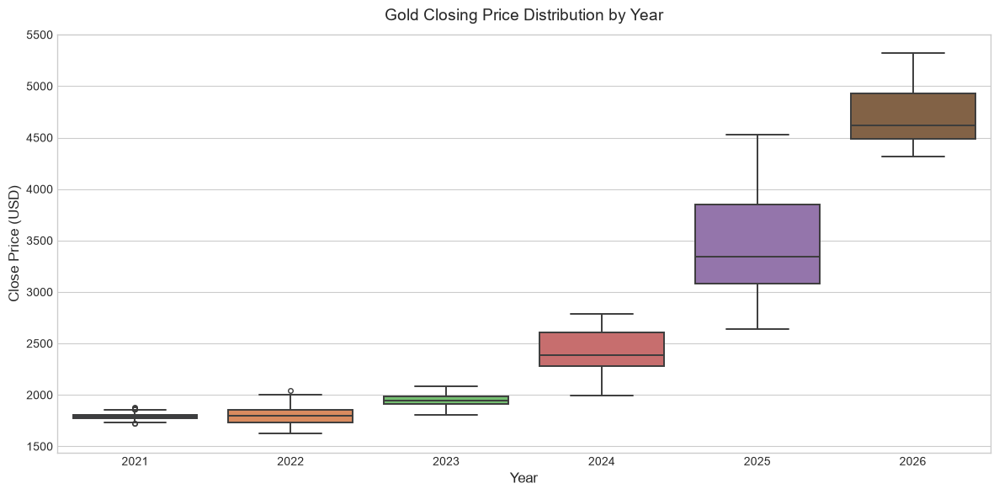


2. Daily Returns – by Year (outliers = large daily moves)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


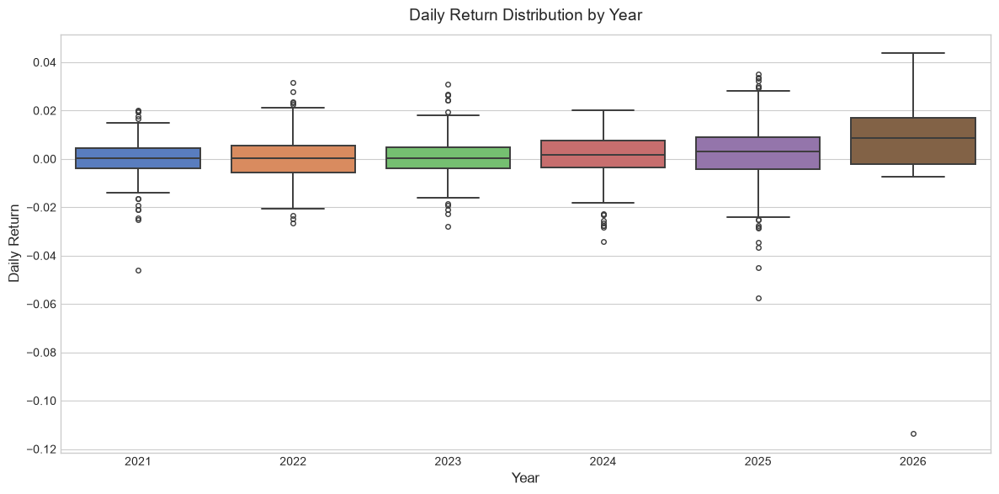


3. 7-day Realized Volatility by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


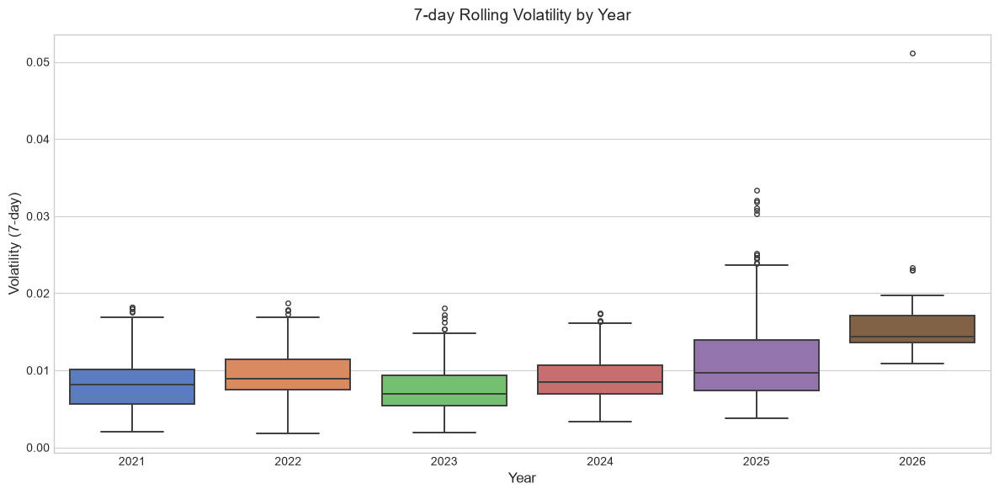


4. RSI (14) Distribution by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


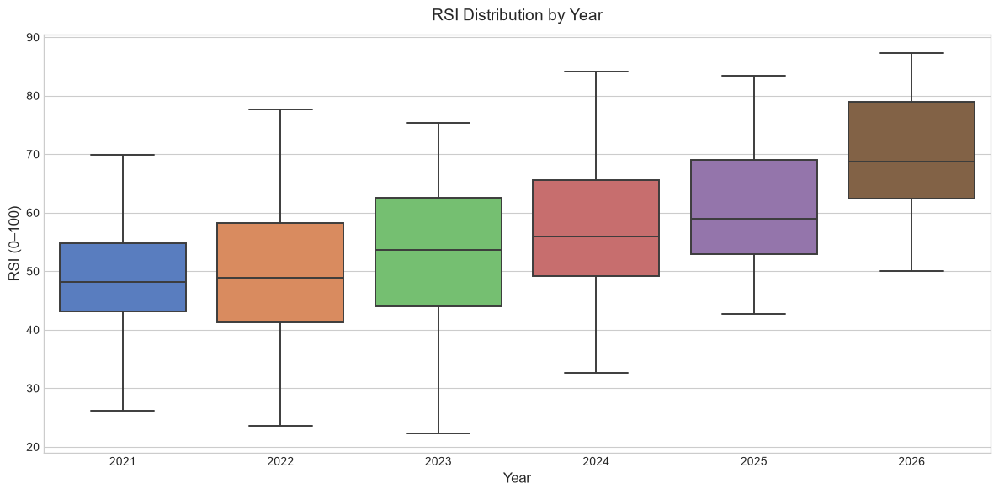


5. Gold Price by Month – Seasonal Pattern?


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


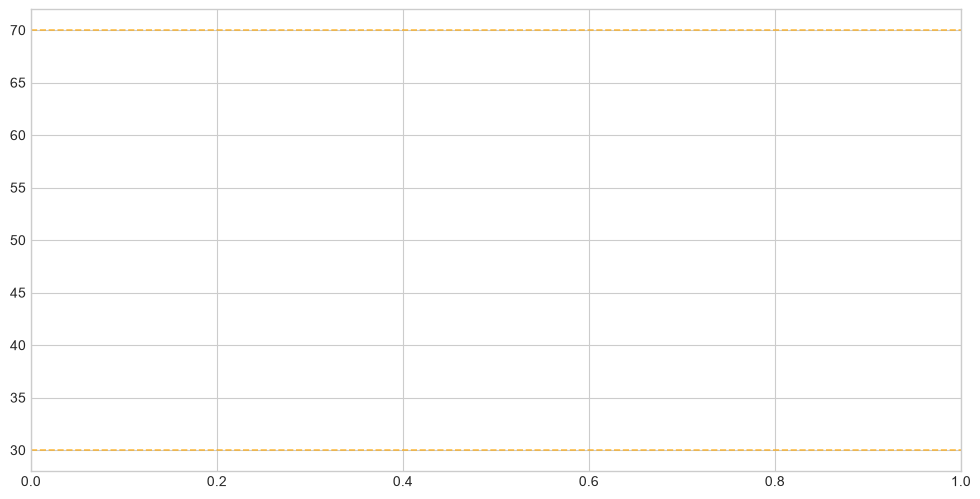

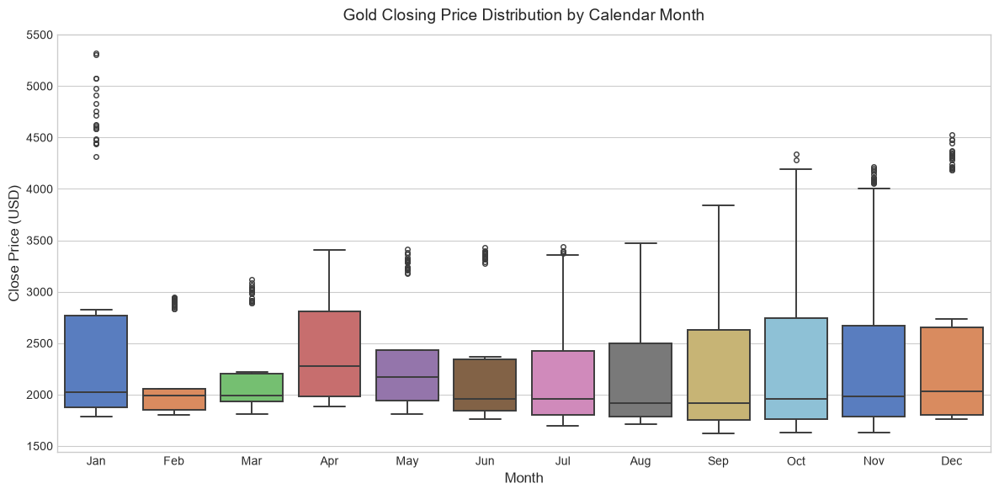


6. Daily Returns by Month


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


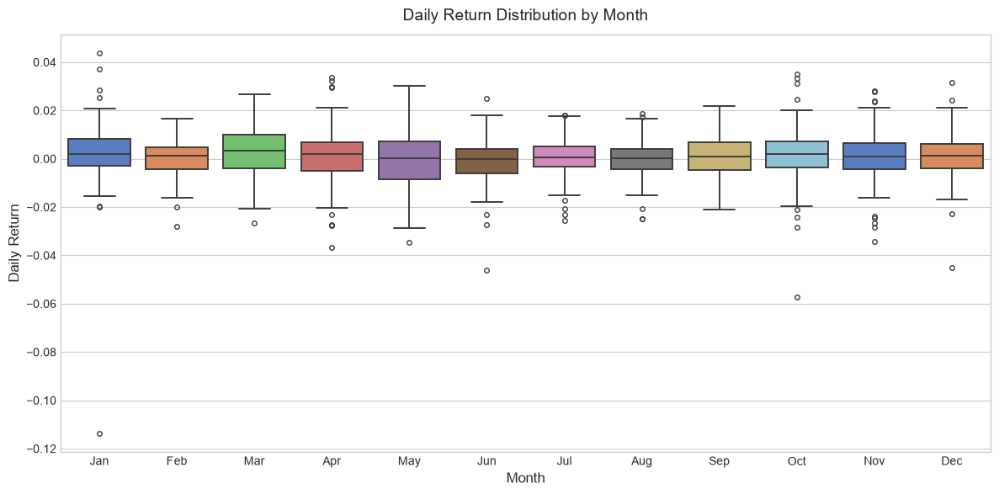


7. Trading Volume Distribution by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


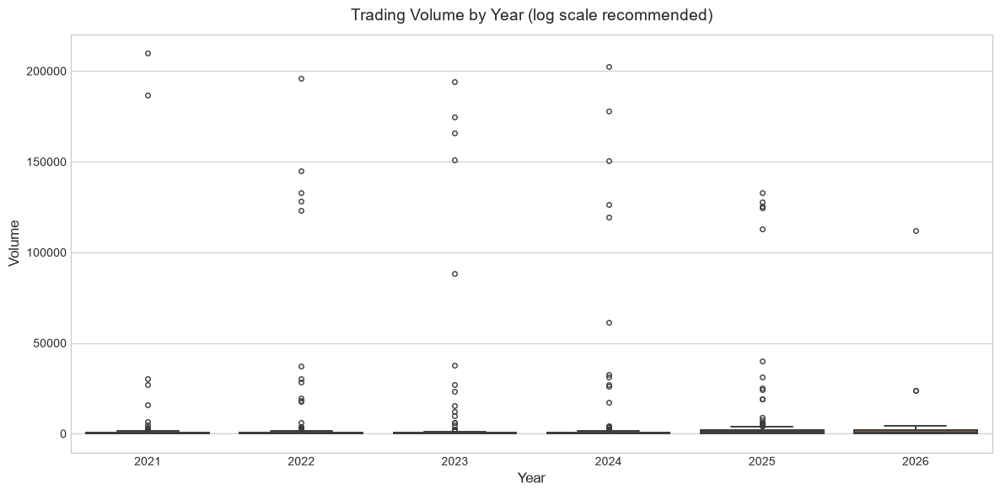


8. MACD Distribution by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


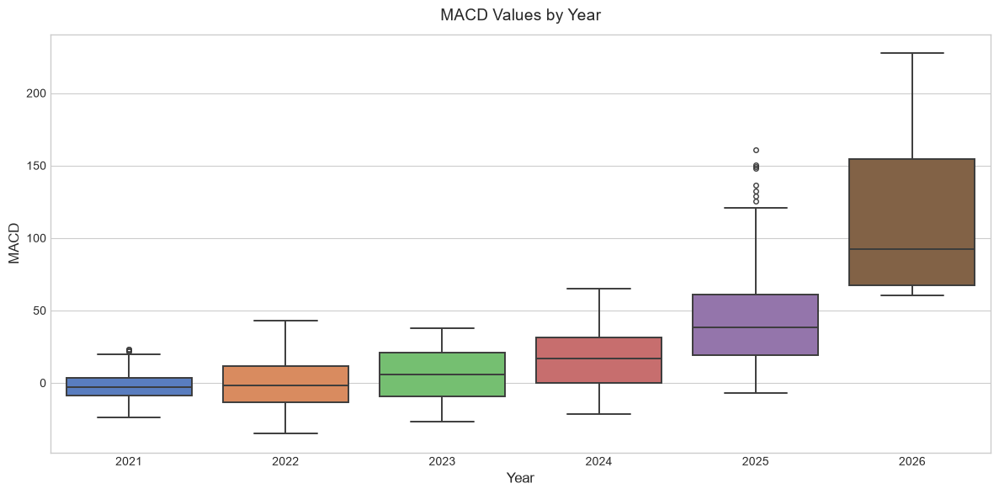


Bonus: Boxplot of |Daily Return| ≥ 1.5% days only


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\3533412912.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


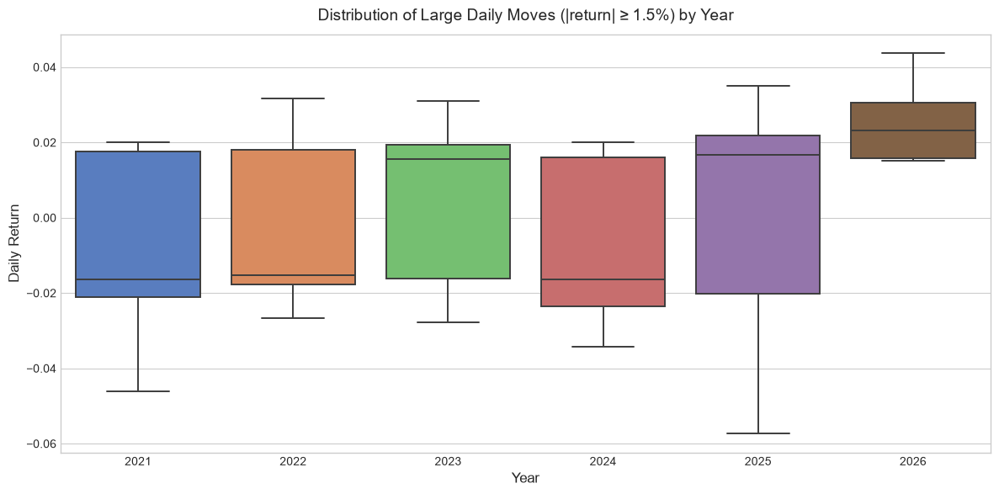

In [8]:
# =============================================================================
#          IMPORTANT BOXPLOTS – Gold Price & Technical Indicators
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─── Styling ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# ─── Assuming df is already loaded with datetime index ───────────────────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv", parse_dates=['date'], index_col='date')

# ─── Prepare grouping columns ───────────────────────────────────────────────
df_box = df.copy()
df_box['year']      = df_box.index.year
df_box['month']     = df_box.index.month
df_box['month_name'] = df_box.index.strftime('%b')
df_box['quarter']   = df_box.index.quarter

# ─── Helper function for clean boxplots ─────────────────────────────────────
def plot_boxplot(
    data, x, y, title, xlabel="", ylabel="",
    hue=None, order=None, hue_order=None,
    figsize=(12, 6), rotate_xticks=0, showfliers=True
):
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.boxplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        order=order,
        hue_order=hue_order,
        palette="muted",
        showfliers=showfliers,          # toggle extreme outliers
        linewidth=1.4,
        fliersize=4,
        ax=ax
    )
    
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel or x.replace('_',' ').title())
    ax.set_ylabel(ylabel or y.replace('_',' ').title())
    
    if rotate_xticks != 0:
        plt.xticks(rotation=rotate_xticks, ha='right')
    
    if hue:
        ax.legend(title=hue.replace('_',' ').title(), 
                  bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


# ─── 1. Closing price distribution by year ──────────────────────────────────
print("1. Gold Closing Price – Distribution by Year")
plot_boxplot(
    data=df_box,
    x='year',
    y='close',
    title="Gold Closing Price Distribution by Year",
    xlabel="Year",
    ylabel="Close Price (USD)",
    rotate_xticks=0
)


# ─── 2. Daily returns by year ───────────────────────────────────────────────
print("\n2. Daily Returns – by Year (outliers = large daily moves)")
plot_boxplot(
    data=df_box,
    x='year',
    y='daily_return',
    title="Daily Return Distribution by Year",
    xlabel="Year",
    ylabel="Daily Return",
    rotate_xticks=0,
    showfliers=True
)


# ─── 3. 7-day volatility by year ────────────────────────────────────────────
print("\n3. 7-day Realized Volatility by Year")
plot_boxplot(
    data=df_box,
    x='year',
    y='volatility_7',
    title="7-day Rolling Volatility by Year",
    xlabel="Year",
    ylabel="Volatility (7-day)",
    rotate_xticks=0
)


# ─── 4. RSI by year ─────────────────────────────────────────────────────────
print("\n4. RSI (14) Distribution by Year")
plot_boxplot(
    data=df_box,
    x='year',
    y='rsi',
    title="RSI Distribution by Year",
    xlabel="Year",
    ylabel="RSI (0–100)",
    rotate_xticks=0
)

# Add reference lines
plt.axhline(70, color='orange', linestyle='--', alpha=0.7, linewidth=1.2)
plt.axhline(30, color='orange', linestyle='--', alpha=0.7, linewidth=1.2)


# ─── 5. Closing price by calendar month (seasonality) ───────────────────────
print("\n5. Gold Price by Month – Seasonal Pattern?")
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plot_boxplot(
    data=df_box,
    x='month_name',
    y='close',
    title="Gold Closing Price Distribution by Calendar Month",
    xlabel="Month",
    ylabel="Close Price (USD)",
    order=month_order,
    rotate_xticks=0
)


# ─── 6. Daily return by month ───────────────────────────────────────────────
print("\n6. Daily Returns by Month")
plot_boxplot(
    data=df_box,
    x='month_name',
    y='daily_return',
    title="Daily Return Distribution by Month",
    xlabel="Month",
    ylabel="Daily Return",
    order=month_order,
    rotate_xticks=0,
    showfliers=True
)


# ─── 7. Volume by year ──────────────────────────────────────────────────────
print("\n7. Trading Volume Distribution by Year")
plot_boxplot(
    data=df_box,
    x='year',
    y='volume',
    title="Trading Volume by Year (log scale recommended)",
    xlabel="Year",
    ylabel="Volume",
    rotate_xticks=0
)
# Tip: volume is usually very skewed → consider log
# plt.yscale('log')


# ─── 8. MACD by year ────────────────────────────────────────────────────────
print("\n8. MACD Distribution by Year")
plot_boxplot(
    data=df_box,
    x='year',
    y='macd',
    title="MACD Values by Year",
    xlabel="Year",
    ylabel="MACD",
    rotate_xticks=0
)


# ─── Bonus: Extreme daily moves – only large changes ────────────────────────
print("\nBonus: Boxplot of |Daily Return| ≥ 1.5% days only")
large_moves = df_box[np.abs(df_box['daily_return']) >= 0.015].copy()
large_moves['year'] = large_moves.index.year

plot_boxplot(
    data=large_moves,
    x='year',
    y='daily_return',
    title="Distribution of Large Daily Moves (|return| ≥ 1.5%) by Year",
    xlabel="Year",
    ylabel="Daily Return",
    rotate_xticks=0,
    showfliers=False
)

1. Gold Close Price – Violin by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


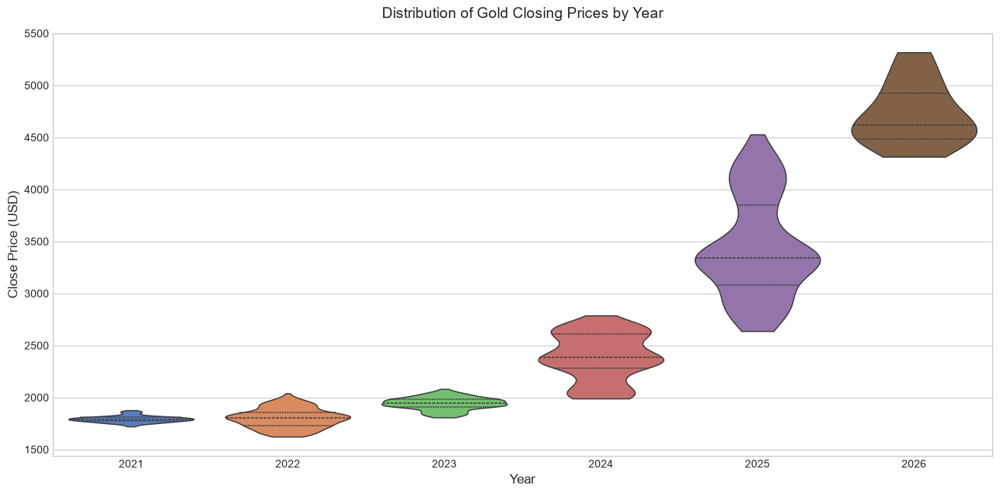


2. Daily Returns – Violin by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


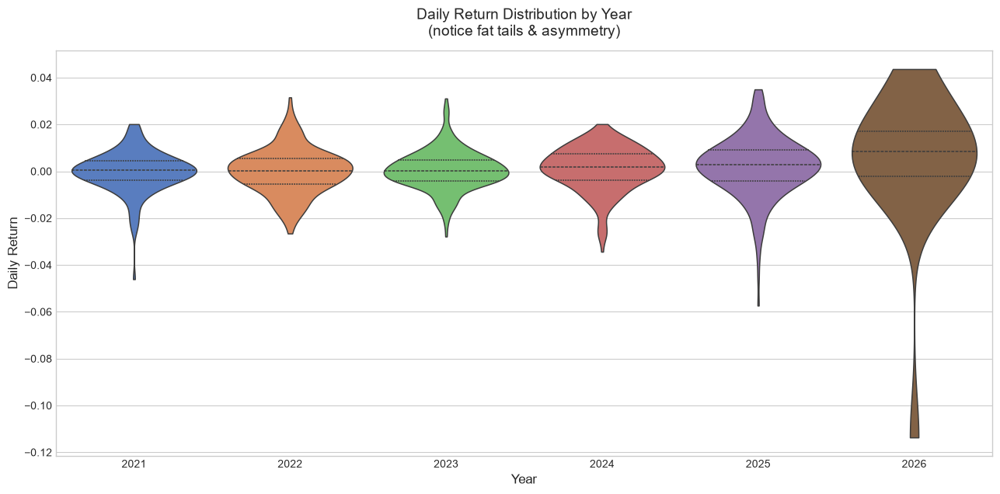


3. Short-term Volatility by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


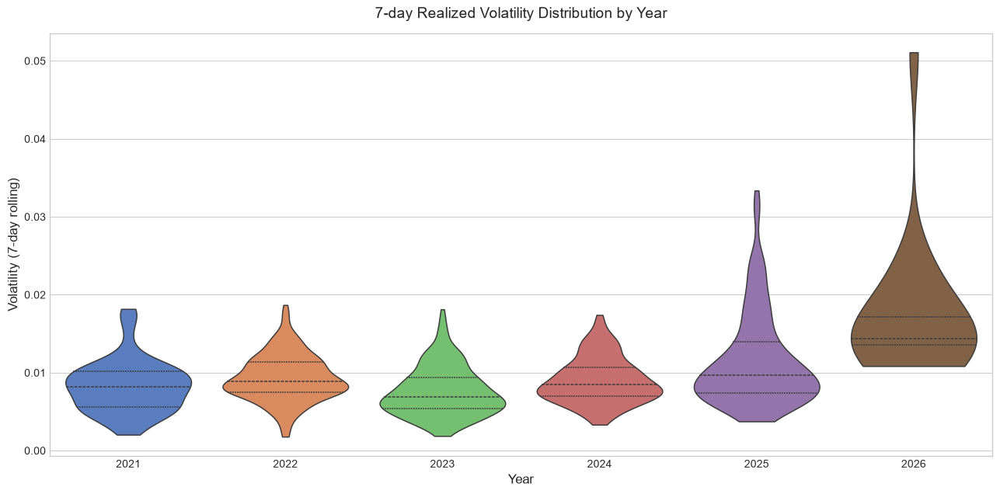


4. RSI Distribution by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


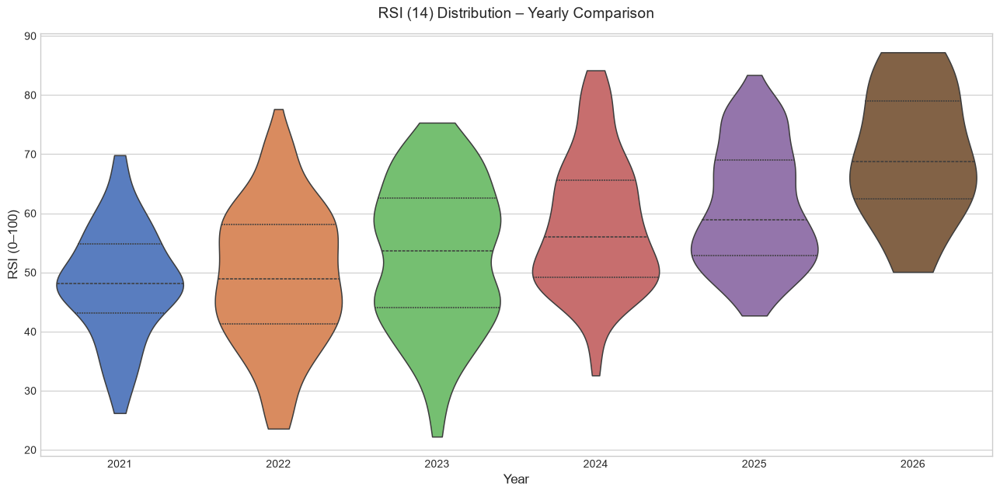


5. Gold Price by Month – Seasonal Shape


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


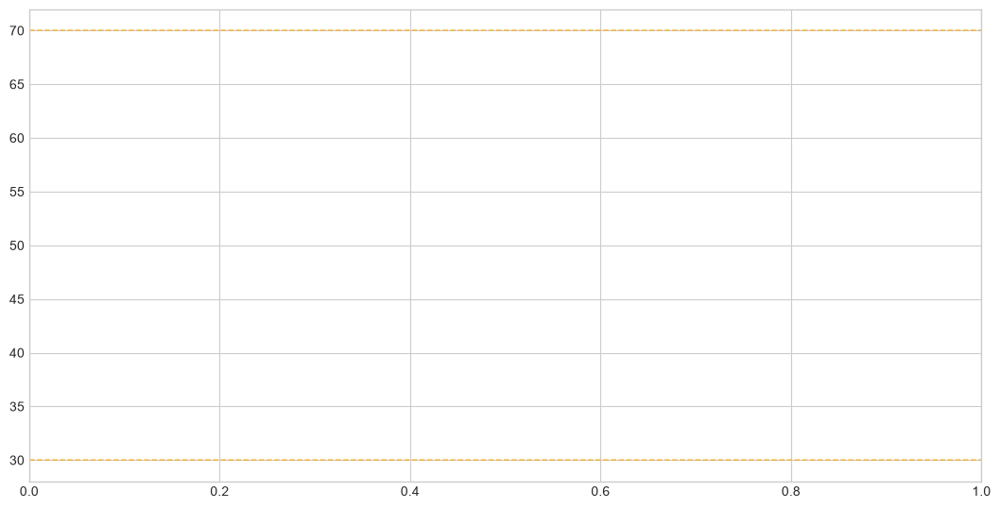

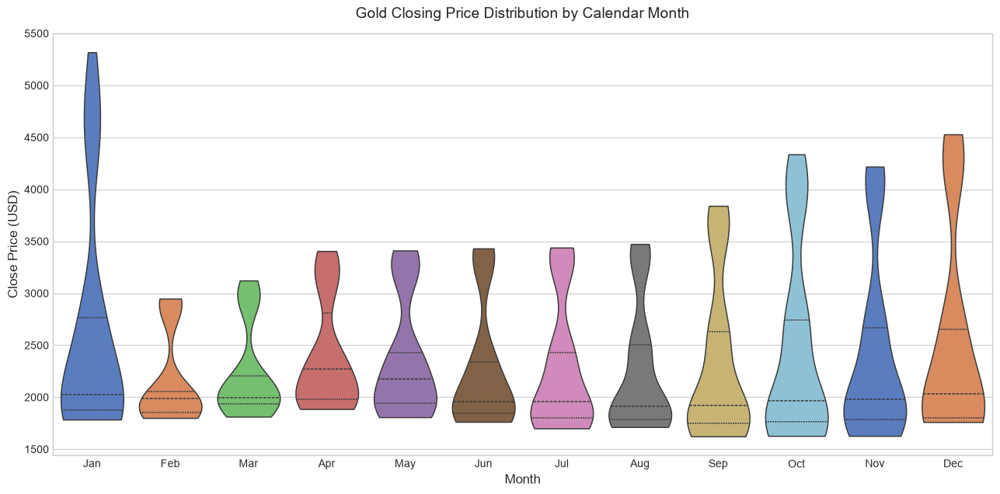


6. Daily Returns – Shape by Month


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


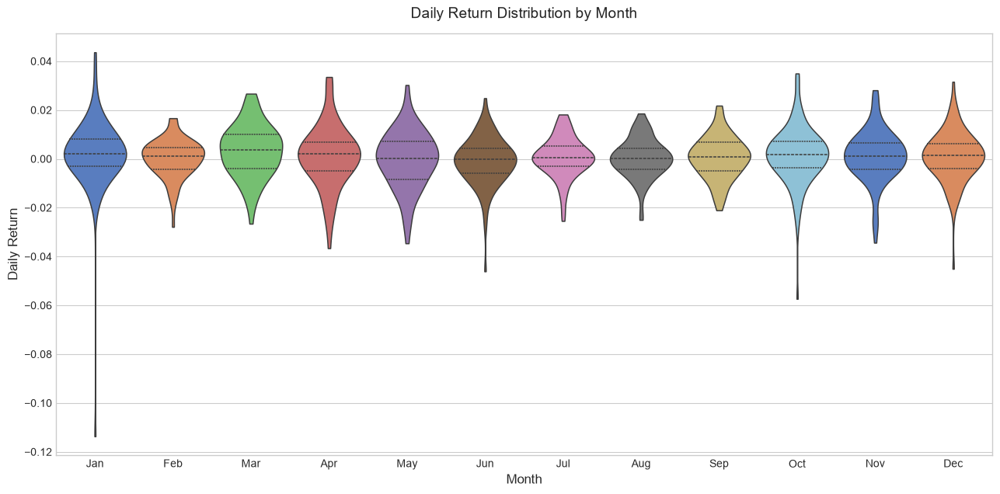


7. Trading Volume by Year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


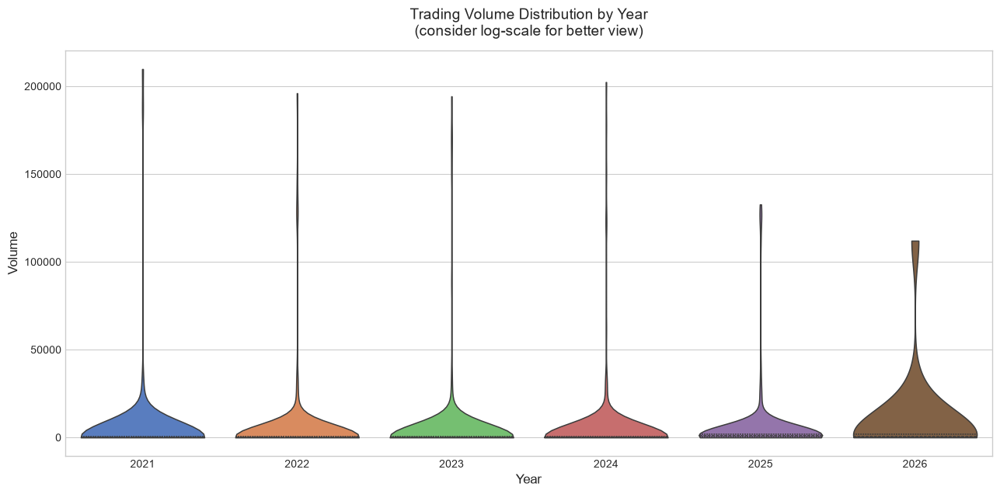


8. MACD Values – Yearly Shape Comparison


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


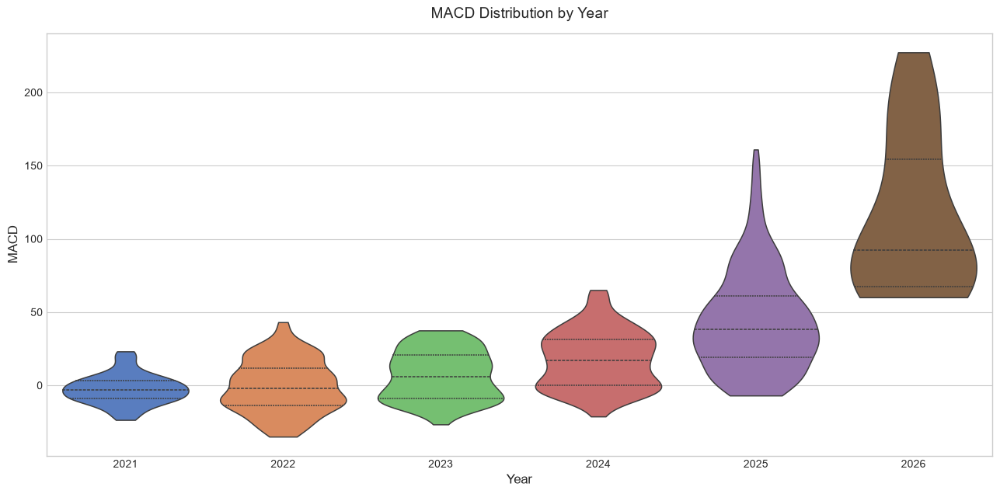


Bonus: Shape of larger daily moves by year


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\92830571.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(


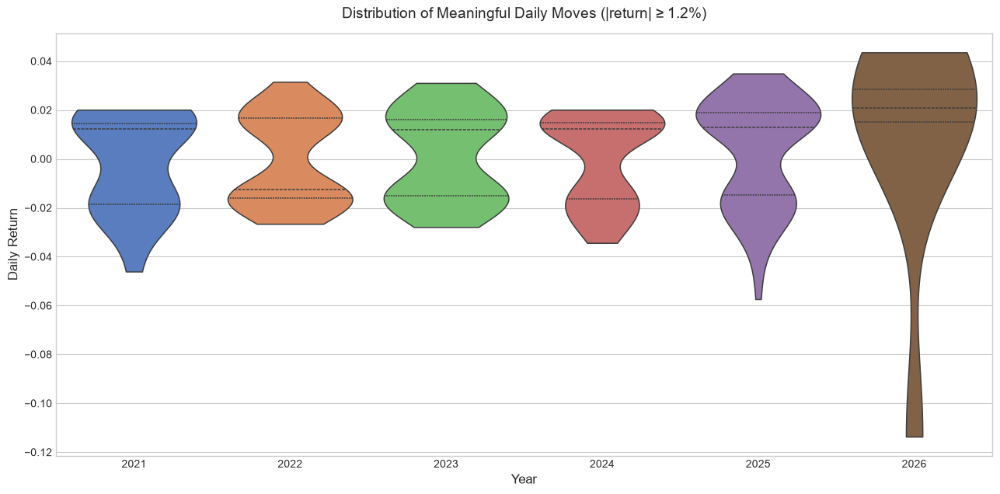

In [9]:
# =============================================================================
#          IMPORTANT VIOLIN PLOTS – Gold Price & Technical Indicators
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─── Styling ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (13, 6.5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# ─── Assuming df is already loaded with datetime index ───────────────────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv", parse_dates=['date'], index_col='date')

# ─── Prepare grouping columns ───────────────────────────────────────────────
df_violin = df.copy()
df_violin['year']       = df_violin.index.year.astype(str)   # better labels
df_violin['month_name'] = df_violin.index.strftime('%b')
df_violin['quarter']    = 'Q' + df_violin.index.quarter.astype(str)

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# ─── Helper function for clean violin plots ─────────────────────────────────
def plot_violin(
    data,
    x,
    y,
    title,
    xlabel="",
    ylabel="",
    hue=None,
    order=None,
    hue_order=None,
    inner="quartile",          # or "box", "point", None
    figsize=(13, 6.5),
    rotate_xticks=0,
    scale="area",              # "area", "count", "width"
    cut=0                      # 0 = no extension beyond data
):
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.violinplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        order=order,
        hue_order=hue_order,
        inner=inner,
        scale=scale,
        cut=cut,
        linewidth=1.1,
        palette="muted",
        ax=ax
    )
    
    ax.set_title(title, pad=14)
    ax.set_xlabel(xlabel or x.replace('_',' ').title())
    ax.set_ylabel(ylabel or y.replace('_',' ').title())
    
    if rotate_xticks:
        plt.xticks(rotation=rotate_xticks, ha='right')
    
    if hue:
        ax.legend(title=hue.replace('_',' ').title(),
                  bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


# ─── 1. Closing price distribution by year ──────────────────────────────────
print("1. Gold Close Price – Violin by Year")
plot_violin(
    data=df_violin,
    x='year',
    y='close',
    title="Distribution of Gold Closing Prices by Year",
    ylabel="Close Price (USD)",
    rotate_xticks=0
)


# ─── 2. Daily returns by year (very important) ──────────────────────────────
print("\n2. Daily Returns – Violin by Year")
plot_violin(
    data=df_violin,
    x='year',
    y='daily_return',
    title="Daily Return Distribution by Year\n(notice fat tails & asymmetry)",
    ylabel="Daily Return",
    inner="quartile",
    rotate_xticks=0
)


# ─── 3. 7-day volatility by year ────────────────────────────────────────────
print("\n3. Short-term Volatility by Year")
plot_violin(
    data=df_violin,
    x='year',
    y='volatility_7',
    title="7-day Realized Volatility Distribution by Year",
    ylabel="Volatility (7-day rolling)",
    rotate_xticks=0
)


# ─── 4. RSI by year ─────────────────────────────────────────────────────────
print("\n4. RSI Distribution by Year")
plot_violin(
    data=df_violin,
    x='year',
    y='rsi',
    title="RSI (14) Distribution – Yearly Comparison",
    ylabel="RSI (0–100)",
    rotate_xticks=0
)
# Add reference lines
plt.axhline(70, color='orange', ls='--', alpha=0.7, lw=1.1)
plt.axhline(30, color='orange', ls='--', alpha=0.7, lw=1.1)


# ─── 5. Gold price by calendar month (seasonality view) ─────────────────────
print("\n5. Gold Price by Month – Seasonal Shape")
plot_violin(
    data=df_violin,
    x='month_name',
    y='close',
    title="Gold Closing Price Distribution by Calendar Month",
    xlabel="Month",
    ylabel="Close Price (USD)",
    order=month_order,
    rotate_xticks=0
)


# ─── 6. Daily returns by month ──────────────────────────────────────────────
print("\n6. Daily Returns – Shape by Month")
plot_violin(
    data=df_violin,
    x='month_name',
    y='daily_return',
    title="Daily Return Distribution by Month",
    xlabel="Month",
    ylabel="Daily Return",
    order=month_order,
    rotate_xticks=0,
    inner="quartile"
)


# ─── 7. Volume distribution by year (usually very skewed) ───────────────────
print("\n7. Trading Volume by Year")
plot_violin(
    data=df_violin,
    x='year',
    y='volume',
    title="Trading Volume Distribution by Year\n(consider log-scale for better view)",
    ylabel="Volume",
    rotate_xticks=0
)
# Suggestion: try log scale
# plt.yscale('log')


# ─── 8. MACD distribution by year ───────────────────────────────────────────
print("\n8. MACD Values – Yearly Shape Comparison")
plot_violin(
    data=df_violin,
    x='year',
    y='macd',
    title="MACD Distribution by Year",
    ylabel="MACD",
    rotate_xticks=0
)


# ─── Bonus: Only larger daily moves (≥ 1.2%) ────────────────────────────────
print("\nBonus: Shape of larger daily moves by year")
large_moves = df_violin[np.abs(df_violin['daily_return']) >= 0.012].copy()
plot_violin(
    data=large_moves,
    x='year',
    y='daily_return',
    title="Distribution of Meaningful Daily Moves (|return| ≥ 1.2%)",
    ylabel="Daily Return",
    rotate_xticks=0,
    inner="quartile"
)

1. Pairplot – Main price & indicator relationships


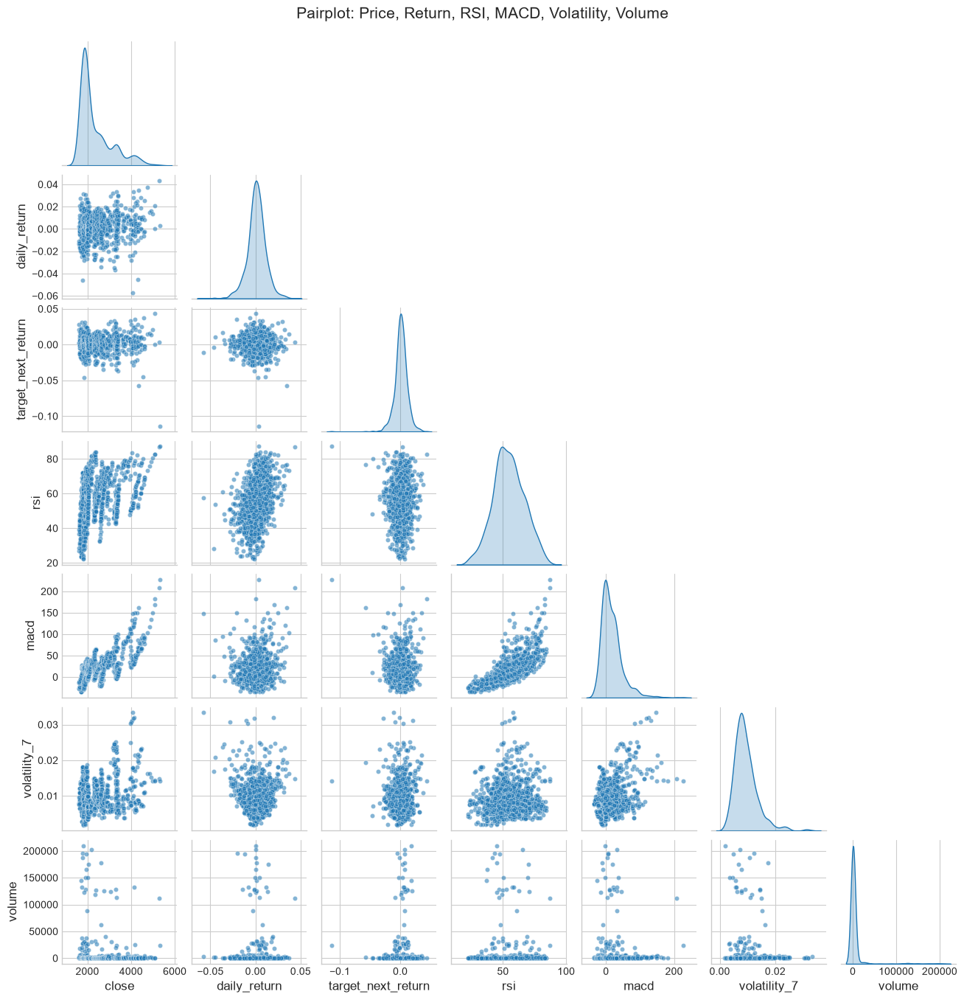


2. Pairplot – colored by daily return direction


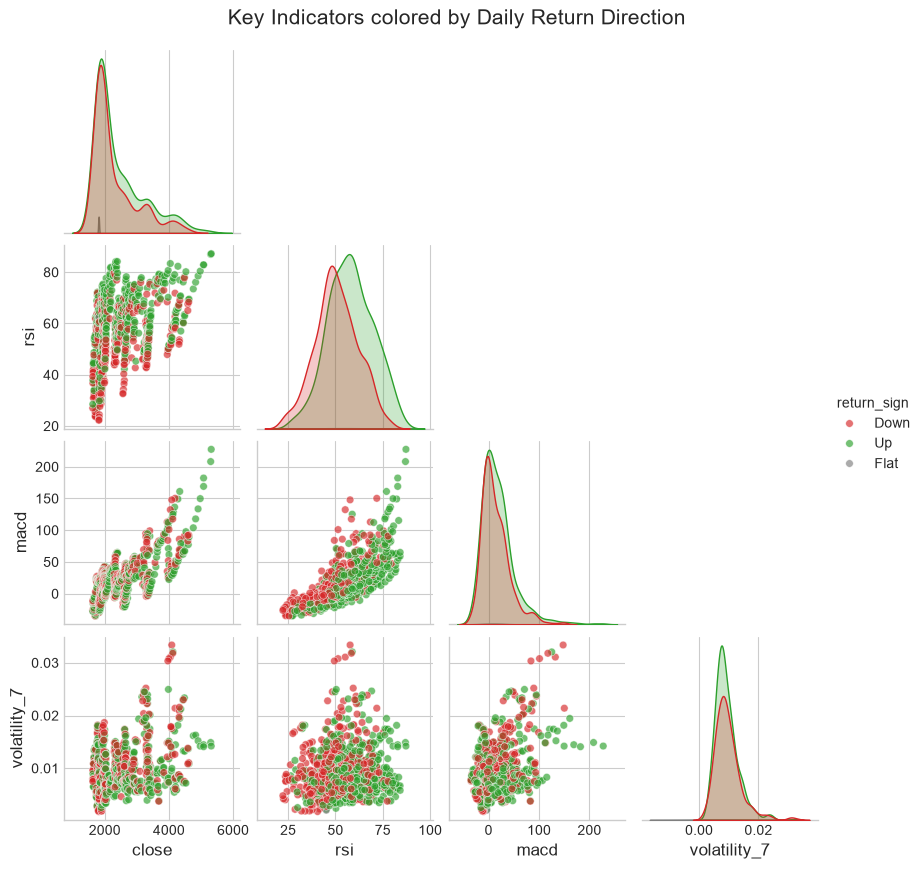


3. Important scatter relationships vs next-day return


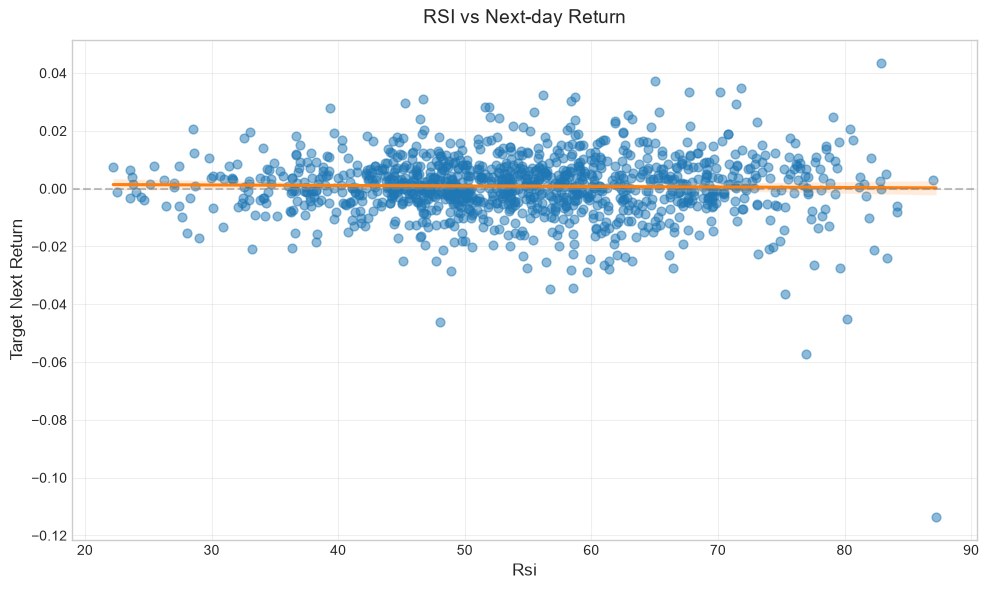

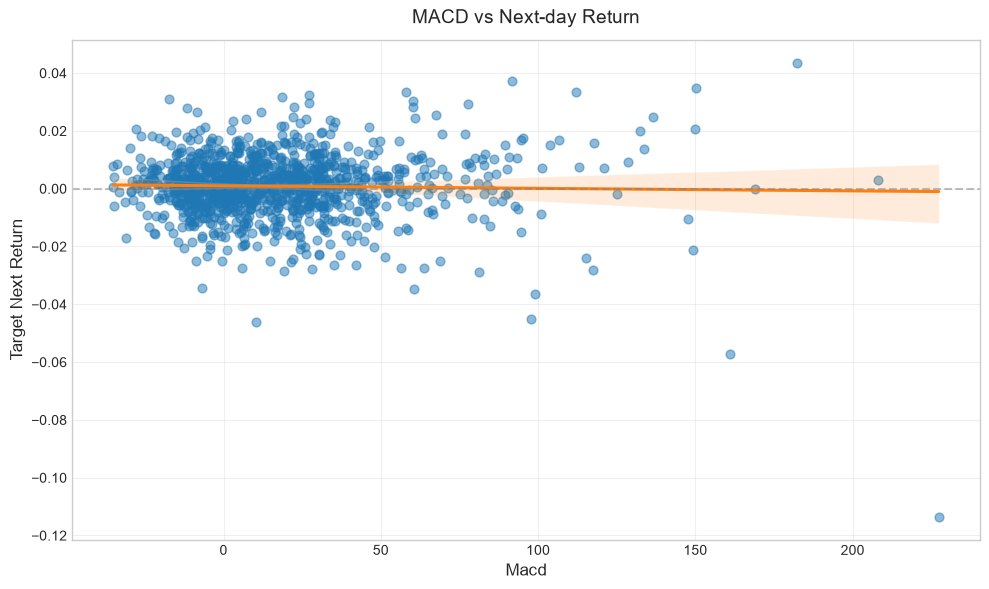

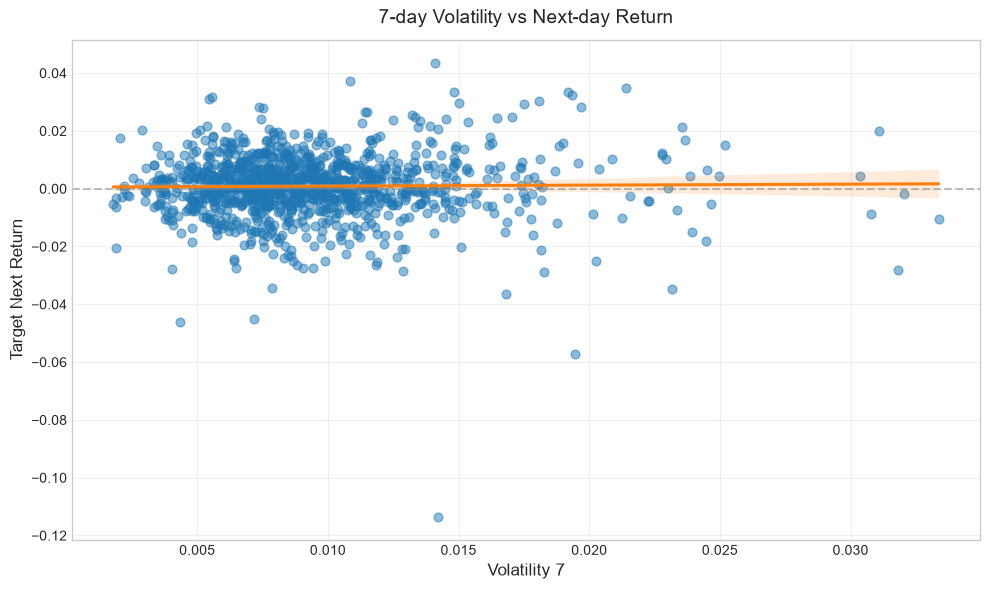

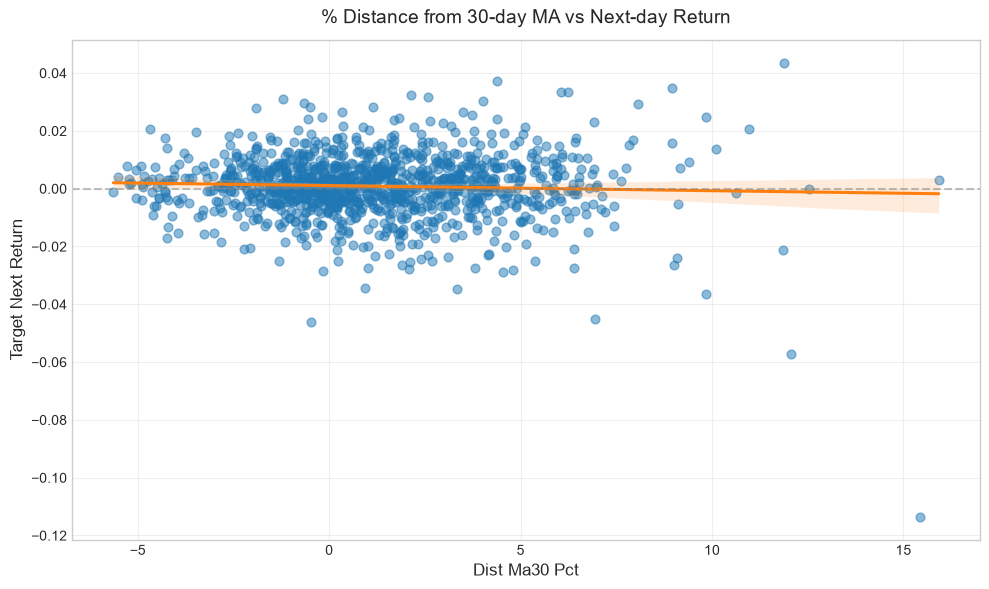

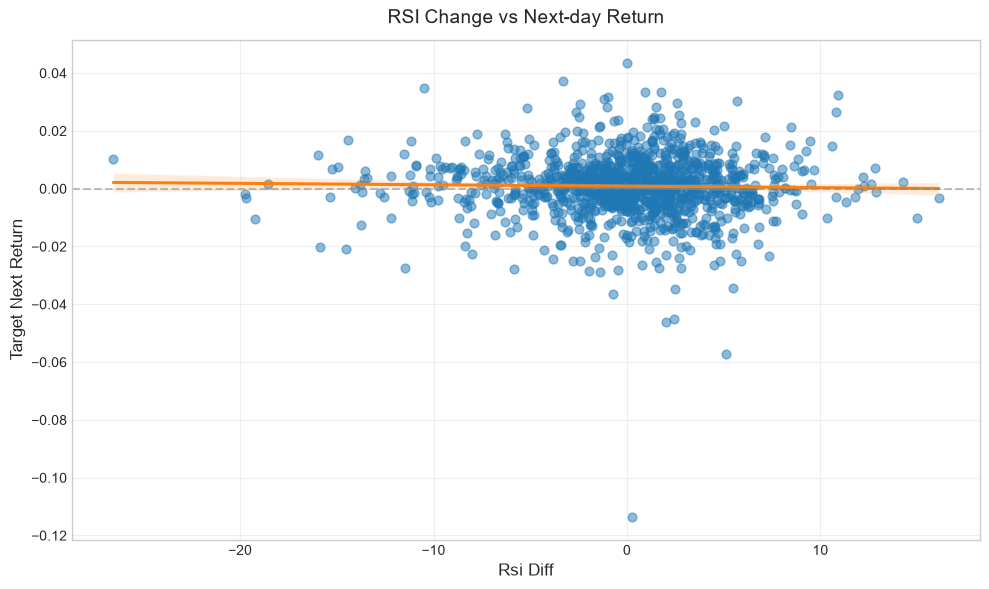

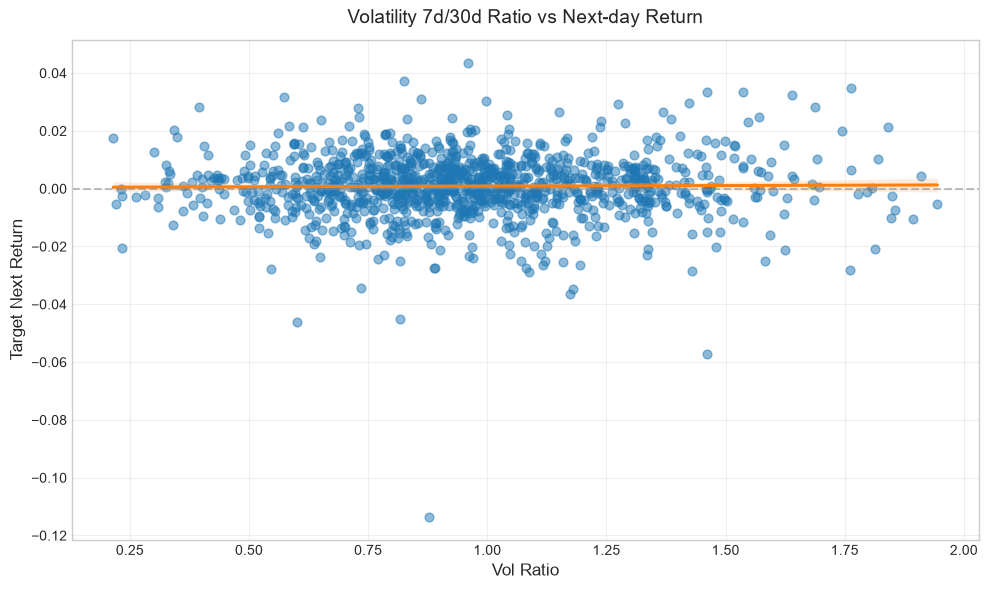


Optional: RSI colored by overbought/oversold zones


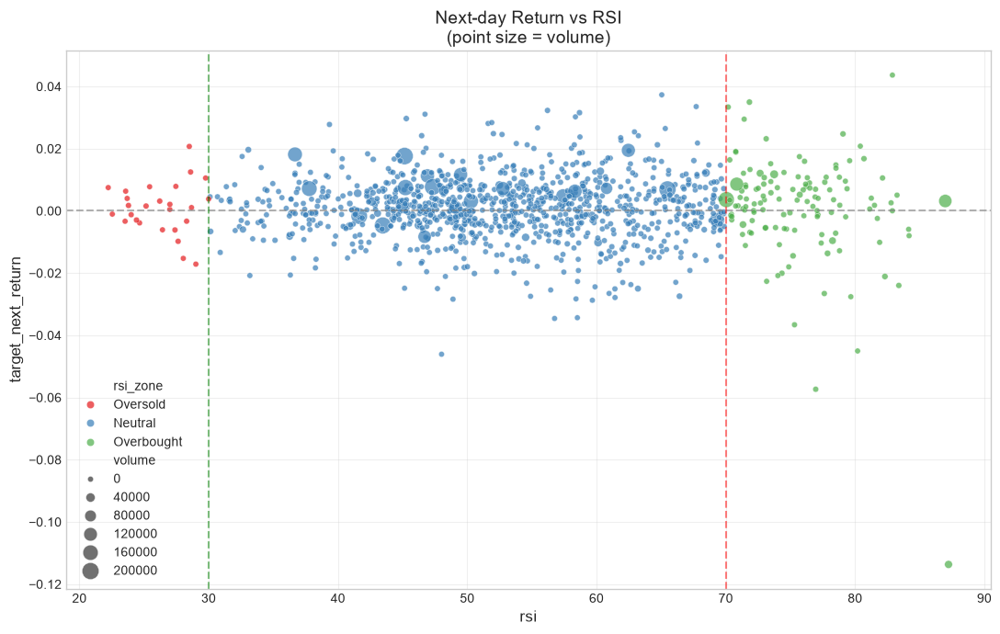

In [10]:
# =============================================================================
#          Pairplots + Important Scatterplots
#          Gold Price Dataset - Feature Exploration
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Styling ────────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 12)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ─── Load / prepare data ────────────────────────────────────────────────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv", parse_dates=['date'], index_col='date')

# Optional: create target = next day return (very common in price prediction)
df['target_next_return'] = df['daily_return'].shift(-1)

# Optional: some quick engineered features (you can add/remove)
df['dist_ma30_pct'] = (df['close'] - df['ma_30']) / df['ma_30'] * 100
df['rsi_diff']      = df['rsi'].diff()
df['vol_ratio']     = df['volatility_7'] / df['volatility_30'].replace(0, np.nan)

# Drop rows with NaN for clean plotting
df_plot = df.dropna().copy()

# ─── 1. Pairplot – Core variables ───────────────────────────────────────────
print("1. Pairplot – Main price & indicator relationships")

core_vars = [
    'close', 'daily_return', 'target_next_return',
    'rsi', 'macd', 'volatility_7', 'volume'
]

g = sns.pairplot(
    df_plot[core_vars],
    diag_kind='kde',
    corner=True,
    height=1.9,
    plot_kws={'s': 20, 'alpha': 0.55, 'color': '#1f77b4'},
    diag_kws={'color': '#1f77b4'}
)

g.fig.suptitle("Pairplot: Price, Return, RSI, MACD, Volatility, Volume", 
               y=1.02, fontsize=15)
plt.show()


# ─── 2. Pairplot with hue = return direction ────────────────────────────────
print("\n2. Pairplot – colored by daily return direction")

df_plot['return_sign'] = np.where(df_plot['daily_return'] > 0, 'Up',
                         np.where(df_plot['daily_return'] < 0, 'Down', 'Flat'))

small_set = ['close', 'rsi', 'macd', 'volatility_7', 'return_sign']

g2 = sns.pairplot(
    df_plot[small_set],
    hue='return_sign',
    palette={'Up':'#2ca02c', 'Down':'#d62728', 'Flat':'#7f7f7f'},
    corner=True,
    height=2.1,
    diag_kind='kde',
    plot_kws={'s': 30, 'alpha': 0.65}
)

g2.fig.suptitle("Key Indicators colored by Daily Return Direction", 
                y=1.03, fontsize=15)
plt.show()


# ─── 3. Focused Scatter plots ───────────────────────────────────────────────
print("\n3. Important scatter relationships vs next-day return")

scatter_pairs = [
    ('rsi',               'target_next_return',  "RSI vs Next-day Return"),
    ('macd',              'target_next_return',  "MACD vs Next-day Return"),
    ('volatility_7',      'target_next_return',  "7-day Volatility vs Next-day Return"),
    ('dist_ma30_pct',     'target_next_return',  "% Distance from 30-day MA vs Next-day Return"),
    ('rsi_diff',          'target_next_return',  "RSI Change vs Next-day Return"),
    ('vol_ratio',         'target_next_return',  "Volatility 7d/30d Ratio vs Next-day Return")
]

for x_var, y_var, title in scatter_pairs:
    if x_var not in df_plot.columns or y_var not in df_plot.columns:
        continue
        
    plt.figure(figsize=(10, 6))
    sns.regplot(
        x=x_var, y=y_var,
        data=df_plot,
        scatter_kws={'alpha':0.5, 's':40, 'color':'#1f77b4'},
        line_kws={'color':'#ff7f0e', 'lw':2.2},
        ci=95,
        scatter=True
    )
    plt.title(title, fontsize=14, pad=12)
    plt.xlabel(x_var.replace('_',' ').title())
    plt.ylabel(y_var.replace('_',' ').title())
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ─── Optional: Zoomed scatter – RSI zones ───────────────────────────────────
print("\nOptional: RSI colored by overbought/oversold zones")

df_plot['rsi_zone'] = pd.cut(
    df_plot['rsi'],
    bins=[0, 30, 70, 100],
    labels=['Oversold', 'Neutral', 'Overbought']
)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    x='rsi', y='target_next_return',
    hue='rsi_zone',
    size='volume',
    sizes=(20, 180),
    alpha=0.7,
    palette='Set1',
    data=df_plot
)
plt.title("Next-day Return vs RSI\n(point size = volume)", fontsize=14)
plt.axhline(0, color='gray', ls='--', alpha=0.6)
plt.axvline(30, color='green', ls='--', alpha=0.5)
plt.axvline(70, color='red', ls='--', alpha=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A. Correlation of engineered features with target & among themselves


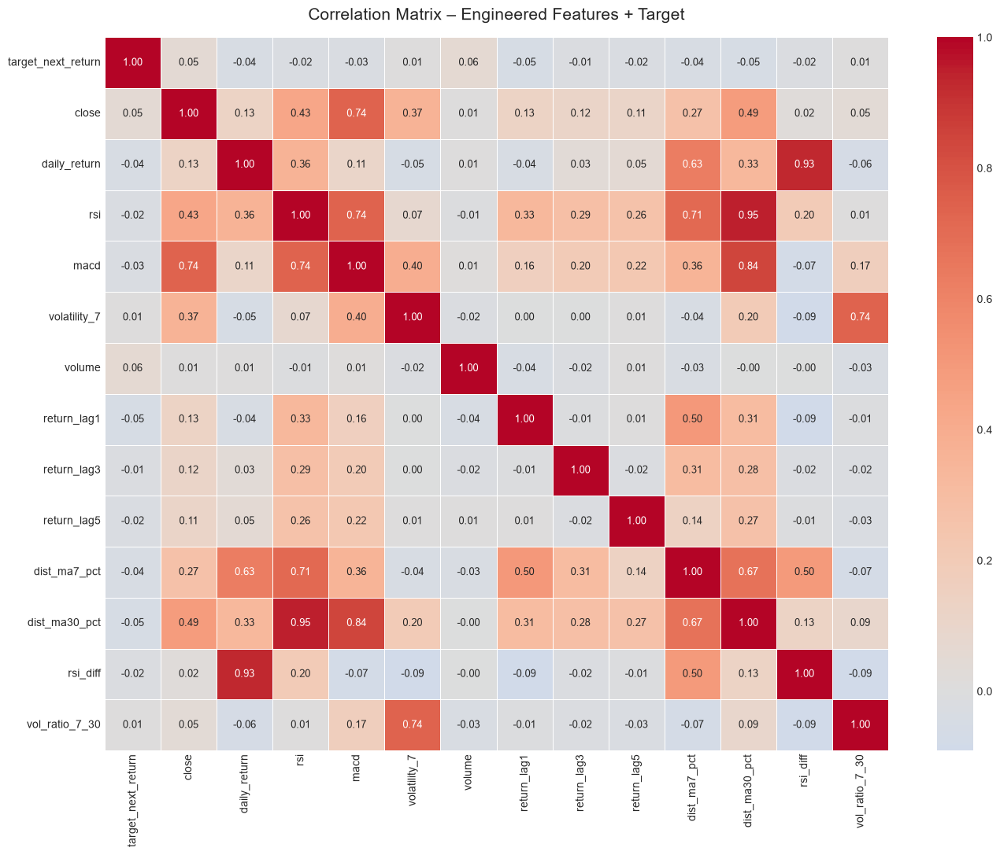


B. Distribution: raw vs engineered features


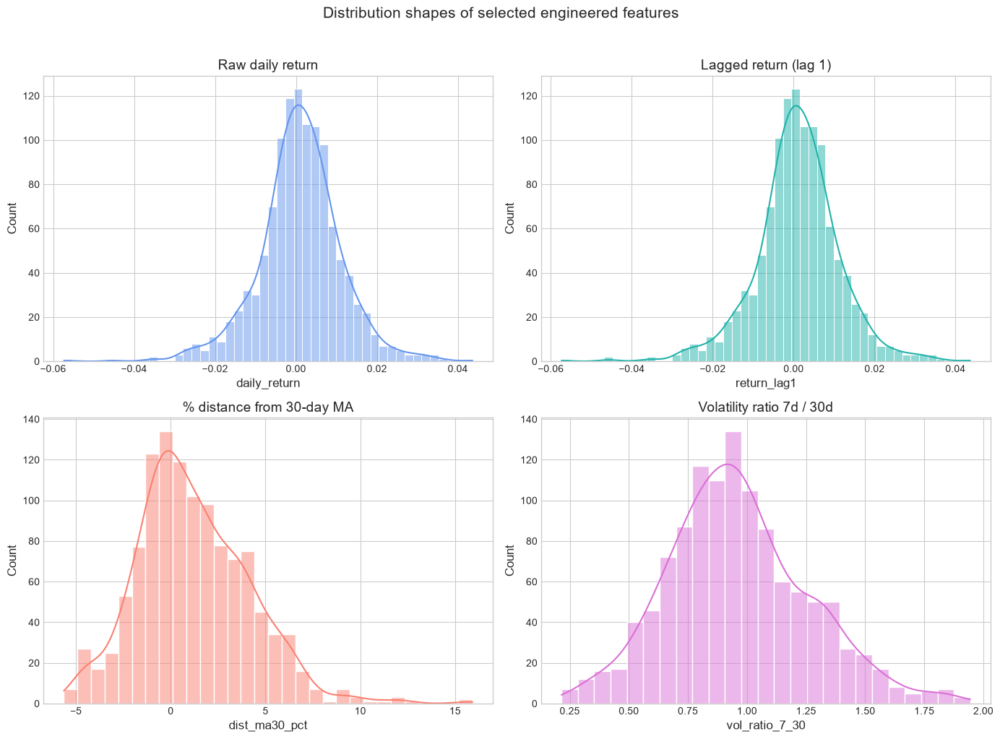


C. Rolling correlation of features with future return


<Figure size 1400x700 with 0 Axes>

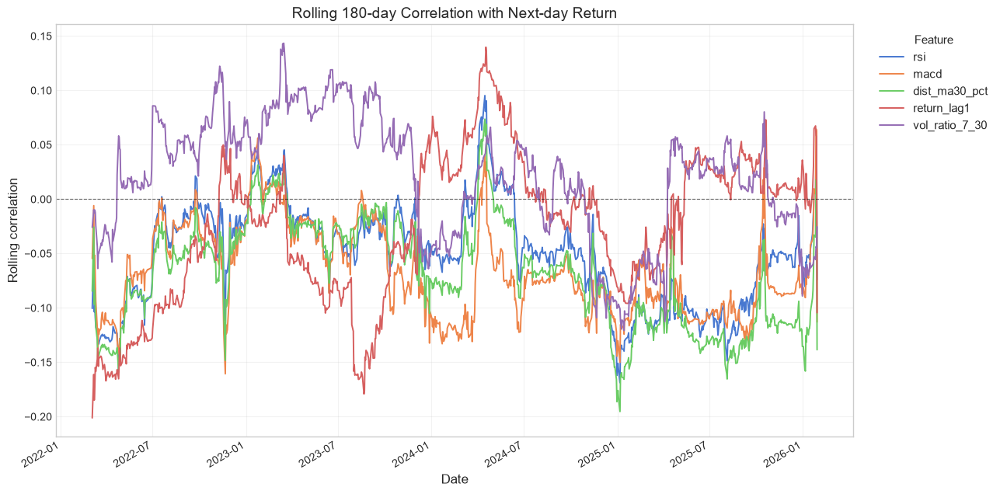


D. Average next return by binned RSI


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10484\1426532520.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped.index, y='mean', data=grouped.reset_index(), palette='viridis')


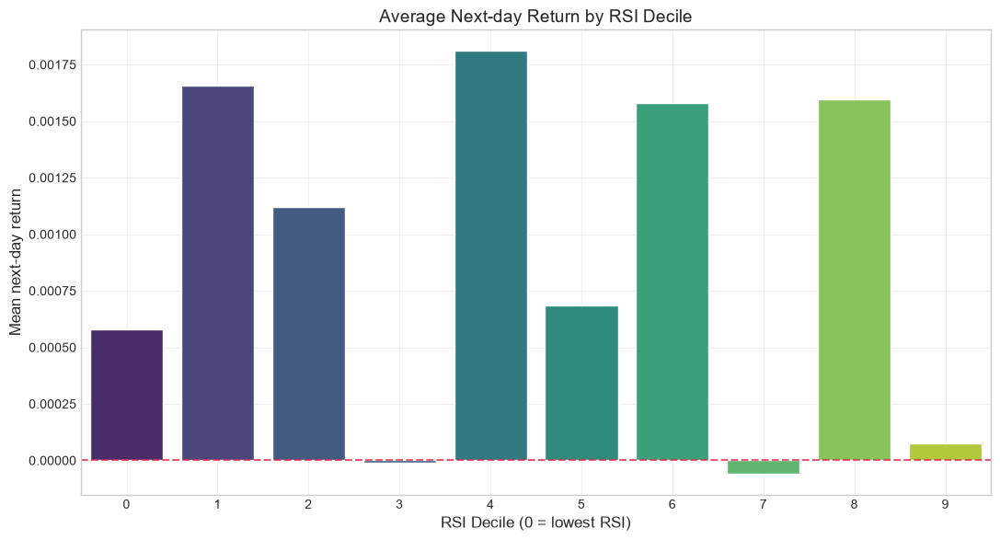

In [11]:
# =============================================================================
#         IMPORTANT FEATURE ENGINEERING VISUALIZATIONS
#         Gold Price Forecasting / Time Series
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ─── Styling ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (13, 6.5)
plt.rcParams['font.size'] = 11

# ─── 1. Create a few typical new features (examples) ────────────────────────
df_eng = df.copy()

# Lagged returns
for lag in [1, 3, 5]:
    df_eng[f'return_lag{lag}'] = df_eng['daily_return'].shift(lag)

# Price distance from moving averages (%)
df_eng['dist_ma7_pct']  = (df_eng['close'] - df_eng['ma_7'])  / df_eng['ma_7']  * 100
df_eng['dist_ma30_pct'] = (df_eng['close'] - df_eng['ma_30']) / df_eng['ma_30'] * 100

# RSI change / acceleration
df_eng['rsi_diff'] = df_eng['rsi'].diff()

# Volatility ratio
df_eng['vol_ratio_7_30'] = df_eng['volatility_7'] / df_eng['volatility_30']

# Target = next day return (common in many strategies)
df_eng['target_next_return'] = df_eng['daily_return'].shift(-1)

# Drop rows with NaN (for clean visualization)
df_eng = df_eng.dropna().copy()

# ─── A. Correlation heatmap – which new features correlate with target? ─────
print("A. Correlation of engineered features with target & among themselves")

corr_cols = [
    'target_next_return', 'close', 'daily_return',
    'rsi', 'macd', 'volatility_7', 'volume',
    'return_lag1', 'return_lag3', 'return_lag5',
    'dist_ma7_pct', 'dist_ma30_pct', 'rsi_diff', 'vol_ratio_7_30'
]

corr = df_eng[corr_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title("Correlation Matrix – Engineered Features + Target", fontsize=15, pad=16)
plt.tight_layout()
plt.show()


# ─── B. Distribution comparison – before vs after transformation ────────────
print("\nB. Distribution: raw vs engineered features")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_eng['daily_return'], kde=True, ax=axes[0,0], color='cornflowerblue')
axes[0,0].set_title("Raw daily return")

sns.histplot(df_eng['return_lag1'], kde=True, ax=axes[0,1], color='lightseagreen')
axes[0,1].set_title("Lagged return (lag 1)")

sns.histplot(df_eng['dist_ma30_pct'], kde=True, ax=axes[1,0], color='salmon')
axes[1,0].set_title("% distance from 30-day MA")

sns.histplot(df_eng['vol_ratio_7_30'], kde=True, ax=axes[1,1], color='orchid')
axes[1,1].set_title("Volatility ratio 7d / 30d")

plt.suptitle("Distribution shapes of selected engineered features", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


# ─── C. Rolling correlation with target (feature stability over time) ───────
print("\nC. Rolling correlation of features with future return")

window = 180  # ~6 months

rolling_corr = {}
for col in ['rsi', 'macd', 'dist_ma30_pct', 'return_lag1', 'vol_ratio_7_30']:
    rolling_corr[col] = df_eng[col].rolling(window).corr(df_eng['target_next_return'])

rolling_df = pd.DataFrame(rolling_corr)

plt.figure(figsize=(14, 7))
rolling_df.plot(linewidth=1.4)
plt.title(f"Rolling {window}-day Correlation with Next-day Return", fontsize=14)
plt.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)
plt.ylabel("Rolling correlation")
plt.xlabel("Date")
plt.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ─── D. Target grouped by binned feature (non-linear relationship check) ─────
print("\nD. Average next return by binned RSI")

df_eng['rsi_bin'] = pd.qcut(df_eng['rsi'], q=10, labels=False, duplicates='drop')

grouped = df_eng.groupby('rsi_bin')['target_next_return'].agg(['mean','count','std'])

plt.figure(figsize=(11, 6))
sns.barplot(x=grouped.index, y='mean', data=grouped.reset_index(), palette='viridis')
plt.axhline(0, color='crimson', ls='--', alpha=0.7)
plt.title("Average Next-day Return by RSI Decile", fontsize=14)
plt.xlabel("RSI Decile (0 = lowest RSI)")
plt.ylabel("Mean next-day return")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
%pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.2 MB/s eta 0:00:10
   --- ------------------------------------ 1.0/12.1 MB 1.3 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/12.1 MB 1.3 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/12.1 MB 1.3 MB/s eta 0:00:09
   ------ --------------------------------- 1.8/12.1 MB 1.3 MB/s eta 0:00:09
   ------ --------------------------------- 1.8/12.1 MB 1.3 MB/s eta 0:00:09
   ------- -------------------------------- 2.4/12.1 MB 1.2 MB/s eta 0:00:08
   -------- ------------------------------- 2.6/12.1 MB 1.3 MB/s eta 0:00:08
   -------- ------------------------------- 2.6/12.1 MB 1.3 MB/s eta 0:00:08
   ---------- -------------

In [16]:
%pip install PyWavelets

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.2 MB 2.8 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.2 MB 2.6 MB/s eta 0:00:02
   ----------------- ---------------------- 1.8/4.2 MB 2.4 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.2 MB 2.6 MB/s eta 0:00:01
   -------------------------------- ------- 3.4/4.2 MB 2.8 MB/s eta 0:00:01
   ------------------------------------- -- 3.9/4.2 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------  4.2/4.2 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 2.5 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


Data loaded. Shape: (1211, 18)
Date range: 2021-06-11 00:00:00 to 2026-01-30 00:00:00

1. Basic Price Time Series Plot


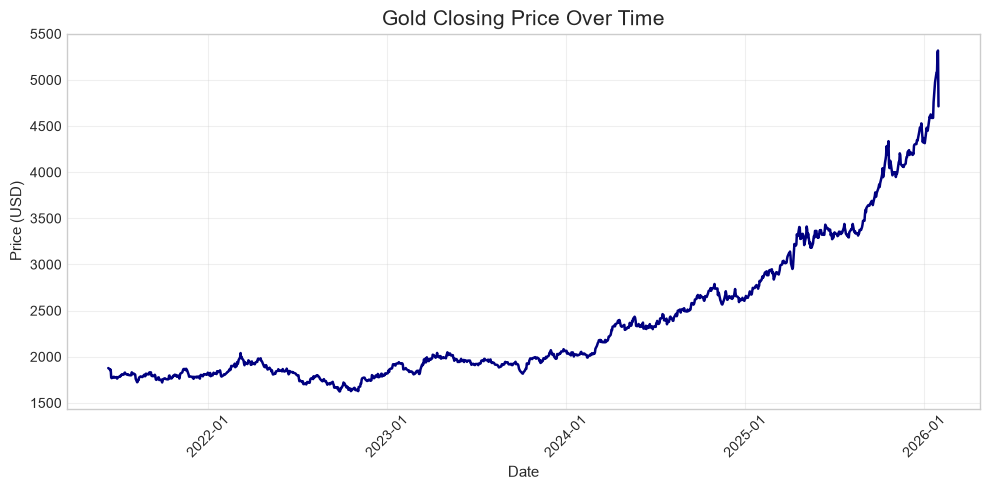


2. Daily Returns Time Series Plot


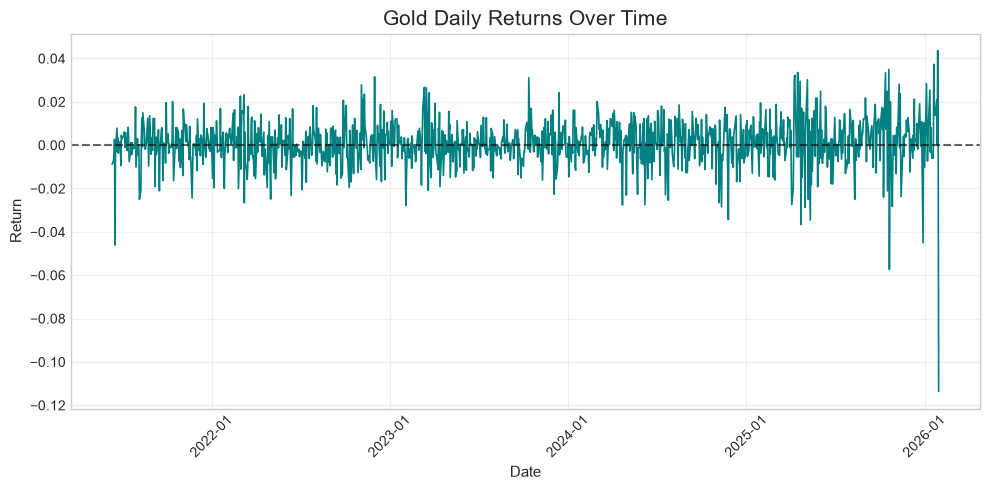


3. Rolling Volatility Time Series Plot


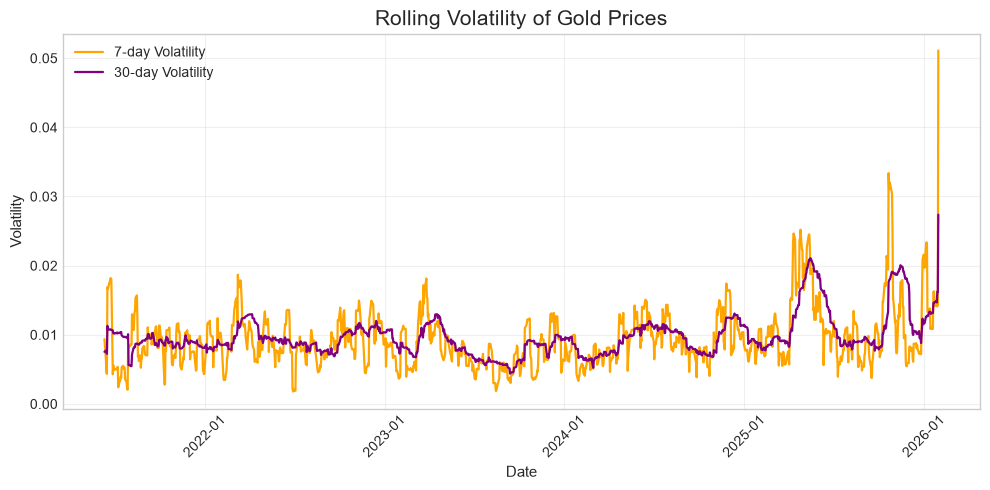


4. Seasonal Decomposition Plot


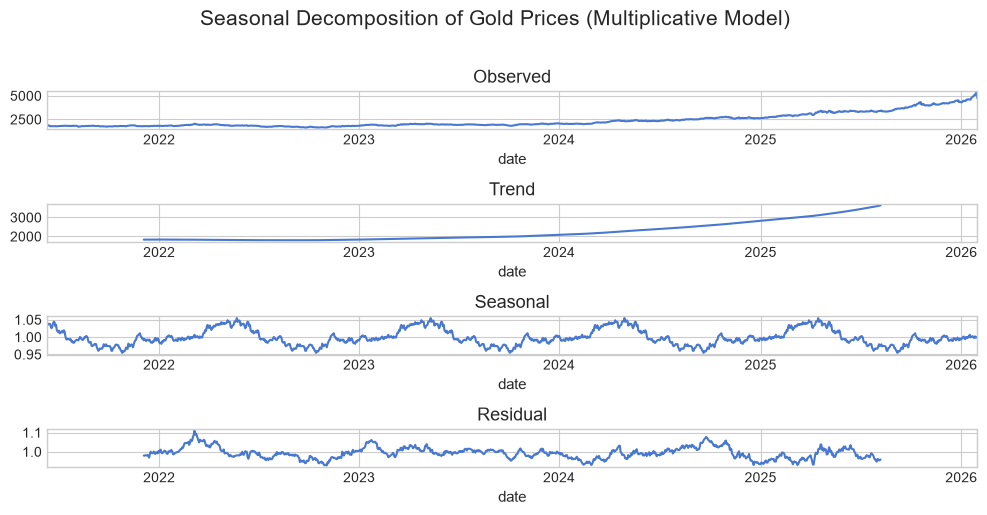


5. ACF and PACF Plots for Returns


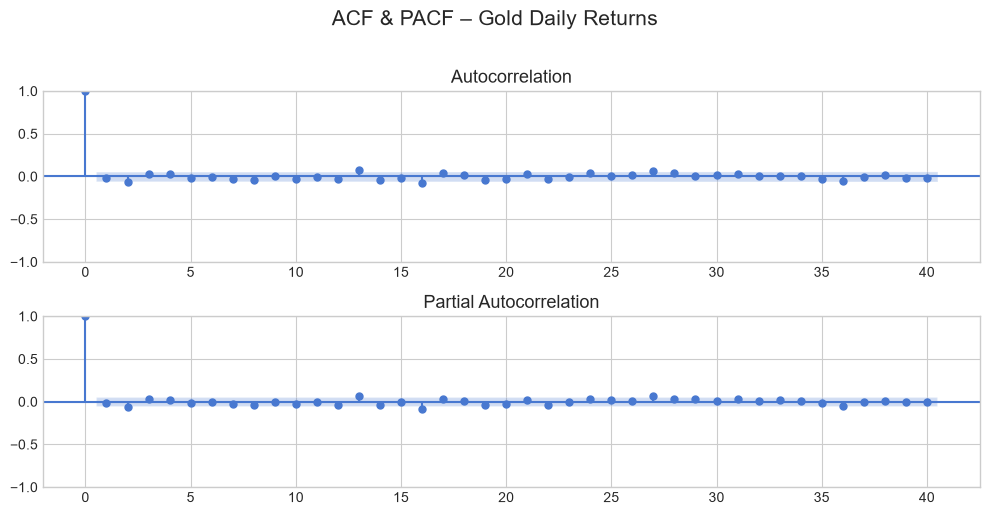


6. Hodrick-Prescott Filter Plot


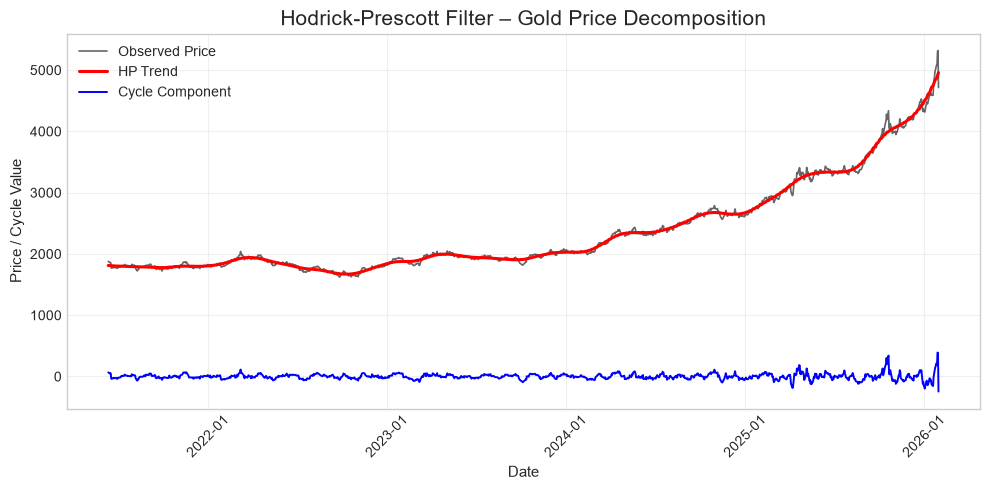


7. Cumulative Returns Plot


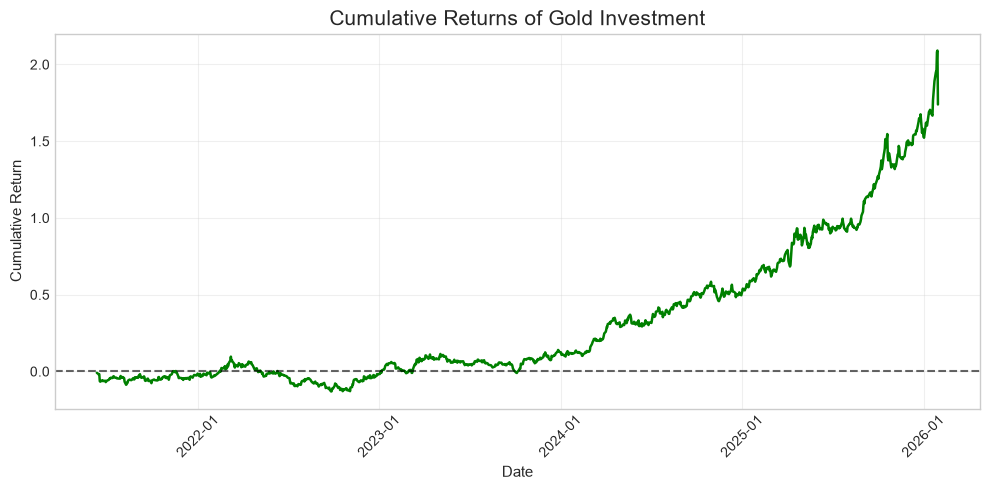


8. Prophet Forecast Plot for Next 5 Years


22:35:50 - cmdstanpy - INFO - Chain [1] start processing
22:35:52 - cmdstanpy - INFO - Chain [1] done processing


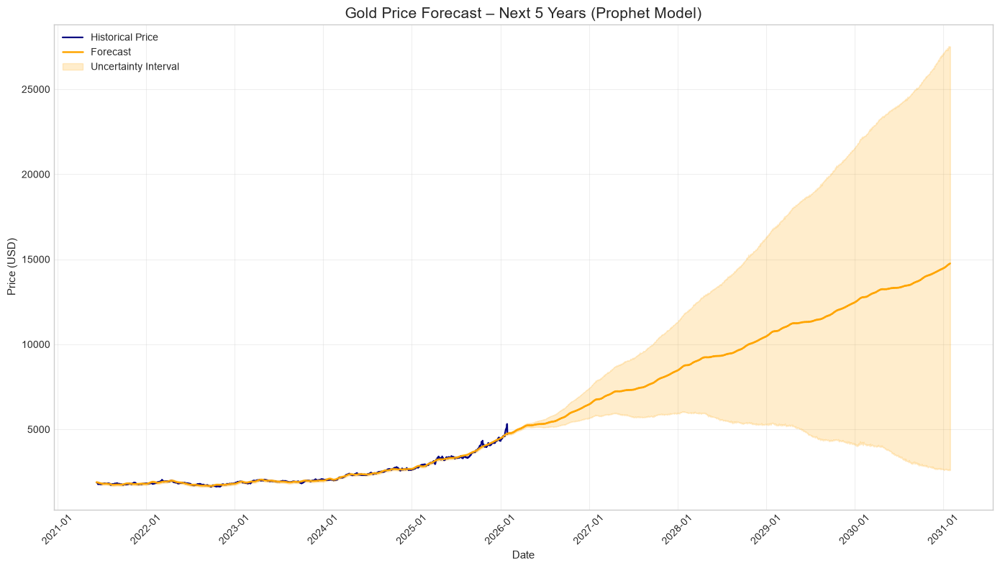


9. ARIMA Forecast Plot for Next 5 Years


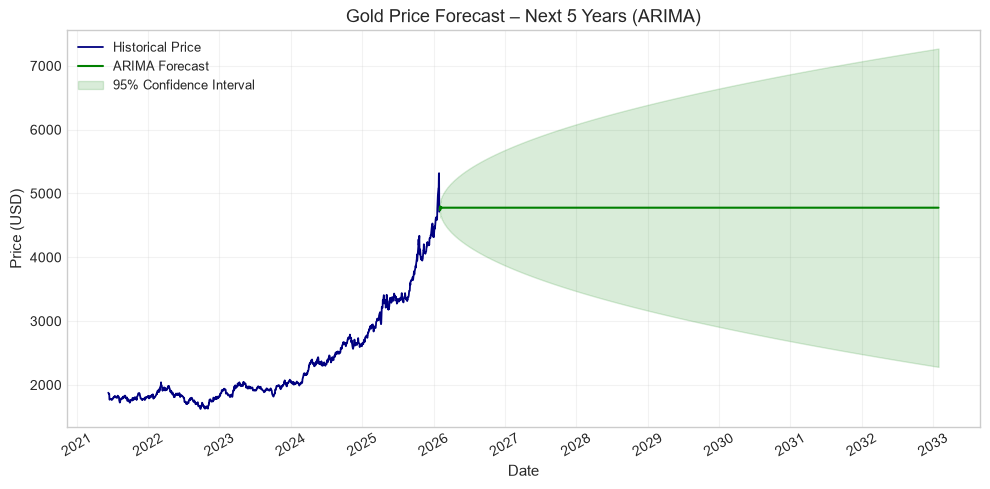


10. Wavelet Power Spectrum Plot


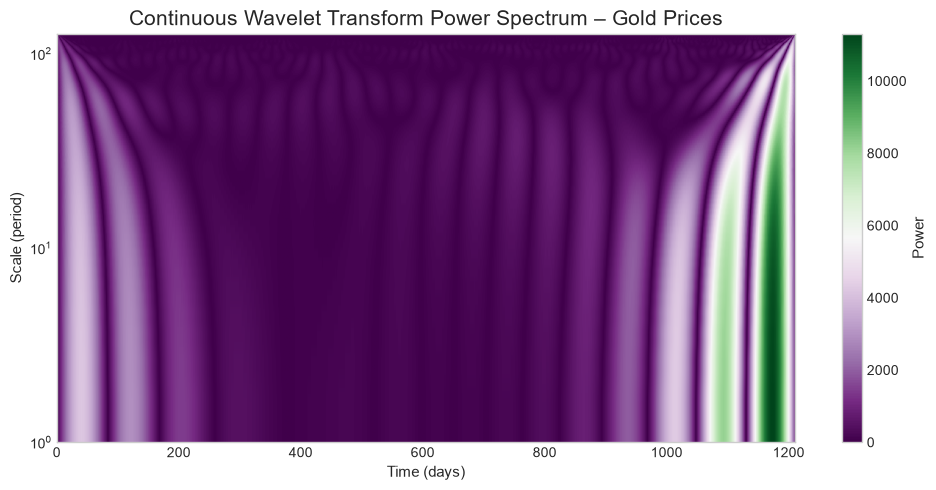

In [17]:
# =============================================================================
#          IMPORTANT TIME SERIES PLOTS 
#          Gold Price Analysis + 5-Year Forecast
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import matplotlib.dates as mdates

# ─── Styling ────────────────────────────────────────────────────────────────
# ─── Styling ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# Compact notebook-friendly graphs
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# ─── Load the dataset ───────────────────────────────────────────────────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Quick preprocessing: fill minor gaps if any, compute log returns
df = df.asfreq('B').ffill()  # Business days frequency, forward fill weekends/holidays
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

print("Data loaded. Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())

# =============================================================================
# 1. Basic Time Series Plot – Price Over Time
# =============================================================================
print("\n1. Basic Price Time Series Plot")
plt.figure()
plt.plot(df.index, df['close'], label='Close Price', color='navy', lw=1.8)
plt.title("Gold Closing Price Over Time", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Description: Simple line plot showing the overall trend in gold prices. 
# Useful for spotting long-term uptrends, volatility clusters, and major events.

# =============================================================================
# 2. Returns Time Series Plot
# =============================================================================
print("\n2. Daily Returns Time Series Plot")
plt.figure()
plt.plot(df.index, df['daily_return'], label='Daily Return', color='teal', lw=1.2)
plt.axhline(0, color='black', ls='--', alpha=0.6)
plt.title("Gold Daily Returns Over Time", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Description: Shows percentage changes day-to-day. Highlights volatility spikes 
# (e.g., during crises) and periods of calm. Useful for risk assessment.

# =============================================================================
# 3. Rolling Volatility Plot
# =============================================================================
print("\n3. Rolling Volatility Time Series Plot")
plt.figure()
plt.plot(df.index, df['volatility_7'], label='7-day Volatility', color='orange', lw=1.6)
plt.plot(df.index, df['volatility_30'], label='30-day Volatility', color='purple', lw=1.6)
plt.title("Rolling Volatility of Gold Prices", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Description: Compares short vs medium-term risk levels. Spikes indicate 
# turbulent periods; useful for regime detection.

# =============================================================================
# 4. Seasonal Decomposition Plot (Trend + Seasonal + Residual)
# =============================================================================
print("\n4. Seasonal Decomposition Plot")
decomp = seasonal_decompose(df['close'], model='multiplicative', period=252)  # ~1 year trading days

fig, axes = plt.subplots(4, 1, figsize=(10,5))
decomp.observed.plot(ax=axes[0], title="Observed")
decomp.trend.plot(ax=axes[1], title="Trend")
decomp.seasonal.plot(ax=axes[2], title="Seasonal")
decomp.resid.plot(ax=axes[3], title="Residual")

plt.suptitle("Seasonal Decomposition of Gold Prices (Multiplicative Model)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Description: Breaks price into trend, seasonal patterns, and noise. 
# Helps identify cyclical behaviors (e.g., yearly gold demand cycles).

# =============================================================================
# 5. ACF & PACF Plots (Autocorrelation Structure)
# =============================================================================
print("\n5. ACF and PACF Plots for Returns")
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(df['daily_return'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['daily_return'].dropna(), lags=40, ax=axes[1])
plt.suptitle("ACF & PACF – Gold Daily Returns", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Description: Measures how current values correlate with past lags. 
# Essential for ARIMA modeling; spikes at certain lags indicate seasonality.

# =============================================================================
# 6. Hodrick-Prescott Filter (Advanced Trend-Cycle Separation)
# =============================================================================
print("\n6. Hodrick-Prescott Filter Plot")
cycle, trend = hpfilter(df['close'], lamb=1600 * 4**2)  # Adjusted for daily data

plt.figure()
plt.plot(df.index, df['close'], label='Observed Price', color='black', alpha=0.6, lw=1.2)
plt.plot(df.index, trend, label='HP Trend', color='red', lw=2.2)
plt.plot(df.index, cycle, label='Cycle Component', color='blue', lw=1.4)
plt.title("Hodrick-Prescott Filter – Gold Price Decomposition", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Price / Cycle Value")
plt.legend()
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Description: Advanced smoothing to separate smooth trend from business cycles. 
# Cycle plot shows deviations from trend; useful for economic analysis.

# =============================================================================
# 7. Cumulative Returns Plot (Advanced Performance View)
# =============================================================================
print("\n7. Cumulative Returns Plot")
df['cum_return'] = (1 + df['daily_return']).cumprod() - 1

plt.figure()
plt.plot(df.index, df['cum_return'], label='Cumulative Return', color='green', lw=1.8)
plt.title("Cumulative Returns of Gold Investment", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.axhline(0, color='black', ls='--', alpha=0.6)
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Description: Shows total growth over time assuming buy-and-hold. 
# Highlights compounding effects and drawdowns.

# =============================================================================
# 8. 5-Year Forecast using Prophet (Advanced Technique)
# =============================================================================
print("\n8. Prophet Forecast Plot for Next 5 Years")

# Prepare data for Prophet
prophet_df = df.reset_index()[['date', 'close']].rename(columns={'date': 'ds', 'close': 'y'})

model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# Forecast next 5 years (approx 1825 days, including weekends)
future = model.make_future_dataframe(periods=1825)
forecast = model.predict(future)

# Plot
fig = plt.figure(figsize=(14, 8))
plt.plot(df.index, df['close'], label='Historical Price', color='navy', lw=1.6)
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='orange', lw=1.8)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                 color='orange', alpha=0.2, label='Uncertainty Interval')

plt.title("Gold Price Forecast – Next 5 Years (Prophet Model)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Description: Uses Prophet for trend + seasonality forecasting. 
# Advanced Bayesian approach; shows predicted prices + confidence bands.

# =============================================================================
# 9. ARIMA Forecast for Next 5 Years
# =============================================================================

print("\n9. ARIMA Forecast Plot for Next 5 Years")

from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA model
arima_model = ARIMA(df['close'], order=(5, 1, 0))
arima_fit = arima_model.fit()

# Forecast next 1825 days (~5 years)
arima_forecast = arima_fit.get_forecast(steps=1825)

arima_mean = arima_forecast.predicted_mean
arima_conf = arima_forecast.conf_int(alpha=0.05)

# Create future dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=1825,
    freq='B'
)

# Compact figure
plt.figure(figsize=(10, 5))

plt.plot(
    df.index,
    df['close'],
    label='Historical Price',
    color='navy',
    lw=1.3
)

plt.plot(
    future_dates,
    arima_mean,
    label='ARIMA Forecast',
    color='green',
    lw=1.5
)

plt.fill_between(
    future_dates,
    arima_conf.iloc[:, 0],
    arima_conf.iloc[:, 1],
    color='green',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title("Gold Price Forecast – Next 5 Years (ARIMA)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend(fontsize=9)
plt.grid(alpha=0.25)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# =============================================================================
# 10. Wavelet Power Spectrum (Advanced Frequency Domain Analysis)
# =============================================================================
print("\n10. Wavelet Power Spectrum Plot")

from pywt import cwt

# Prepare data
prices = df['close'].values
time = np.arange(len(prices))

# Continuous Wavelet Transform (Morlet wavelet common for finance)
scales = np.arange(1, 128)  # powers of 2 for dyadic scales
cwtmatr, freqs = cwt(prices, scales, 'morl')

plt.figure(figsize=(10, 5))
plt.imshow(np.abs(cwtmatr), extent=[0, len(prices), 1, max(scales)], 
           cmap='PRGn', aspect='auto', vmax=abs(cwtmatr).max(), vmin=0)
plt.colorbar(label='Power')
plt.yscale('log')
plt.title("Continuous Wavelet Transform Power Spectrum – Gold Prices", fontsize=15)
plt.xlabel("Time (days)")
plt.ylabel("Scale (period)")
plt.grid(False)
plt.tight_layout()
plt.show()

In [19]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.0 MB/s eta 0:01:37
   ---------------------------------------- 0.8/101.7 MB 1.0 MB/s eta 0:01:40
   ---------------------------------------- 1.0/101.7 MB 1.1 MB/s eta 0:01:33
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 1.8/101.7 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 2.1/101.7 MB 1.4 MB/s eta 0:01:13
   - -------------------------------------- 2.6/101.7 MB 1.4 MB/s eta 0:01:10
   - -------------------------------------- 2.9/101.7 MB 1.4 MB/s eta 0:01:09
   - -------------------------------------- 3.1/101.7 MB 1.4 MB/s eta 0:01:09
   - -------------------------------------- 3.4/101.7 MB 1.4 MB/s eta 0:01:09
   - --

Linear Regression - MAE: 41.33, RMSE: 65.79, R2: 0.98
Random Forest - MAE: 759.38, RMSE: 921.77, R2: -2.02
XGBoost - MAE: 783.71, RMSE: 937.04, R2: -2.12


c:\Users\ADMIN\anaconda3\envs\data_science\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step
LSTM - MAE: 3624.60, RMSE: 3663.20, R2: -46.69

A. Model Comparison Plot


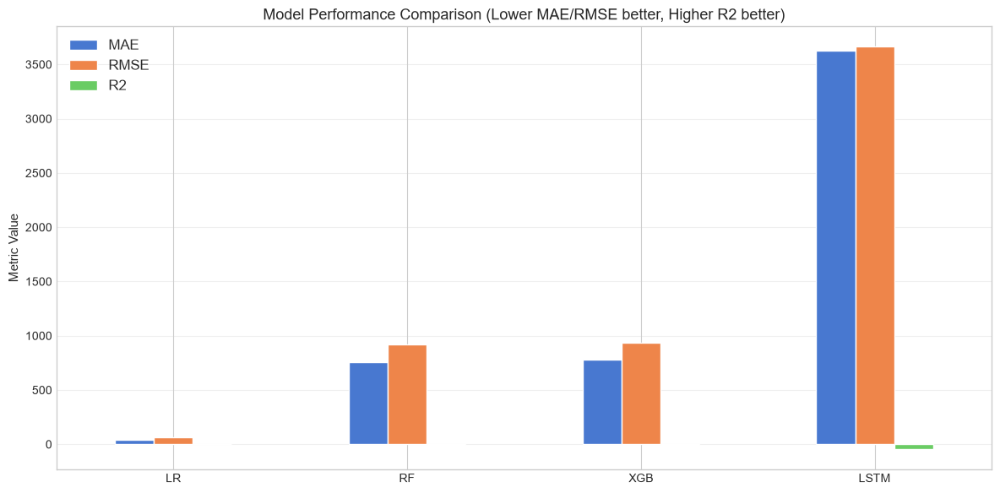


B. Actual vs Predicted Line Plots


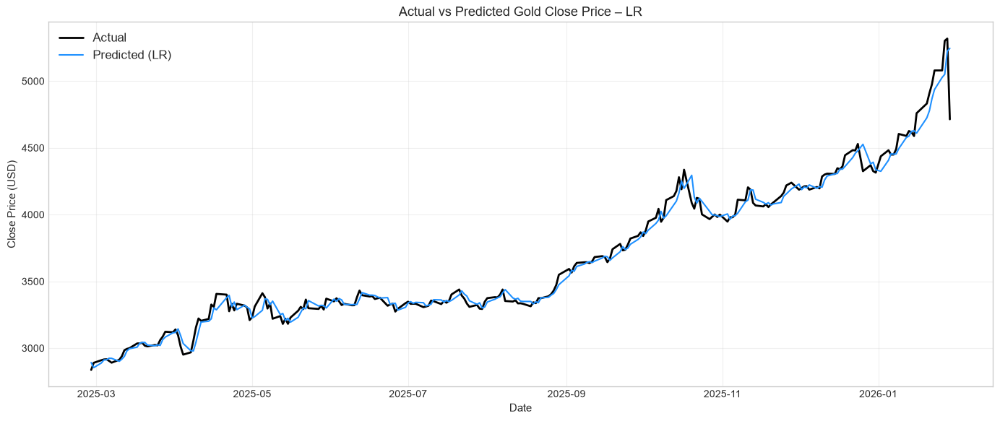

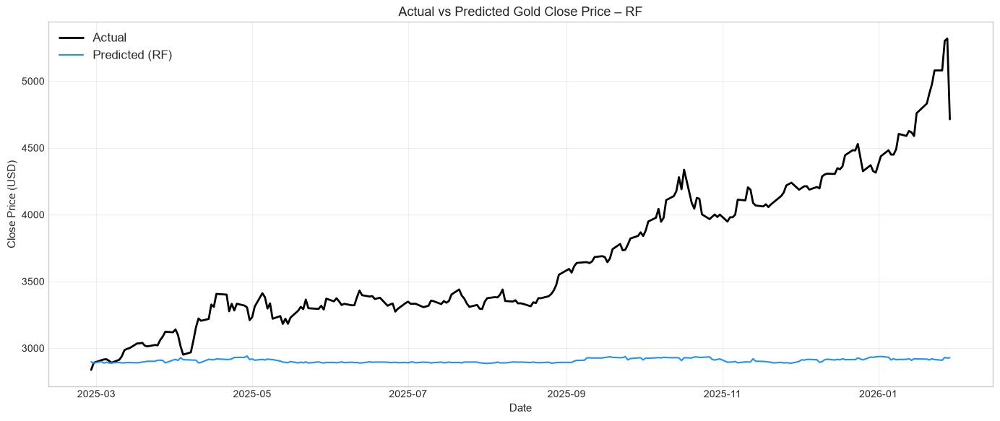

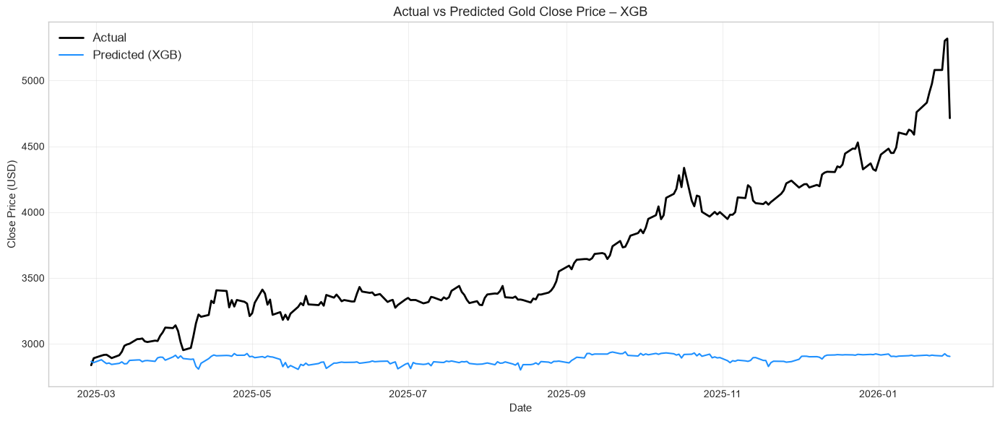

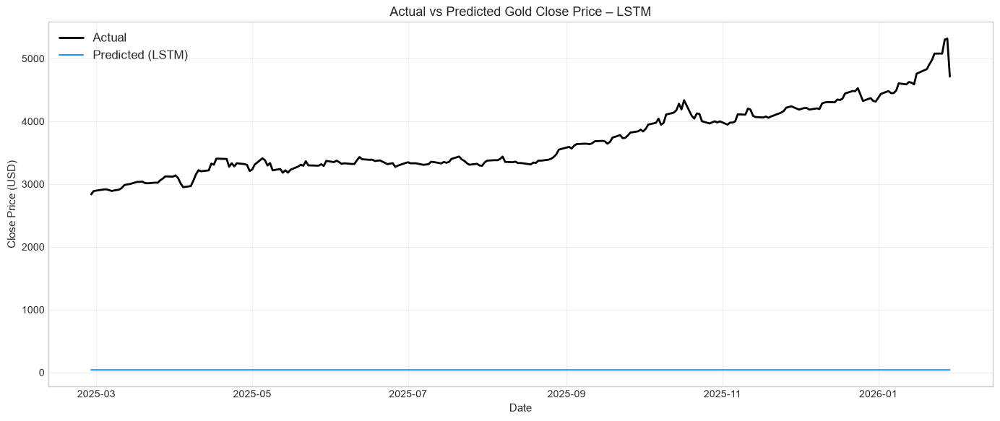


C. Residual Plots (Predicted vs Residuals)


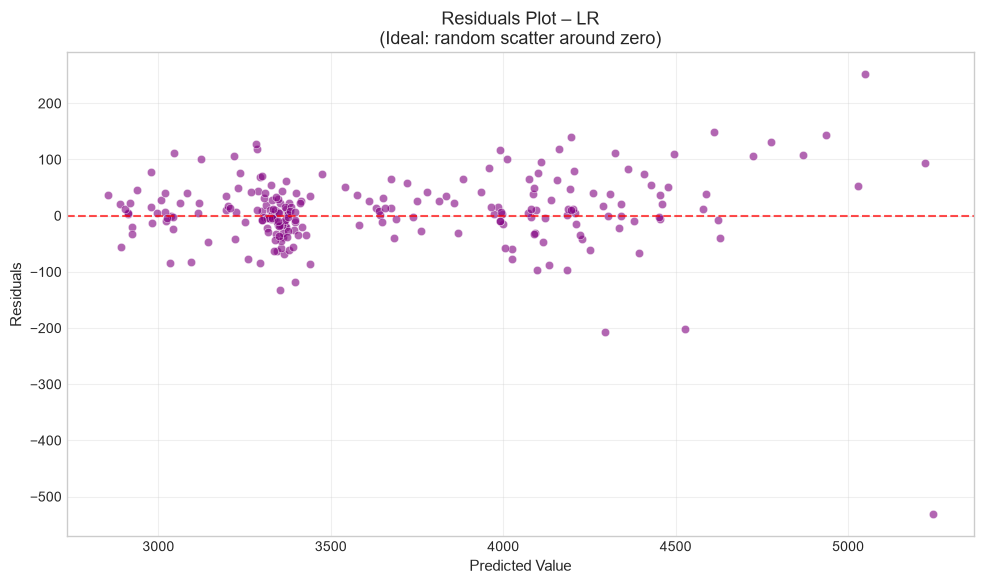

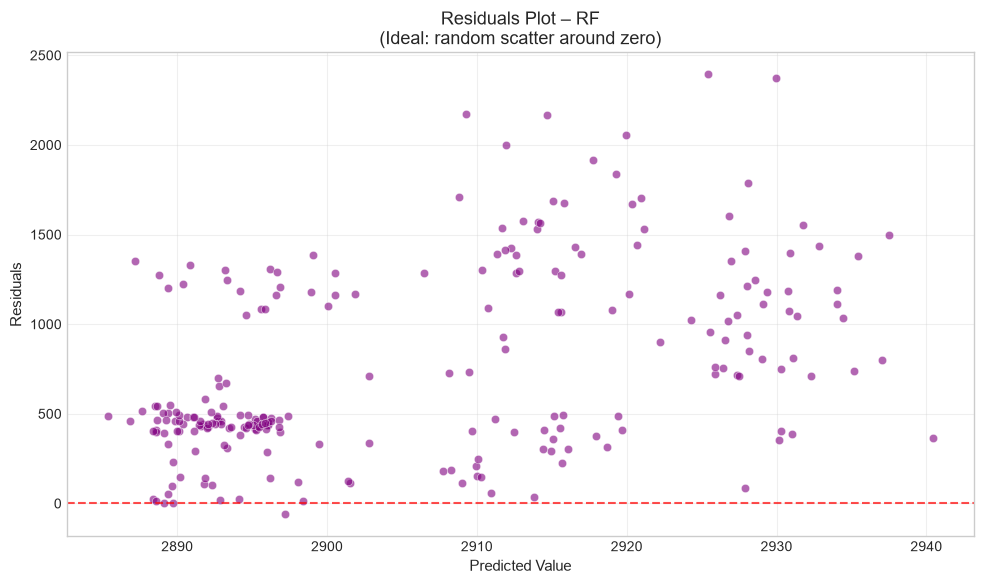

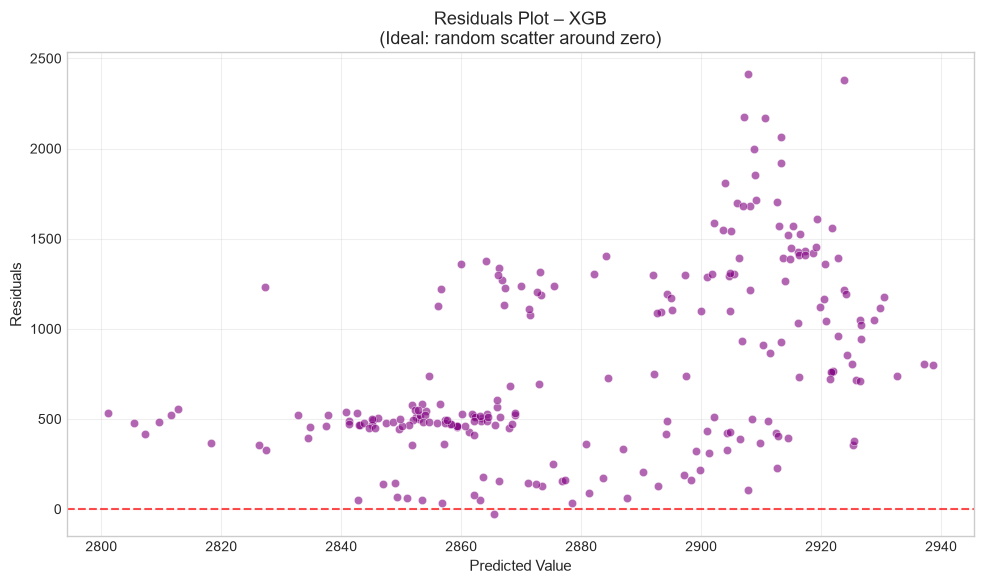

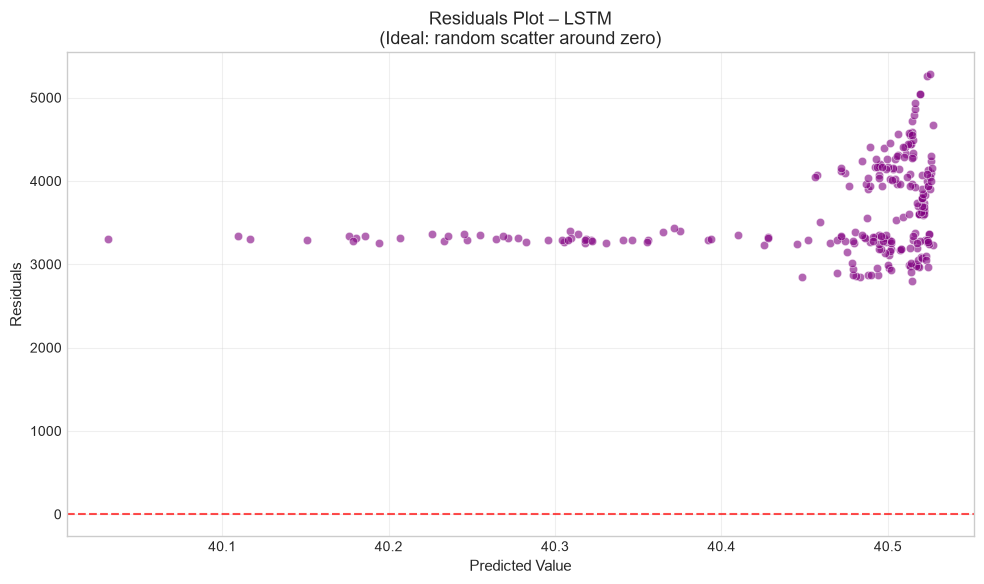


D. Feature Importance Plots


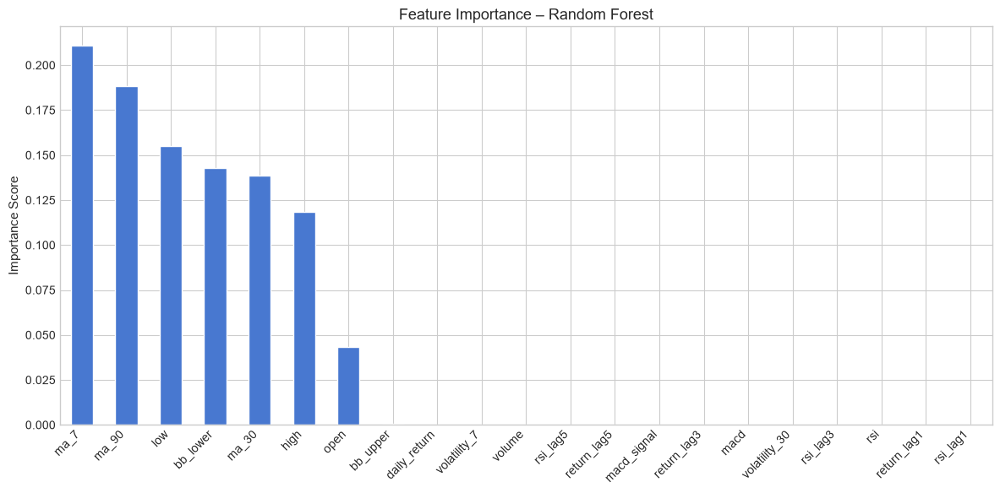

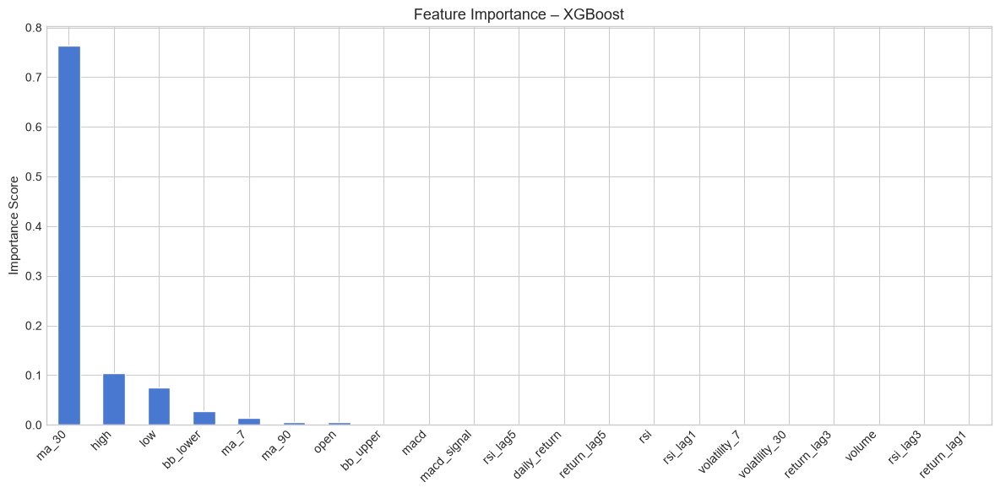


E. Prediction Error Distributions


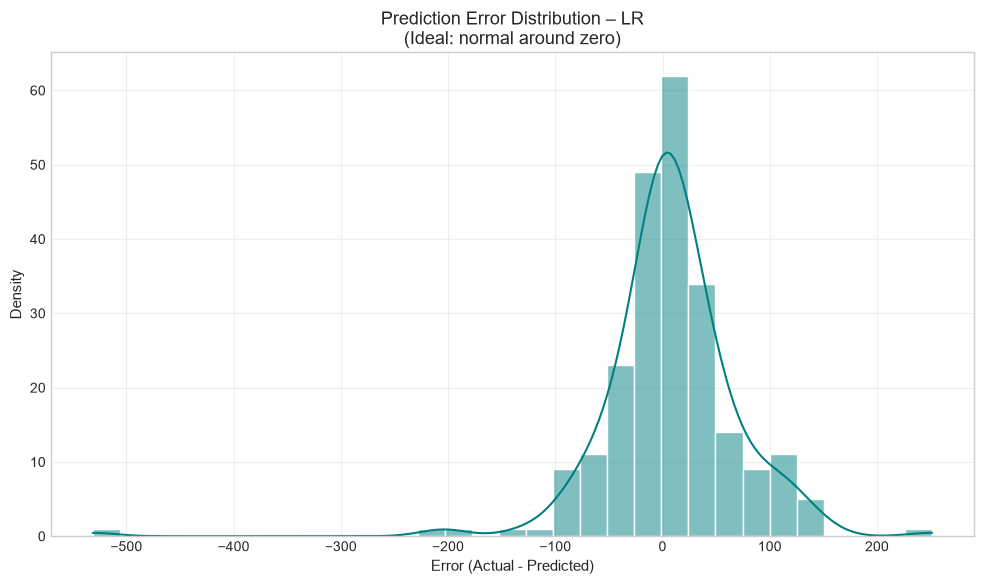

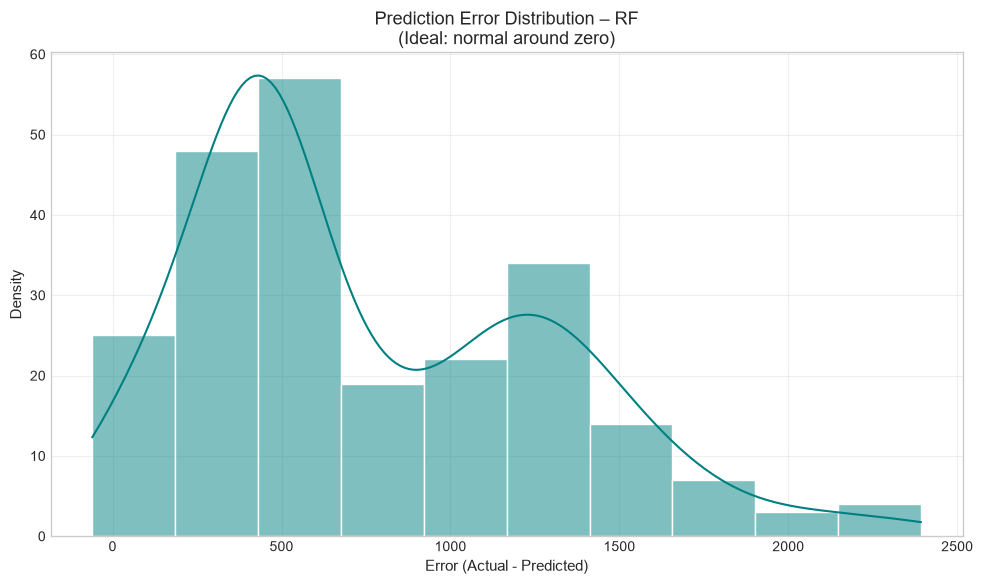

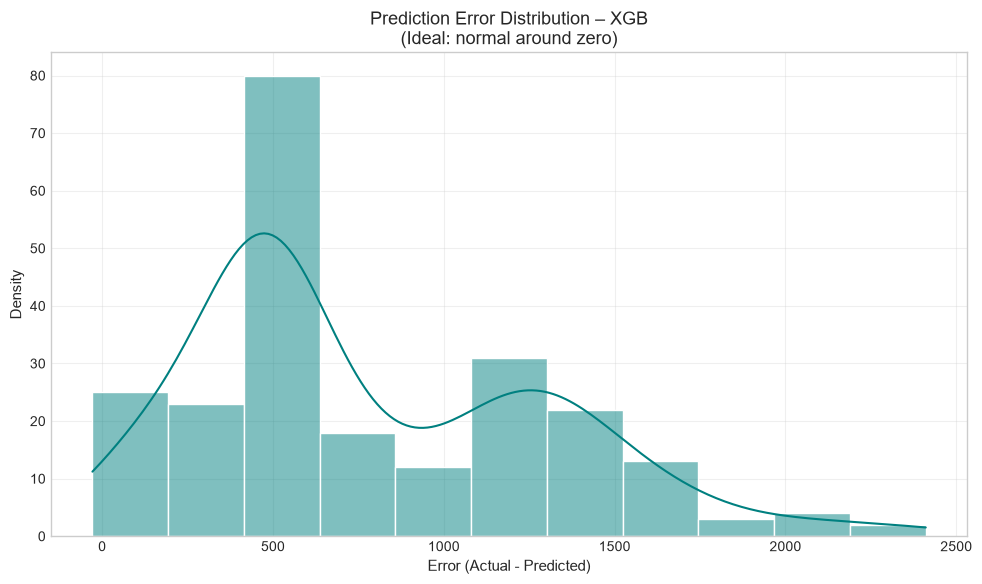

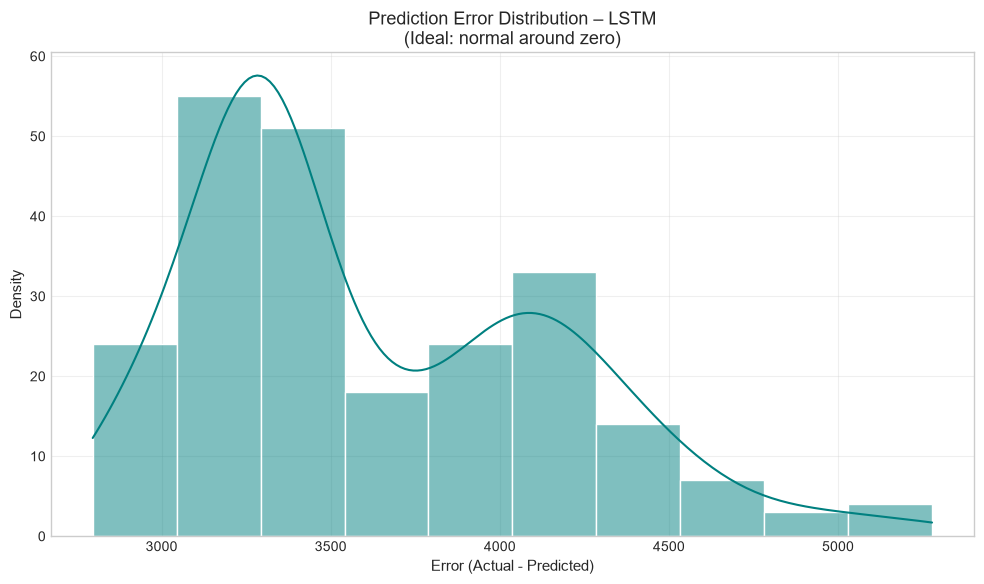

In [20]:
# =============================================================================
#    IMPORTANT ML MODELS for Gold Price Forecasting
#    - Target: Next-day 'close' price (regression task)
#    - Models: Linear Regression, Random Forest, XGBoost, LSTM
#    - Evaluation: MAE, RMSE, R2
#    - Plots: Model comparison bar, Actual vs Predicted lines, Residuals, Feature Importance
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ─── Styling ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# ─── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# ─── Feature Engineering ────────────────────────────────────────────────────
# Target: next-day close price
df['target'] = df['close'].shift(-1)

# Lags for returns and RSI (common in time-series)
for lag in [1, 3, 5]:
    df[f'return_lag{lag}'] = df['daily_return'].shift(lag)
    df[f'rsi_lag{lag}'] = df['rsi'].shift(lag)

# Drop last row (NaN target) and any NaN from lags
df = df.dropna()

# Features list (exclude target & close to avoid leakage)
features = [
    'high', 'low', 'open', 'volume', 'ma_7', 'ma_30', 'ma_90',
    'daily_return', 'volatility_7', 'volatility_30',
    'rsi', 'macd', 'macd_signal', 'bb_upper', 'bb_lower',
    'return_lag1', 'return_lag3', 'return_lag5',
    'rsi_lag1', 'rsi_lag3', 'rsi_lag5'
]

X = df[features]
y = df['target']

# ─── Train-Test Split (time-series: 80% train, 20% test chronological) ──────
split = int(0.8 * len(df))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ─── Function to evaluate & collect metrics ─────────────────────────────────
def evaluate_model(model, name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")
    
    return y_pred, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# ─── Models ─────────────────────────────────────────────────────────────────
models = {}
results = {}
y_preds = {}

# 1. Linear Regression (basic benchmark)
lr = LinearRegression()
y_preds['LR'], results['LR'] = evaluate_model(lr, 'Linear Regression', X_train_scaled, y_train, X_test_scaled, y_test)

# 2. Random Forest (ensemble tree-based)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
y_preds['RF'], results['RF'] = evaluate_model(rf, 'Random Forest', X_train_scaled, y_train, X_test_scaled, y_test)

# 3. XGBoost (advanced boosting)
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
y_preds['XGB'], results['XGB'] = evaluate_model(xgb_model, 'XGBoost', X_train_scaled, y_train, X_test_scaled, y_test)

# 4. LSTM (advanced neural net for time-series)
# Reshape for LSTM: [samples, time_steps=1, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm = Sequential([
    LSTM(64, input_shape=(1, X_train_scaled.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=0)

y_preds['LSTM'] = lstm.predict(X_test_lstm).flatten()
mae = mean_absolute_error(y_test, y_preds['LSTM'])
rmse = np.sqrt(mean_squared_error(y_test, y_preds['LSTM']))
r2 = r2_score(y_test, y_preds['LSTM'])
results['LSTM'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"LSTM - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# ─── A. Model Accuracy Comparison Bar Plot ──────────────────────────────────
print("\nA. Model Comparison Plot")

metrics_df = pd.DataFrame(results).T
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Performance Comparison (Lower MAE/RMSE better, Higher R2 better)")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ─── B. Actual vs Predicted Plots (for each model) ───────────────────────────
print("\nB. Actual vs Predicted Line Plots")

test_dates = df.iloc[split:].index

for model_name, y_pred in y_preds.items():
    plt.figure(figsize=(14, 6))
    plt.plot(test_dates, y_test, label='Actual', color='black', lw=2)
    plt.plot(test_dates, y_pred, label=f'Predicted ({model_name})', color='dodgerblue', lw=1.5)
    plt.title(f"Actual vs Predicted Gold Close Price – {model_name}")
    plt.xlabel("Date")
    plt.ylabel("Close Price (USD)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ─── C. Residual Plots (for each model) ─────────────────────────────────────
print("\nC. Residual Plots (Predicted vs Residuals)")

for model_name, y_pred in y_preds.items():
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='purple')
    plt.axhline(0, color='red', ls='--', alpha=0.7)
    plt.title(f"Residuals Plot – {model_name}\n(Ideal: random scatter around zero)")
    plt.xlabel("Predicted Value")
    plt.ylabel("Residuals")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ─── D. Feature Importance Plots (for tree-based models) ─────────────────────
print("\nD. Feature Importance Plots")

# Random Forest
importances_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
importances_rf.plot(kind='bar')
plt.title("Feature Importance – Random Forest")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# XGBoost
importances_xgb = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
importances_xgb.plot(kind='bar')
plt.title("Feature Importance – XGBoost")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ─── E. Prediction Error Distribution (histograms for each model) ───────────
print("\nE. Prediction Error Distributions")

for model_name, y_pred in y_preds.items():
    errors = y_test - y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True, color='teal')
    plt.title(f"Prediction Error Distribution – {model_name}\n(Ideal: normal around zero)")
    plt.xlabel("Error (Actual - Predicted)")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Model trained. Now generating explainability plots...

1. SHAP Summary Plot (global feature importance + direction)


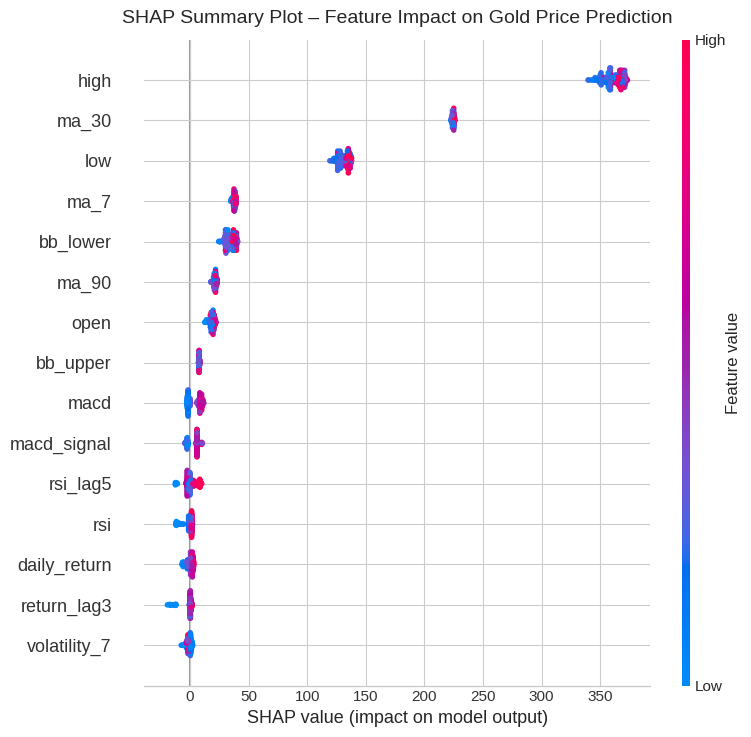

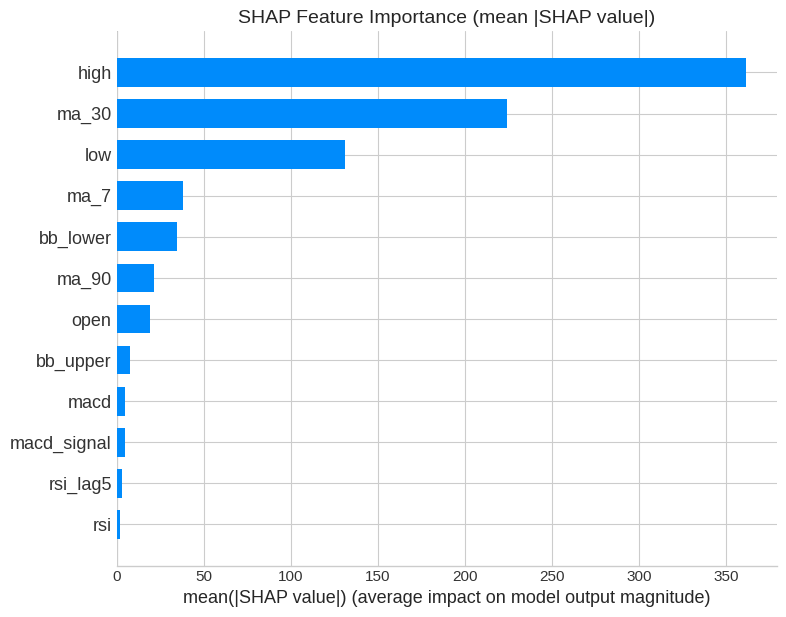


2. SHAP Waterfall – explaining one individual prediction
Showing explanation for test sample index = 42


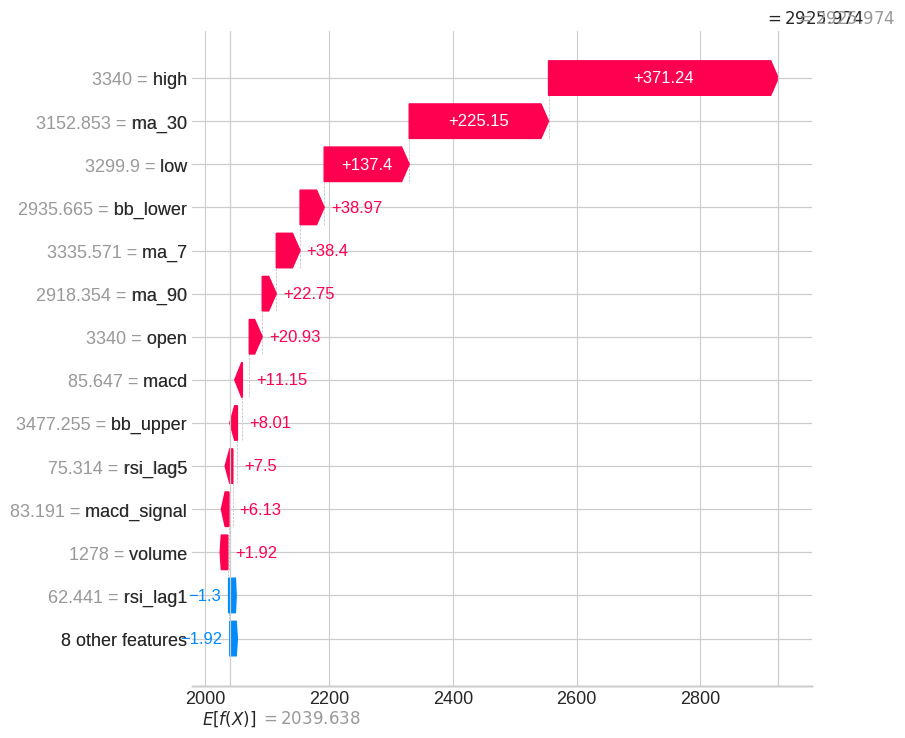

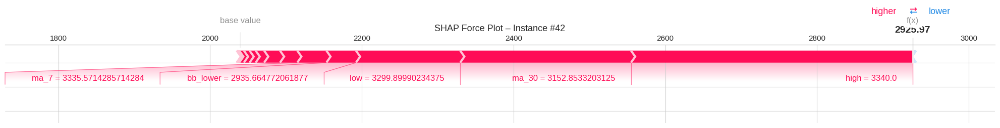


3. SHAP Dependence Plots – selected important features


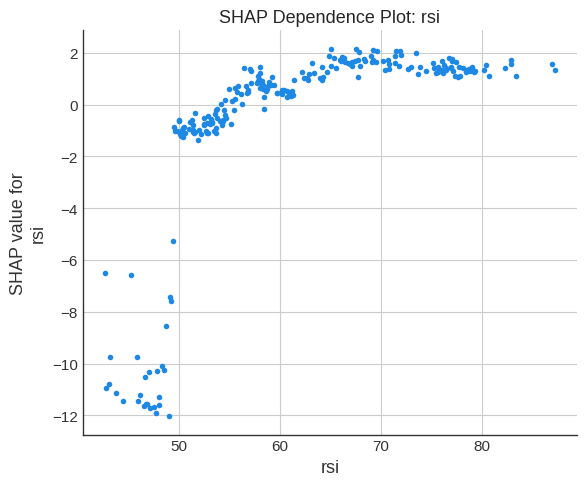

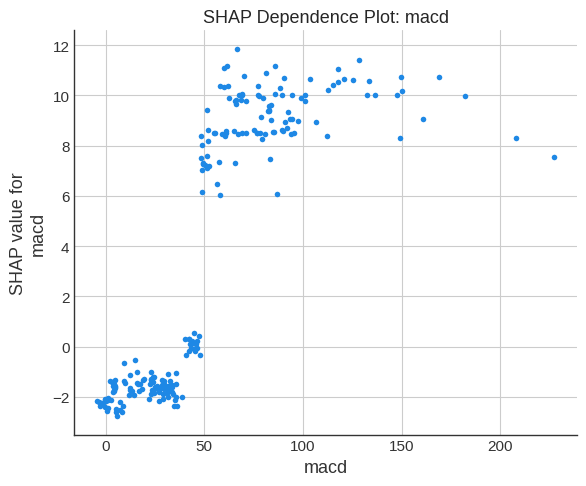

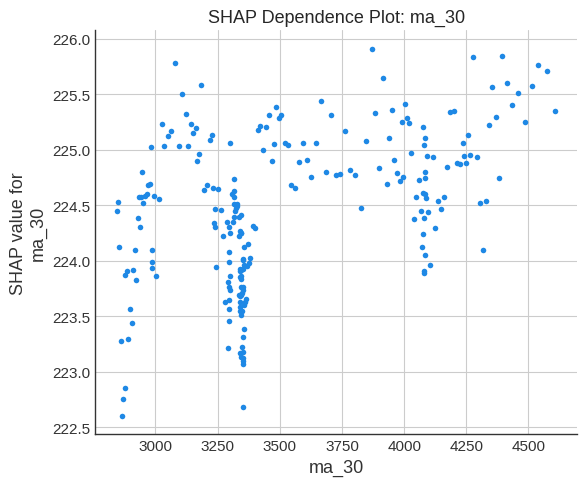

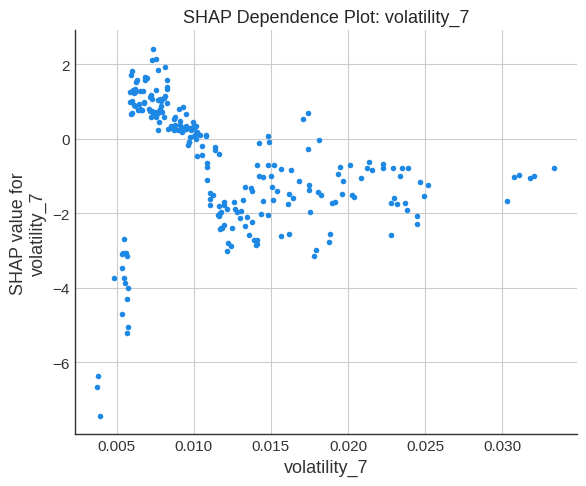

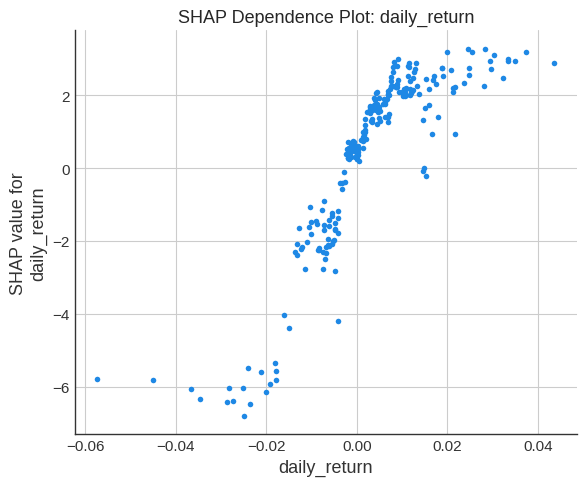


4. LIME – Explaining individual predictions

LIME explanation for test instance #42 (true value = 3305.00)


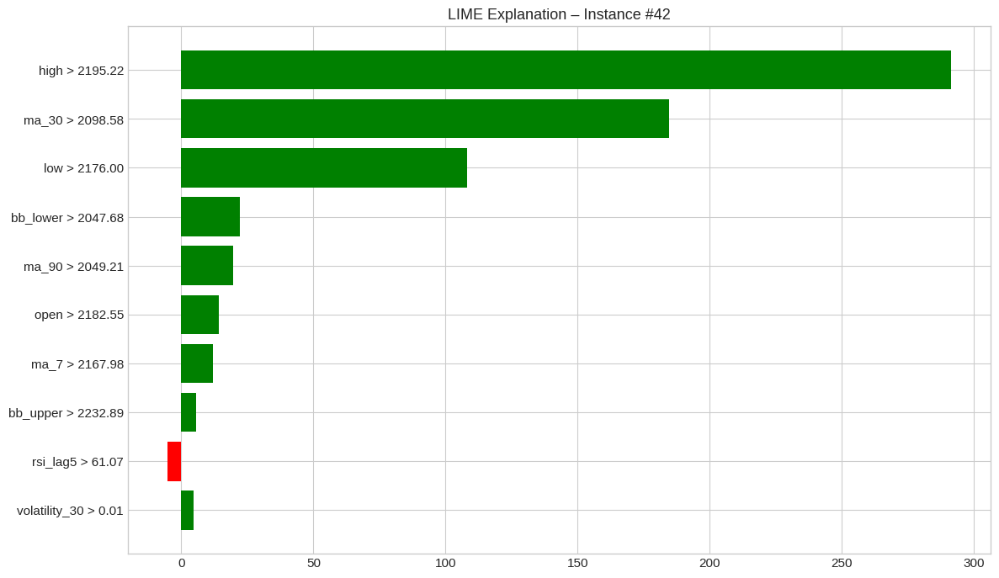


5. SHAP vs LIME top contributors – same instance


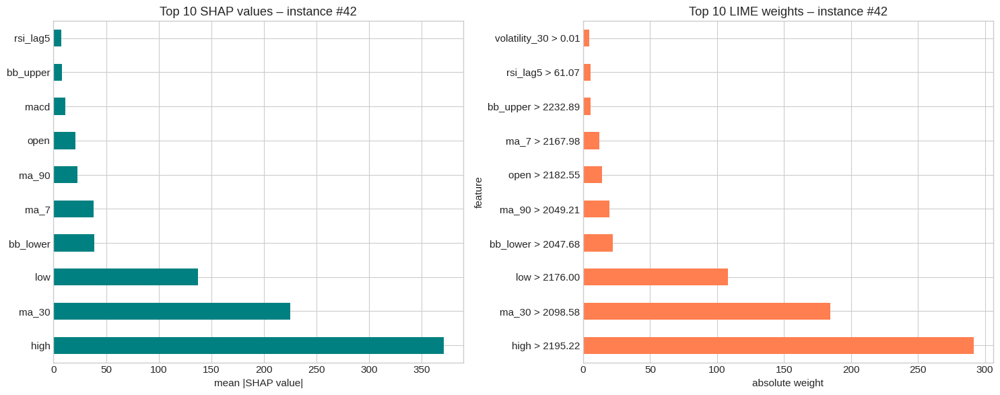

In [ ]:
# =============================================================================
#          SHAP + LIME – Model Explainability for Gold Price Prediction
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import lime
import lime.lime_tabular

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ─── Styling ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv")

# Example model – use your best one (RF or XGBoost usually works well with SHAP/LIME)
model = XGBRegressor(n_estimators=120, max_depth=5, learning_rate=0.07, random_state=42)

model.fit(X_train, y_train)

print("Model trained. Now generating explainability plots...\n")

# ─── 1. SHAP – Global importance (summary plot) ─────────────────────────────
print("1. SHAP Summary Plot (global feature importance + direction)")

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Classic beeswarm / summary plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP Summary Plot – Feature Impact on Gold Price Prediction", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Bar version (mean absolute SHAP value)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=12,
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP value|)", fontsize=14)
plt.tight_layout()
plt.show()


# ─── 2. SHAP – Waterfall plot for a single prediction (local explanation) ───
print("\n2. SHAP Waterfall – explaining one individual prediction")

# Choose interesting examples:
# a) a high prediction
# b) a low prediction
# c) a median case

sample_idx = 42          # ← change this index to see different cases
print(f"Showing explanation for test sample index = {sample_idx}")

shap.plots.waterfall(shap_values[sample_idx], max_display=14)

# Alternative: force plot (interactive in Jupyter, static image otherwise)
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx].values,
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=False,
    link="identity"
)
plt.title(f"SHAP Force Plot – Instance #{sample_idx}", fontsize=13)
plt.tight_layout()
plt.show()


# ─── 3. SHAP – Dependence plots (how one feature affects prediction) ────────
print("\n3. SHAP Dependence Plots – selected important features")

important_features = ['rsi', 'macd', 'ma_30', 'volatility_7', 'daily_return']

for feat in important_features:
    if feat in X_test.columns:
        shap.dependence_plot(
            feat,
            shap_values.values,
            X_test,
            interaction_index=None,   # or 'auto' to show strongest interaction
            show=False
        )
        plt.title(f"SHAP Dependence Plot: {feat}", fontsize=13)
        plt.tight_layout()
        plt.show()


# ─── 4. LIME – Local explanation for individual predictions ─────────────────
print("\n4. LIME – Explaining individual predictions")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode="regression",
    discretize_continuous=True
)

# Pick the same interesting sample
i = sample_idx

exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=model.predict,
    num_features=10
)

print(f"\nLIME explanation for test instance #{i} (true value = {y_test.iloc[i]:.2f})")
exp.show_in_notebook(show_table=True, show_all=False)   # Jupyter only

# Static plot version (matplotlib)
fig = exp.as_pyplot_figure()
plt.title(f"LIME Explanation – Instance #{i}", fontsize=13)
plt.tight_layout()
plt.show()


# ─── 5. Comparison: SHAP vs LIME top features for the same instance ─────────
print("\n5. SHAP vs LIME top contributors – same instance")

shap_top = pd.Series(shap_values[sample_idx].values, index=X_test.columns).abs().nlargest(10)
lime_top = pd.DataFrame(exp.as_list(), columns=['feature','weight']).set_index('feature')['weight'].abs().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

shap_top.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title(f"Top 10 SHAP values – instance #{sample_idx}")
axes[0].set_xlabel("mean |SHAP value|")

lime_top.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title(f"Top 10 LIME weights – instance #{sample_idx}")
axes[1].set_xlabel("absolute weight")

plt.tight_layout()
plt.show()

A. Actual vs Predictions – All Ensemble Variants


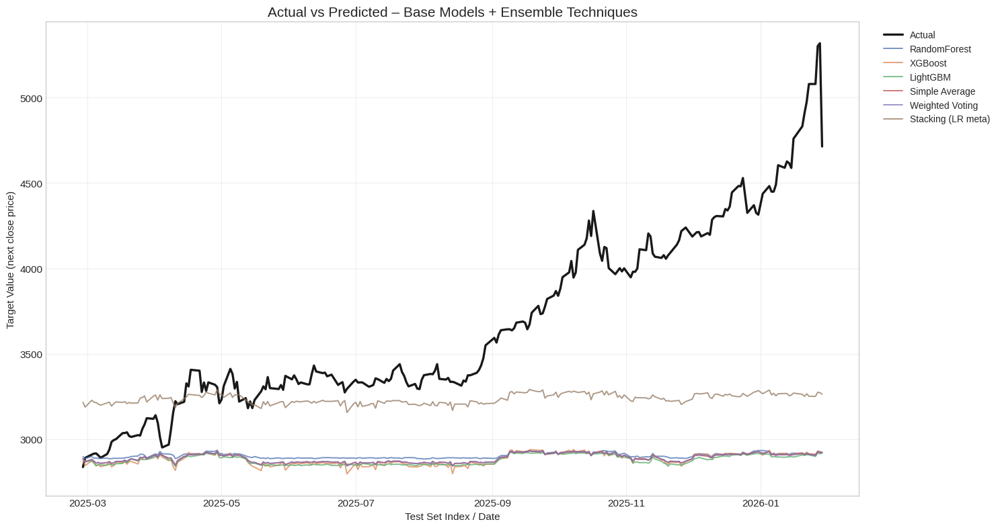


B. Pairwise Prediction Differences Heatmap


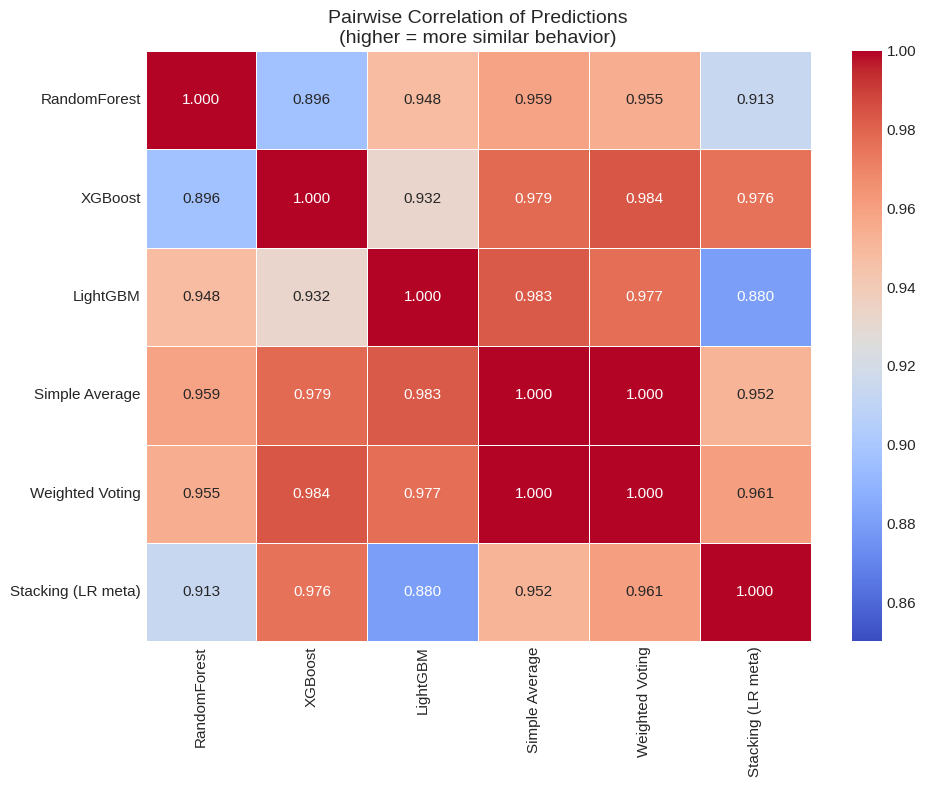


C. Residual Plots for Ensembles


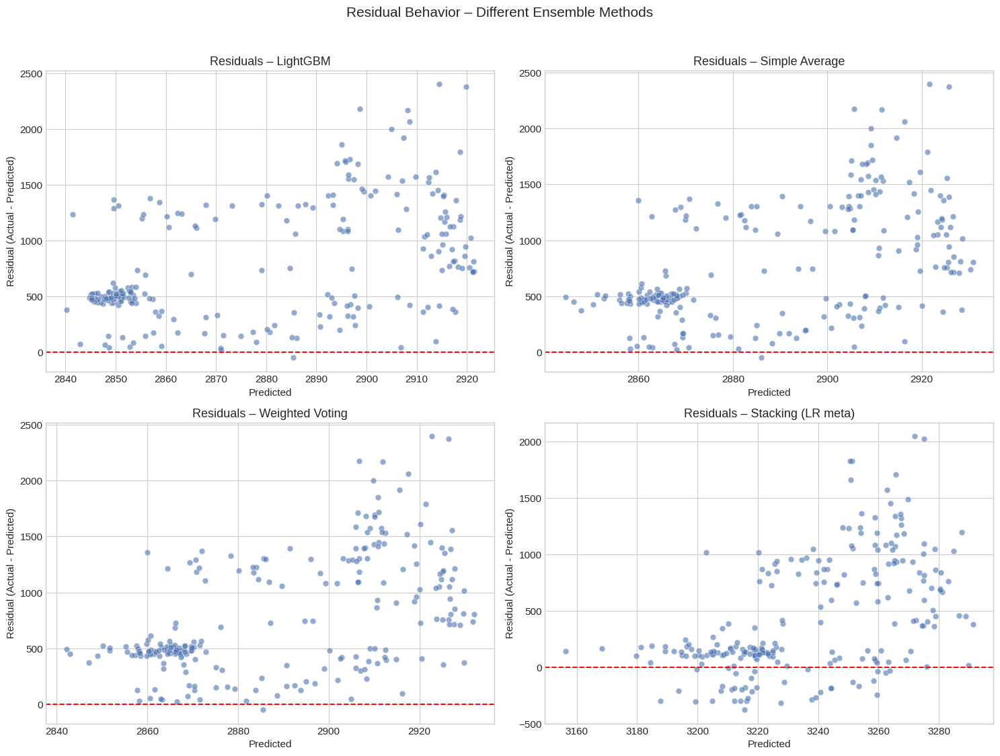


D. Cumulative Absolute Error over Test Set


<Figure size 1400x700 with 0 Axes>

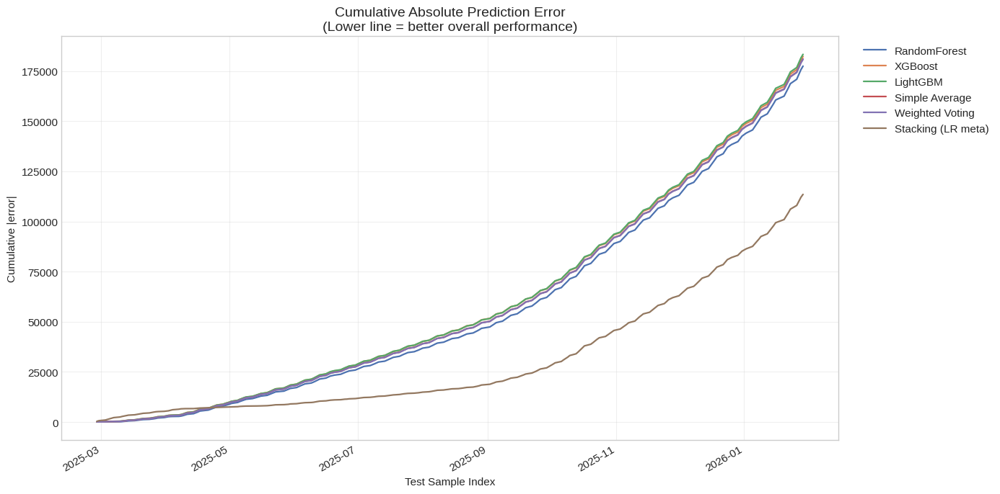


E. Prediction Error Distribution – All Methods


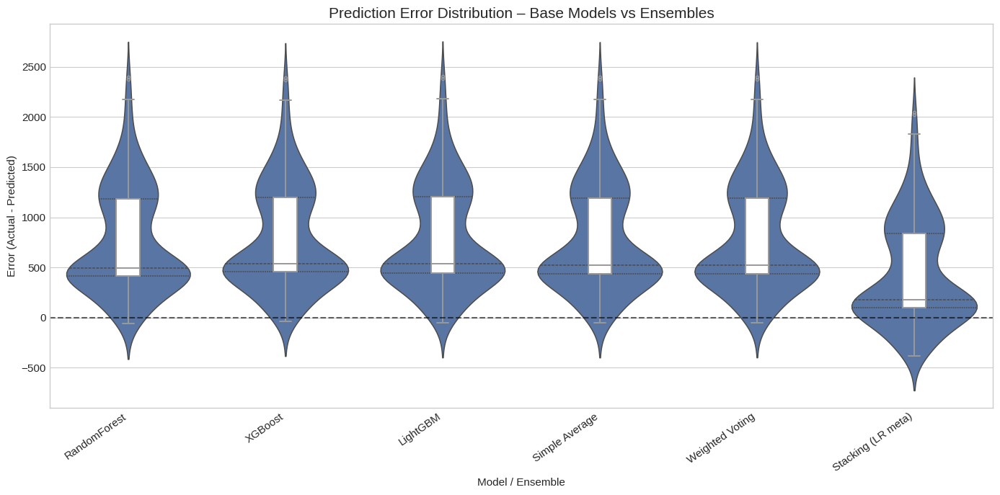

In [ ]:
# =============================================================================
#         IMPORTANT ENSEMBLE VISUALIZATION TECHNIQUES
#         Gold Price Prediction / Time Series Regression
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

# ─── Styling ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv", parse_dates=['date'], index_col='date')

# ─── Define base models ─────────────────────────────────────────────────────
base_models = [
    ('rf', RandomForestRegressor(n_estimators=120, max_depth=7, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42)),
    ('lgb', LGBMRegressor(n_estimators=140, max_depth=6, learning_rate=0.07, random_state=42, verbose=-1))
]

# ─── Fit individual models + get predictions ────────────────────────────────
individual_preds = {}
for name, model in base_models:
    model.fit(X_train, y_train)
    individual_preds[name] = model.predict(X_test)

# ─── 1. Simple Averaging Ensemble ───────────────────────────────────────────
avg_pred = np.mean([individual_preds[name] for name in individual_preds], axis=0)

# ─── 2. Weighted Averaging (VotingRegressor) ────────────────────────────────
voting = VotingRegressor(estimators=base_models, weights=[0.35, 0.40, 0.25])
voting.fit(X_train, y_train)
voting_pred = voting.predict(X_test)

# ─── 3. Stacking Ensemble ───────────────────────────────────────────────────
stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train, y_train)
stacking_pred = stacking.predict(X_test)

# ─── Collect all predictions ────────────────────────────────────────────────
all_preds = {
    'RandomForest': individual_preds['rf'],
    'XGBoost': individual_preds['xgb'],
    'LightGBM': individual_preds['lgb'],
    'Simple Average': avg_pred,
    'Weighted Voting': voting_pred,
    'Stacking (LR meta)': stacking_pred
}

# ─── A. Actual vs All Ensemble Predictions ──────────────────────────────────
print("A. Actual vs Predictions – All Ensemble Variants")

test_dates = X_test.index if hasattr(X_test, 'index') else range(len(X_test))

plt.figure(figsize=(15, 8))
plt.plot(test_dates, y_test, label='Actual', color='black', linewidth=2.4, alpha=0.9)

for name, pred in all_preds.items():
    plt.plot(test_dates, pred, label=name, linewidth=1.4, alpha=0.75)

plt.title("Actual vs Predicted – Base Models + Ensemble Techniques", fontsize=15)
plt.xlabel("Test Set Index / Date")
plt.ylabel("Target Value (next close price)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ─── B. Prediction Difference Heatmap (pairwise disagreement) ───────────────
print("\nB. Pairwise Prediction Differences Heatmap")

pred_df = pd.DataFrame(all_preds)
diff_matrix = pred_df.corr().round(4)

plt.figure(figsize=(10, 8))
sns.heatmap(diff_matrix, annot=True, cmap='coolwarm', vmin=0.85, vmax=1.0,
            fmt='.3f', linewidths=0.5, annot_kws={"size":11})
plt.title("Pairwise Correlation of Predictions\n(higher = more similar behavior)", fontsize=14)
plt.tight_layout()
plt.show()


# ─── C. Residual Plots – Comparing Ensembles ────────────────────────────────
print("\nC. Residual Plots for Ensembles")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.ravel()

for i, (name, pred) in enumerate(list(all_preds.items())[2:]):  # show only ensembles
    residuals = y_test - pred
    sns.scatterplot(x=pred, y=residuals, ax=axes[i], alpha=0.6, s=40)
    axes[i].axhline(0, color='red', ls='--', lw=1.4)
    axes[i].set_title(f"Residuals – {name}", fontsize=13)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Residual (Actual - Predicted)")

plt.suptitle("Residual Behavior – Different Ensemble Methods", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


# ─── D. Cumulative Error Comparison ─────────────────────────────────────────
print("\nD. Cumulative Absolute Error over Test Set")

cum_errors = {}
for name, pred in all_preds.items():
    cum_errors[name] = np.cumsum(np.abs(y_test - pred))

cum_df = pd.DataFrame(cum_errors)

plt.figure(figsize=(14, 7))
cum_df.plot(linewidth=1.6)
plt.title("Cumulative Absolute Prediction Error\n(Lower line = better overall performance)", fontsize=14)
plt.xlabel("Test Sample Index")
plt.ylabel("Cumulative |error|")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ─── E. Error Distribution Comparison (violin + box) ────────────────────────
print("\nE. Prediction Error Distribution – All Methods")

errors_df = pd.DataFrame({name: y_test - pred for name, pred in all_preds.items()})

plt.figure(figsize=(14, 7))
sns.violinplot(data=errors_df.melt(), x='variable', y='value', inner='quartile', linewidth=1.1)
sns.boxplot(data=errors_df.melt(), x='variable', y='value', width=0.15, fliersize=3, color='white', linewidth=1.4)
plt.axhline(0, color='black', ls='--', alpha=0.6)
plt.title("Prediction Error Distribution – Base Models vs Ensembles", fontsize=15)
plt.xlabel("Model / Ensemble")
plt.ylabel("Error (Actual - Predicted)")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

Data prepared. Shape: (1167, 23)
Statistical anomalies → Z-score: 9, IQR: 81
ML anomalies detected.


14:58:53 - cmdstanpy - INFO - Chain [1] start processing
14:58:54 - cmdstanpy - INFO - Chain [1] done processing
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Advanced methods completed.

Plot 1: Gold Price with All Detected Anomalies


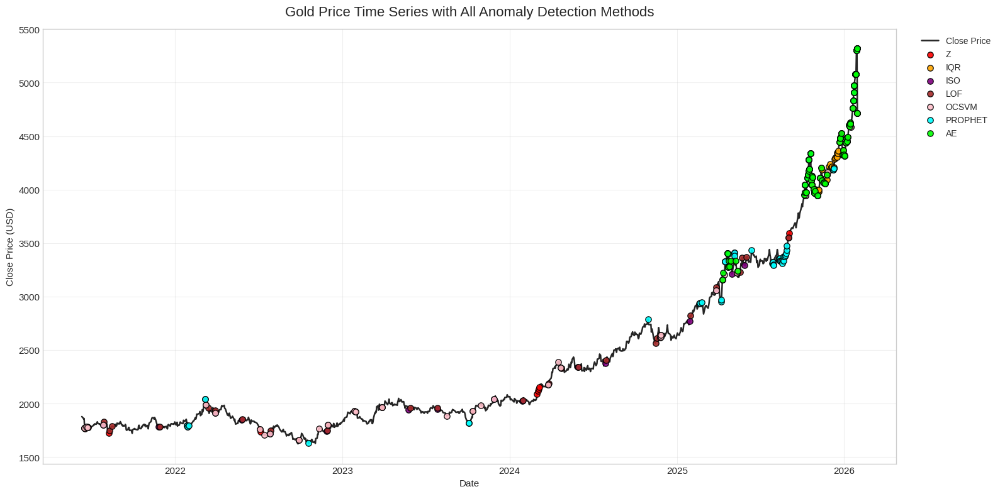


Plot 2: Comparison of Anomaly Counts


/tmp/ipykernel_55/3362677895.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_df.values, y=counts_df.index, palette='viridis')


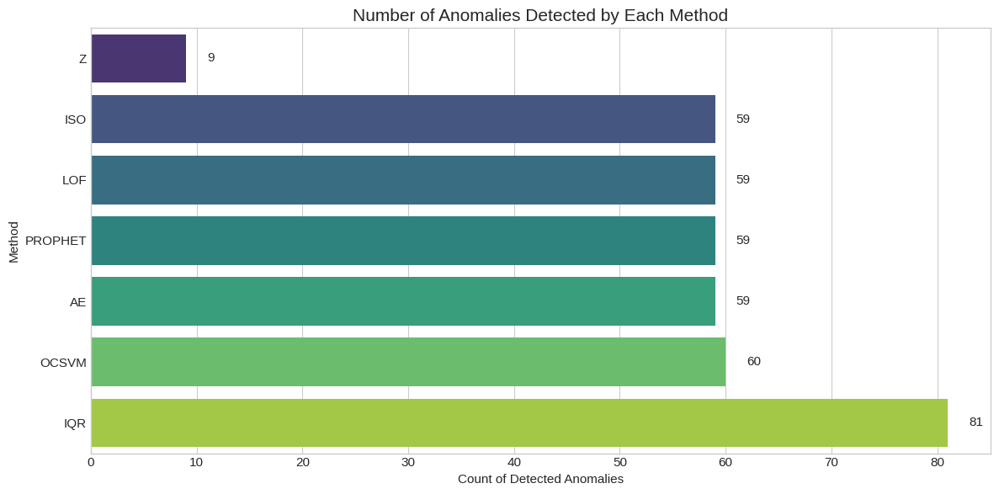


Plot 3: LSTM Autoencoder Reconstruction Error


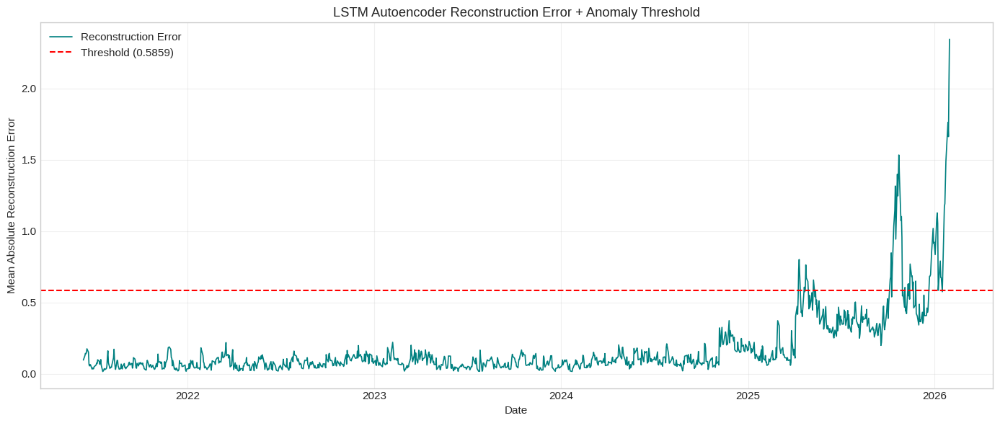


Plot 4: Anomalies in 2D Feature Space (RSI vs Volatility)


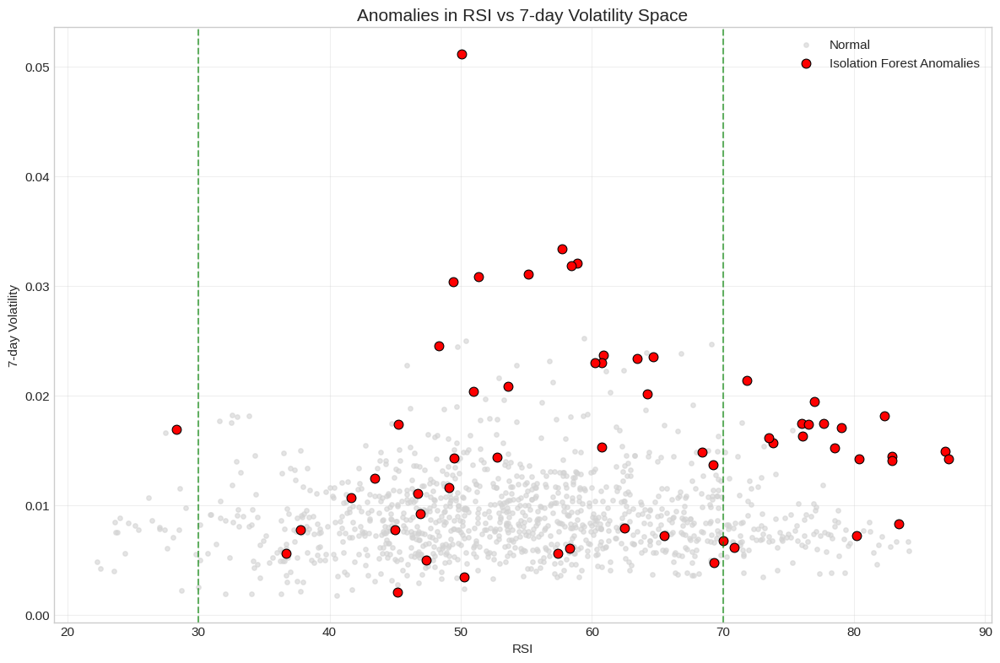


Plot 5: Overlap Matrix – How Many Methods Agree on Anomalies


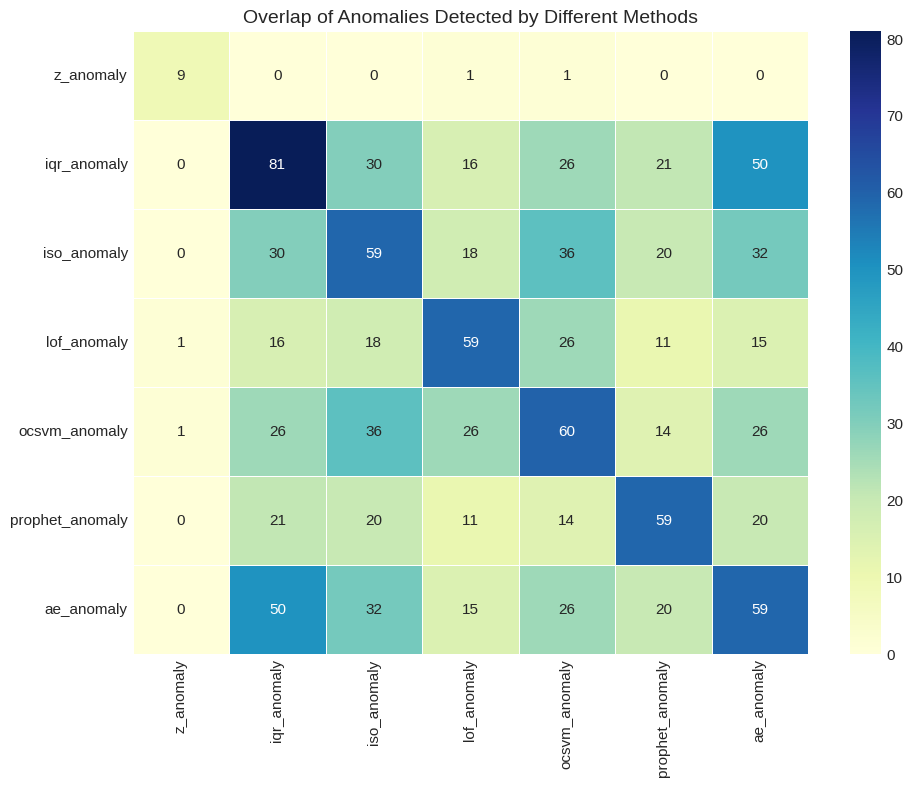


✅ All important anomaly detection plots generated successfully!


In [ ]:
# =============================================================================
#          ALL IMPORTANT ANOMALY DETECTION TECHNIQUES + PLOTS
#          Gold Price Forecasting Dataset
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

# Scikit-learn & advanced methods
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

# Advanced time-series specific
import statsmodels.api as sm
from prophet import Prophet

# For LSTM Autoencoder (advanced)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 7)

# =============================================================================
# 1. Load & Prepare Data
# =============================================================================
df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

# Create useful features for anomaly detection
df['return'] = df['daily_return']
df['vol_7'] = df['volatility_7']
df['vol_30'] = df['volatility_30']
df['rsi'] = df['rsi']
df['macd'] = df['macd']
df['volume'] = df['volume']

# Rolling statistics for statistical methods
df['rolling_mean'] = df['close'].rolling(window=30).mean()
df['rolling_std']  = df['close'].rolling(window=30).std()
df['z_score'] = (df['close'] - df['rolling_mean']) / df['rolling_std']

print("Data prepared. Shape:", df.shape)

# =============================================================================
# 2. Statistical Anomaly Detection (Z-score & IQR)
# =============================================================================
df['z_anomaly'] = np.abs(df['z_score']) > 3
df['iqr_anomaly'] = False

Q1 = df['close'].quantile(0.25)
Q3 = df['close'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df.loc[(df['close'] < lower) | (df['close'] > upper), 'iqr_anomaly'] = True

print(f"Statistical anomalies → Z-score: {df['z_anomaly'].sum()}, IQR: {df['iqr_anomaly'].sum()}")

# =============================================================================
# 3. ML-based Anomaly Detection
# =============================================================================
features = ['close', 'return', 'vol_7', 'rsi', 'macd', 'volume']
X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3.1 Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df.loc[X.index, 'iso_anomaly'] = iso.fit_predict(X_scaled) == -1

# 3.2 Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df.loc[X.index, 'lof_anomaly'] = lof.fit_predict(X_scaled) == -1

# 3.3 One-Class SVM
ocsvm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
df.loc[X.index, 'ocsvm_anomaly'] = ocsvm.fit_predict(X_scaled) == -1

print("ML anomalies detected.")

# =============================================================================
# 4. Advanced Time-Series Specific Methods
# =============================================================================

# 4.1 Prophet Anomaly Detection
prophet_df = df.reset_index()[['date', 'close']].rename(columns={'date':'ds', 'close':'y'})
model_p = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_p.fit(prophet_df)
forecast = model_p.predict(prophet_df)
forecast['yhat'] = forecast['yhat']
forecast['actual'] = prophet_df['y'].values
forecast['error'] = np.abs(forecast['actual'] - forecast['yhat'])
threshold = forecast['error'].quantile(0.95)
forecast['prophet_anomaly'] = forecast['error'] > threshold
df.loc[forecast['ds'], 'prophet_anomaly'] = forecast['prophet_anomaly'].values

# 4.2 LSTM Autoencoder (Reconstruction Error)
def create_lstm_autoencoder(n_features):
    model = Sequential([
        LSTM(64, activation='relu', input_shape=(1, n_features), return_sequences=True),
        LSTM(32, activation='relu', return_sequences=False),
        RepeatVector(1),
        LSTM(32, activation='relu', return_sequences=True),
        LSTM(64, activation='relu', return_sequences=True),
        TimeDistributed(Dense(n_features))
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
autoencoder = create_lstm_autoencoder(X_lstm.shape[2])
autoencoder.fit(X_lstm, X_lstm, epochs=30, batch_size=32, validation_split=0.2, 
                callbacks=[EarlyStopping(patience=8)], verbose=0)

recon = autoencoder.predict(X_lstm)
recon_error = np.mean(np.abs(X_lstm - recon), axis=2).flatten()
threshold_ae = np.percentile(recon_error, 95)
df.loc[X.index, 'ae_anomaly'] = recon_error > threshold_ae

print("Advanced methods completed.")

# =============================================================================
# 5. ALL IMPORTANT ANOMALY DETECTION PLOTS
# =============================================================================

anomaly_columns = ['z_anomaly', 'iqr_anomaly', 'iso_anomaly', 'lof_anomaly',
                   'ocsvm_anomaly', 'prophet_anomaly', 'ae_anomaly']

# 5.1 Main Time-Series Plot with All Anomalies Highlighted
print("\nPlot 1: Gold Price with All Detected Anomalies")
plt.figure(figsize=(16, 8))
plt.plot(df.index, df['close'], label='Close Price', color='black', linewidth=1.8, alpha=0.85)

colors = ['red', 'orange', 'purple', 'brown', 'pink', 'cyan', 'lime']
for i, col in enumerate(anomaly_columns):
    anomalies = df[df[col] == True]
    if not anomalies.empty:
        plt.scatter(anomalies.index, anomalies['close'], 
                    label=col.replace('_anomaly','').upper(), 
                    color=colors[i % len(colors)], s=45, alpha=0.9, edgecolor='black', zorder=5)

plt.title("Gold Price Time Series with All Anomaly Detection Methods", fontsize=16, pad=15)
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5.2 Number of Anomalies Detected by Each Method
print("\nPlot 2: Comparison of Anomaly Counts")
counts = {col.replace('_anomaly','').upper(): df[col].sum() for col in anomaly_columns}
counts_df = pd.Series(counts).sort_values()

plt.figure(figsize=(12, 6))
sns.barplot(x=counts_df.values, y=counts_df.index, palette='viridis')
plt.title("Number of Anomalies Detected by Each Method", fontsize=15)
plt.xlabel("Count of Detected Anomalies")
plt.ylabel("Method")
for i, v in enumerate(counts_df.values):
    plt.text(v + 2, i, str(int(v)), va='center', fontsize=11)
plt.tight_layout()
plt.show()

# 5.3 Reconstruction Error (LSTM Autoencoder)
print("\nPlot 3: LSTM Autoencoder Reconstruction Error")
plt.figure(figsize=(14, 6))
plt.plot(df.index[-len(recon_error):], recon_error, label='Reconstruction Error', color='teal', linewidth=1.2)
plt.axhline(threshold_ae, color='red', linestyle='--', label=f'Threshold ({threshold_ae:.4f})')
plt.title("LSTM Autoencoder Reconstruction Error + Anomaly Threshold")
plt.xlabel("Date")
plt.ylabel("Mean Absolute Reconstruction Error")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5.4 Feature Space View of Anomalies (Isolation Forest)
print("\nPlot 4: Anomalies in 2D Feature Space (RSI vs Volatility)")
anomalies_iso = df[df['iso_anomaly'] == True]

plt.figure(figsize=(12, 8))
plt.scatter(df['rsi'], df['vol_7'], label='Normal', color='lightgray', s=15, alpha=0.6)
plt.scatter(anomalies_iso['rsi'], anomalies_iso['vol_7'], 
            label='Isolation Forest Anomalies', color='red', s=60, edgecolor='black', linewidth=0.8)
plt.title("Anomalies in RSI vs 7-day Volatility Space", fontsize=15)
plt.xlabel("RSI")
plt.ylabel("7-day Volatility")
plt.axvline(30, color='green', ls='--', alpha=0.6)
plt.axvline(70, color='green', ls='--', alpha=0.6)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5.5 Overlap of Different Methods
print("\nPlot 5: Overlap Matrix – How Many Methods Agree on Anomalies")
overlap = pd.DataFrame(index=anomaly_columns, columns=anomaly_columns)
for c1 in anomaly_columns:
    for c2 in anomaly_columns:
        overlap.loc[c1, c2] = (df[c1] & df[c2]).sum()

plt.figure(figsize=(10, 8))
sns.heatmap(overlap.astype(int), annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("Overlap of Anomalies Detected by Different Methods", fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ All important anomaly detection plots generated successfully!")

1. Q-Q plot of daily returns vs theoretical normal distribution


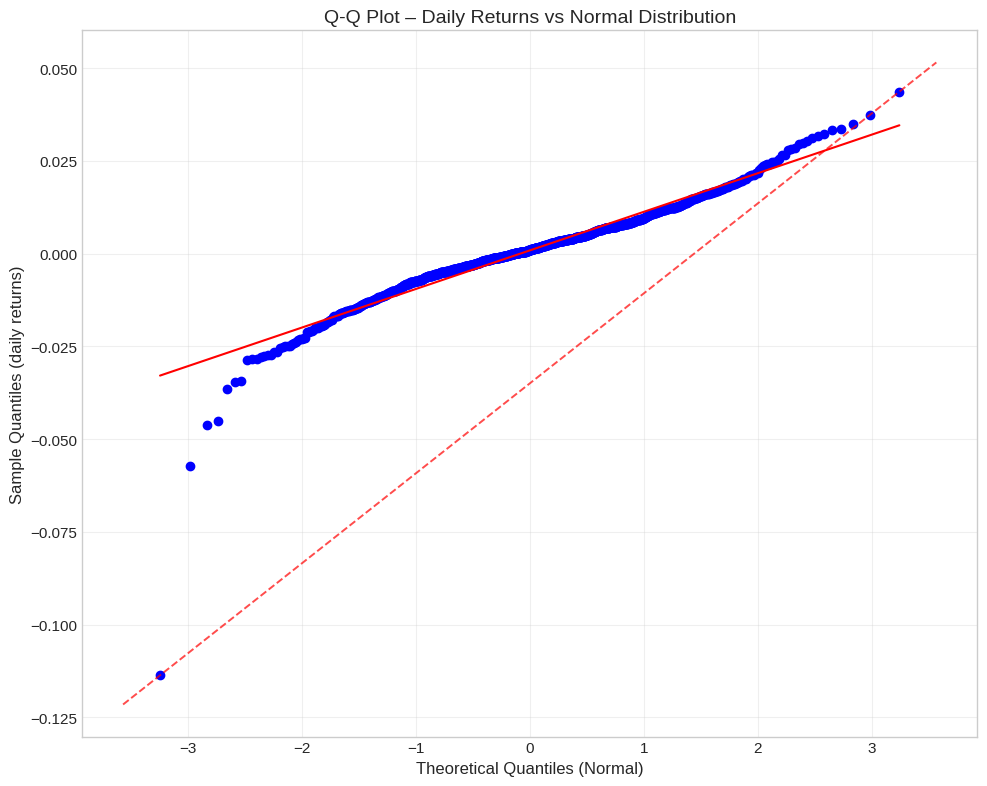

→ If points follow the red line → returns are roughly normal
→ Heavy deviation in tails → fat tails (typical in financial returns)

2. Rolling correlation – Close price vs Volume


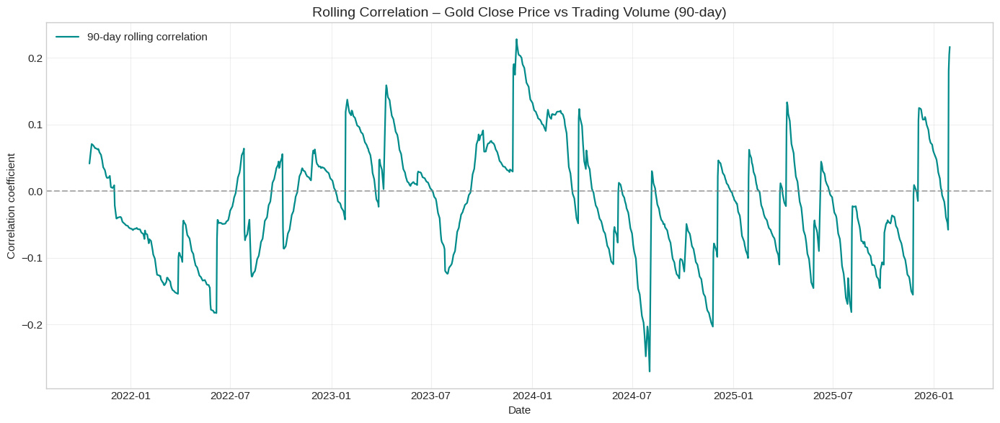


3. Hodrick-Prescott filter – trend vs cyclical component


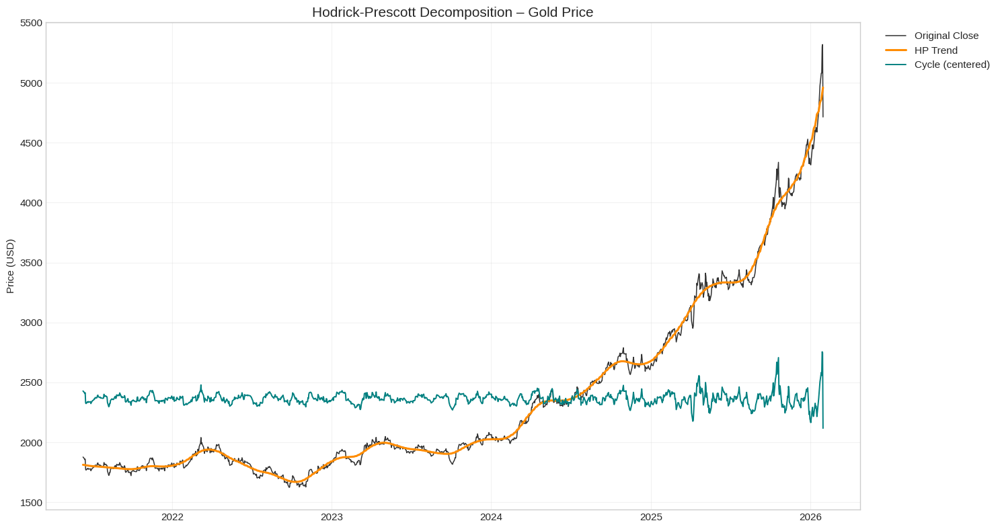


4. ACF and PACF – autocorrelation structure of daily returns


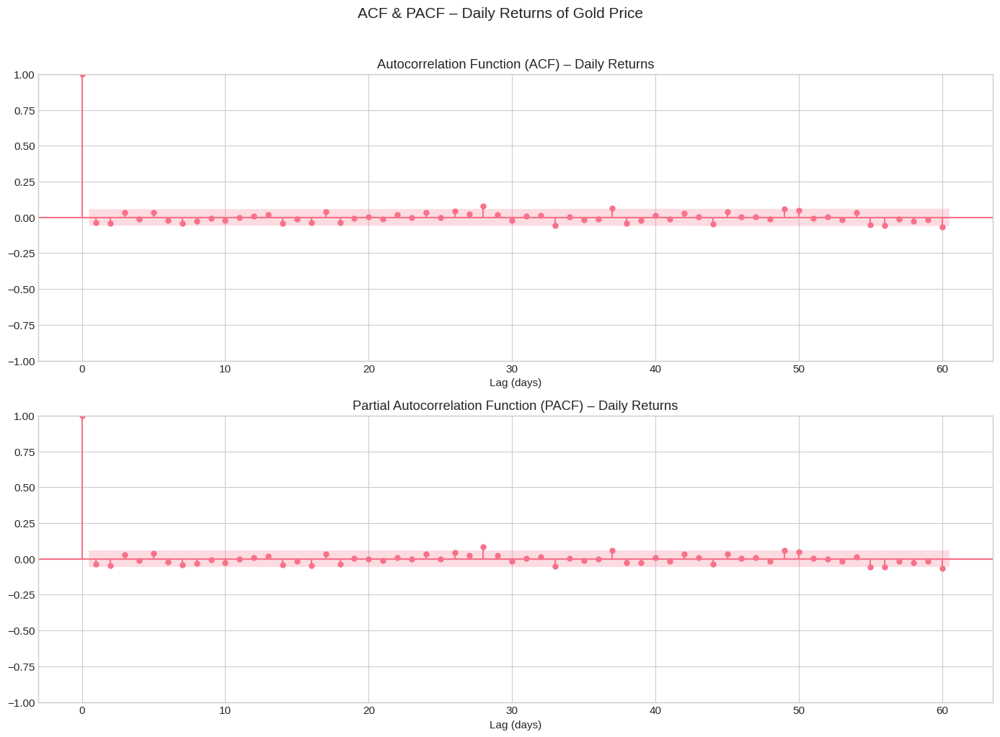

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

df = pd.read_csv(r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\gold_price_forecasting_dataset.csv", parse_dates=['date'], index_col='date')
df = df.sort_index()

# =============================================================================
# 1. Quantile-Quantile Plot (Q-Q plot) – checking normality of returns
# =============================================================================
print("1. Q-Q plot of daily returns vs theoretical normal distribution")

returns = df['daily_return'].dropna()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
stats.probplot(returns, dist="norm", plot=ax)

ax.set_title("Q-Q Plot – Daily Returns vs Normal Distribution", fontsize=14)
ax.set_xlabel("Theoretical Quantiles (Normal)", fontsize=12)
ax.set_ylabel("Sample Quantiles (daily returns)", fontsize=12)
ax.grid(True, alpha=0.3)

# Add reference line
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmin, xmax], [ymin, ymax], color='red', linestyle='--', lw=1.4, alpha=0.7)

plt.tight_layout()
plt.show()

# Interpretation tip:
print("→ If points follow the red line → returns are roughly normal")
print("→ Heavy deviation in tails → fat tails (typical in financial returns)")

# =============================================================================
# 2. Rolling Correlation between price and volume (or any two series)
# =============================================================================
print("\n2. Rolling correlation – Close price vs Volume")

window = 90  # ~3 months

rolling_corr = df['close'].rolling(window).corr(df['volume'])

plt.figure(figsize=(14, 6))
plt.plot(rolling_corr, color='darkcyan', linewidth=1.6, label=f'{window}-day rolling correlation')
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.title(f"Rolling Correlation – Gold Close Price vs Trading Volume ({window}-day)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Correlation coefficient")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. Detrended Price + Hodrick-Prescott filter (cycle vs trend separation)
# =============================================================================
print("\n3. Hodrick-Prescott filter – trend vs cyclical component")

from statsmodels.tsa.filters.hp_filter import hpfilter

cycle, trend = hpfilter(df['close'], lamb=1600*4**2)   # Ravn & Uhlig lambda for quarterly ≈ daily

fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(df.index, df['close'], label='Original Close', color='black', alpha=0.8, lw=1.1)
ax.plot(df.index, trend, label='HP Trend', color='darkorange', lw=2.2)
ax.plot(df.index, cycle + trend.mean(), label='Cycle (centered)', color='teal', lw=1.4)

ax.set_title("Hodrick-Prescott Decomposition – Gold Price", fontsize=15)
ax.set_ylabel("Price (USD)")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. ACF & PACF plots – autocorrelation structure
# =============================================================================
print("\n4. ACF and PACF – autocorrelation structure of daily returns")

returns_clean = df['daily_return'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(returns_clean, lags=60, ax=axes[0], title="Autocorrelation Function (ACF) – Daily Returns")
plot_pacf(returns_clean, lags=60, ax=axes[1], title="Partial Autocorrelation Function (PACF) – Daily Returns", method='ywm')

axes[0].set_xlabel("Lag (days)")
axes[1].set_xlabel("Lag (days)")

plt.suptitle("ACF & PACF – Daily Returns of Gold Price", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 🎯 Conclusion

In this project, we analyzed historical **gold price data** using Time Series Analysis techniques.

We explored the data, visualized price movements, studied important time-series patterns, checked stationarity, and used statistical techniques to understand the behavior of gold prices.

The forecasting stage helped us understand how historical observations can be used to estimate future values. We also evaluated the model's predictions against actual prices to understand its performance.

### 💡 Key Learning

**Historical Data → Analyze Patterns → Prepare Data → Build Model → Forecast Future Prices**

This project provides practical experience in applying **Time Series Analysis to financial data** and creates a foundation for exploring more advanced forecasting techniques such as **ARIMA, SARIMA, and LSTM**.

> ⚠️ **Note:** Gold-price forecasting is an analytical exercise. Actual gold prices are influenced by many external factors, so model predictions should not be treated as guaranteed future prices.

**🥇 From historical patterns to future possibilities.**

**Project by: Ajim Mujawar**
